STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 equal-width SFR bins for rMZR

Σ_SFR range:
  Min: -4.567
  Max: 0.019
  Range: 4.586

Bin width: 0.382

12 equal-width SFR bins:
  Bin 1: -4.57–-4.18
  Bin 2: -4.18–-3.80
  Bin 3: -3.80–-3.42
  Bin 4: -3.42–-3.04
  Bin 5: -3.04–-2.66
  Bin 6: -2.66–-2.27
  Bin 7: -2.27–-1.89
  Bin 8: -1.89–-1.51
  Bin 9: -1.51–-1.13
  Bin 10: -1.13–-0.75
  Bin 11: -0.75–-0.36
  Bin 12: -0.36–0.02

STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR

Σ_* Statistics:
  Min:

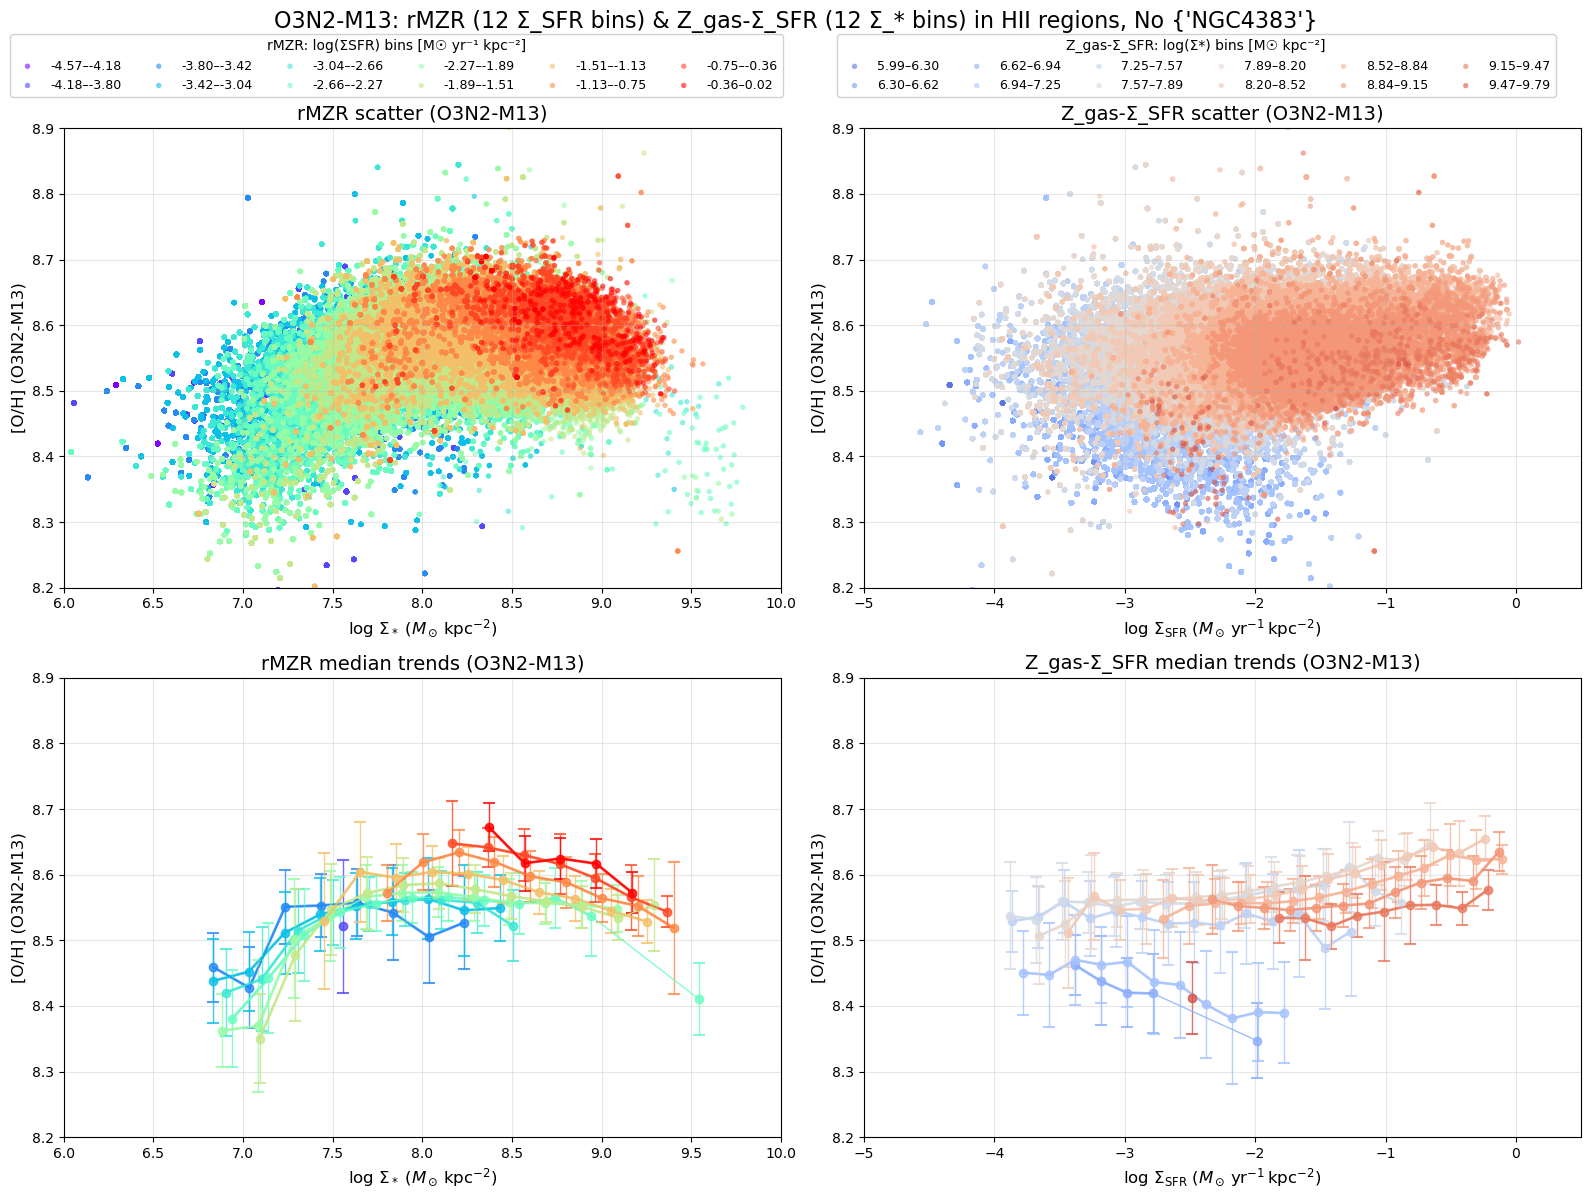


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_SFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width SFR bins for rMZR")
print("="*80)

# Get SFR range
sfr_min = np.min(all_logSigmaSFR_HII)
sfr_max = np.max(all_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range:")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = sfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_SFR bins) & Z_gas-Σ_SFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881
NGC4330 pixels (HII): 42998

STEP 2: Defining 12 equal-width SFR bins for rMZR (NGC4330 range)

Σ_SFR range (NGC4330):
  Min: -4.567
  Max: -1.155
  Range: 3.411

Bin width: 0.284

12 equal-width SFR bins (NGC4330):
  Bin 1: -4.57–-4.28
  Bin 2: -4.28–-4.00
  Bin 3: -4.00–-3.71
  Bin 4: -3.71–-3.43
  Bin 5: -3.43–-3.15
  Bin 6: -3.15–-2.86
  Bin 7: -2.86–-2.58
  Bin 8: -2.58–-2.29
  Bin 9: -2.29–-2.01
  Bin 10: -2.01–-1.72
  Bin 11: -1.72–-1.44
  Bin 12: -1.44–-1.16

STEP 3: Defining 12

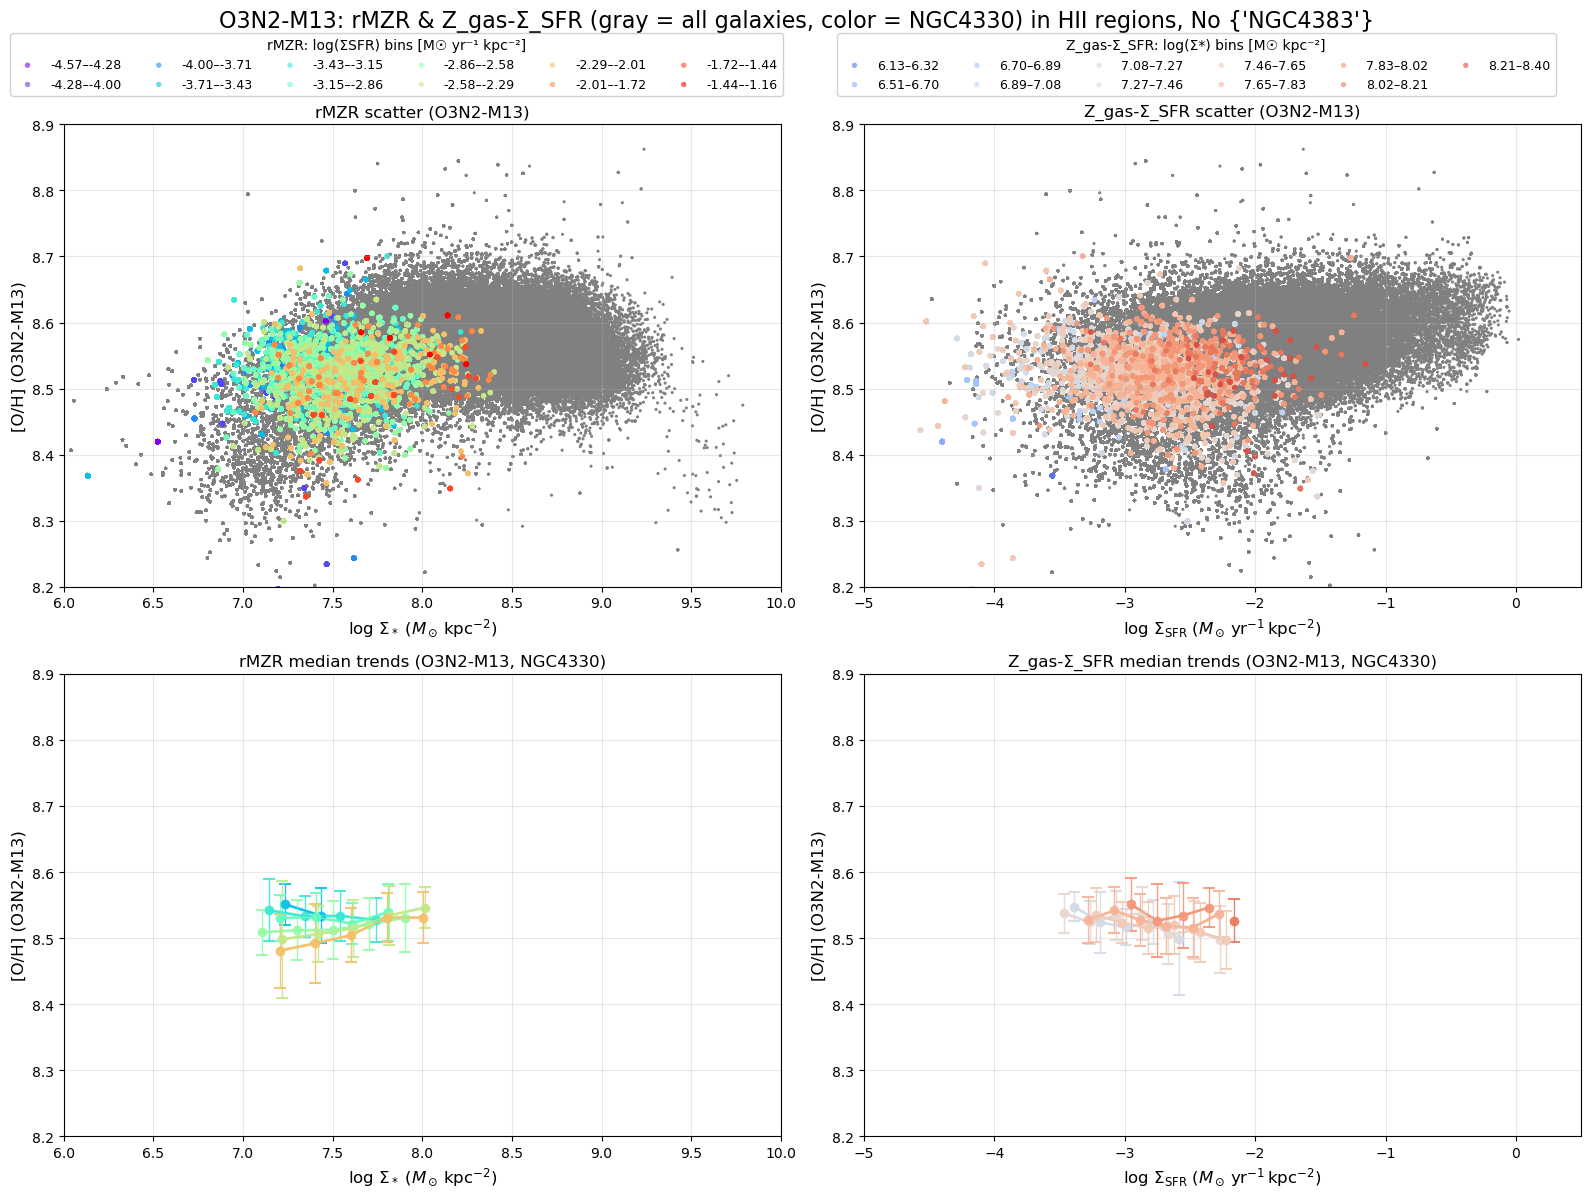


COMPLETED: NGC4330-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure with all-galaxy background and NGC4330 highlight from 13 galaxies
Galaxies included (background): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (gray = all, color = NGC4330 by Σ_SFR bin)
  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4330 by Σ_* bin)
  Bottom-left: rMZR median trends (NGC4330)
  Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)
  Shared y-range: 8.2 to 8.9


In [2]:
# ======================================================================================================
# Combined Analysis with NGC4330 highlight: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter (gray background = all galaxies, color = NGC4330)
#   Top-right: Z_gas-Σ_SFR scatter (gray background = all galaxies, color = NGC4330)
#   Bottom-left: rMZR median trends (NGC4330)
#   Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if np.isinf(x_min) or np.isinf(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    if np.isnan(x_min) or np.isnan(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if len(bin_edges) < 2:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies & isolate NGC4330
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

ngc4330_logSigmaM_HII = []
ngc4330_logSigmaSFR_HII = []
ngc4330_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data (combined background)
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

        # Store NGC4330 data separately
        if gal == 'NGC4330':
            ngc4330_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            ngc4330_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            ngc4330_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

ngc4330_logSigmaM_HII = np.array(ngc4330_logSigmaM_HII)
ngc4330_logSigmaSFR_HII = np.array(ngc4330_logSigmaSFR_HII)
ngc4330_oh_o3n2_m13_HII = np.array(ngc4330_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"NGC4330 pixels (HII): {len(ngc4330_logSigmaM_HII)}")

if len(ngc4330_logSigmaM_HII) == 0:
    raise ValueError("No valid NGC4330 pixels found. Cannot proceed with NGC4330-highlight plots.")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_SFR bins for rMZR analysis (based on NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width SFR bins for rMZR (NGC4330 range)")
print("="*80)

# Get SFR range (NGC4330)
sfr_min = np.min(ngc4330_logSigmaSFR_HII)
sfr_max = np.max(ngc4330_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range (NGC4330):")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 12 bins with equal width (NGC4330)
n_bins = 12
bin_width = sfr_range / n_bins if n_bins > 0 else np.nan

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges (NGC4330)
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width SFR bins (NGC4330):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis (based on NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR (NGC4330 range)")
print("="*80)

# Calculate the actual data range (NGC4330)
sigmaM_min = np.min(ngc4330_logSigmaM_HII)
sigmaM_max = np.max(ngc4330_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics (NGC4330):")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the NGC4330 data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM if n_bins_sigmaM > 0 else np.nan
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (NGC4330):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (background = all, highlight = NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot highlighting NGC4330")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Assign axes (swap top-right with bottom-left for layout)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (gray background = all, color-coded = NGC4330)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_SFR bins) ---")

# Background scatter for all galaxies
ax_rMZR_scatter.scatter(all_logSigmaM_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # NGC4330 binning in Σ_SFR
    if i == 0:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_ngc4330 = np.sum(in_bin_ngc4330)
    
    if n_pixels_ngc4330 >= 10:
        # NGC4330 data for this bin (x=Σ_*, y=[O/H])
        x_bin_ngc4330 = ngc4330_logSigmaM_HII[in_bin_ngc4330]
        y_bin_ngc4330 = ngc4330_oh_o3n2_m13_HII[in_bin_ngc4330]
        
        # Scatter plot (NGC4330 highlight)
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_ngc4330, y_bin_ngc4330, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends (NGC4330 only)
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4330, y_bin_ngc4330, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sfr[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sfr[i], linewidth=2, alpha=0.9)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_scatter.set_title('rMZR scatter (O3N2-M13)')
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends (NGC4330)
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_median.set_title('rMZR median trends (O3N2-M13, NGC4330)')
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins (NGC4330): {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (gray background = all, color-coded = NGC4330)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (12 Σ_* bins) ---")

# Background scatter for all galaxies
ax_Zgas_scatter.scatter(all_logSigmaSFR_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # NGC4330 binning in Σ_*
    if i == 0:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_ngc4330 = np.sum(in_bin_ngc4330)
    
    if n_pixels_ngc4330 >= 10:
        # NGC4330 data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_ngc4330 = ngc4330_logSigmaSFR_HII[in_bin_ngc4330]
        y_bin_ngc4330 = ngc4330_oh_o3n2_m13_HII[in_bin_ngc4330]
        
        # Scatter plot (NGC4330 highlight)
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_ngc4330, y_bin_ngc4330, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (NGC4330 only)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4330, y_bin_ngc4330, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sigmaM[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sigmaM[i], linewidth=2, alpha=0.9)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_scatter.set_title('Z_gas-Σ_SFR scatter (O3N2-M13)')
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends (NGC4330)
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_median.set_title('Z_gas-Σ_SFR median trends (O3N2-M13, NGC4330)')
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins (NGC4330): {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'O3N2-M13: rMZR & Z_gas-Σ_SFR (gray = all galaxies, color = NGC4330) in HII regions, No {excluded_galaxies}', fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('NGC4330_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.png', dpi=300, bbox_inches='tight')
# plt.savefig('NGC4330_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: NGC4330-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure with all-galaxy background and NGC4330 highlight from {len(included_galaxies)} galaxies")
print(f"Galaxies included (background): {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (gray = all, color = NGC4330 by Σ_SFR bin)")
print("  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4330 by Σ_* bin)")
print("  Bottom-left: rMZR median trends (NGC4330)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")



[O3N2-M13] statistics for NGC4330:
  Σ_SFR range: -4.567 to -1.155
  [O/H] range: 8.197 to 8.700
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Common valid pixels: 42998


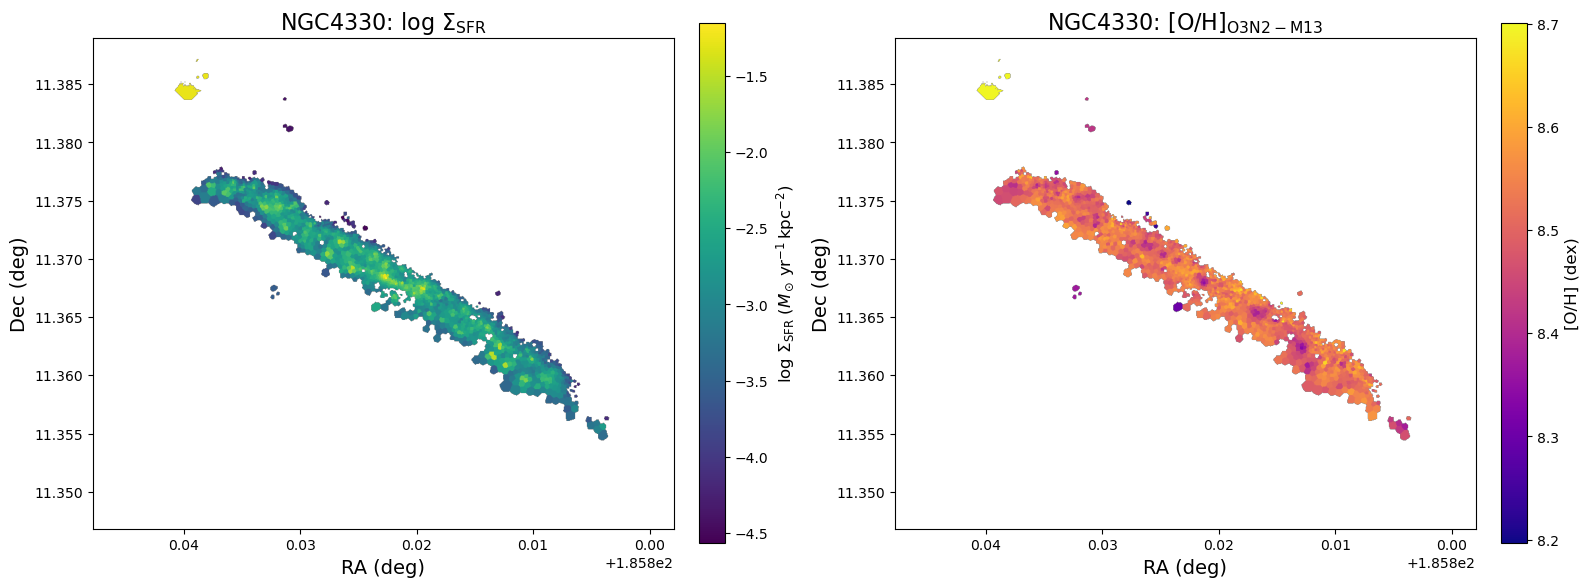

In [3]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Define bin edges (match those used earlier in this notebook)
    # ------------------------------------------------------------------
    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_min, sfr_max = np.nanmin(sigSFR[valid_sfr]), np.nanmax(sigSFR[valid_sfr])
    sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(oh_o3n2_map[valid_oh]), np.nanmax(oh_o3n2_map[valid_oh])
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR continuous, right = [O/H] continuous
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR continuous colormap
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sigSFR), origin='lower', cmap='viridis',
                            extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)

    # Right-hand side: [O/H] continuous colormap
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_o3n2_map), origin='lower', cmap='plasma',
                           extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)

    # For reporting: basic statistics for the maps
    print(f"\n[{indicator_name}] statistics for {gal}:")
    print(f"  Σ_SFR range: {np.nanmin(sigSFR[valid_sfr]):.3f} to {np.nanmax(sigSFR[valid_sfr]):.3f}")
    print(f"  [O/H] range: {np.nanmin(oh_o3n2_map[valid_oh]):.3f} to {np.nanmax(oh_o3n2_map[valid_oh]):.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_continuous.png', dpi=600)
    plt.show()



[O3N2-M13] statistics for NGC4330 (HII regions only):
  Σ_SFR range: -4.567 to -1.155
  [O/H] range: 8.197 to 8.700
  log(Age) range: -0.584 to 1.117
  [M/H] range: -1.490 to 0.260
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Valid pixels for Age (HII masked): 42998
  Valid pixels for [M/H] (HII masked): 42998
  Common valid pixels (all maps): 42998


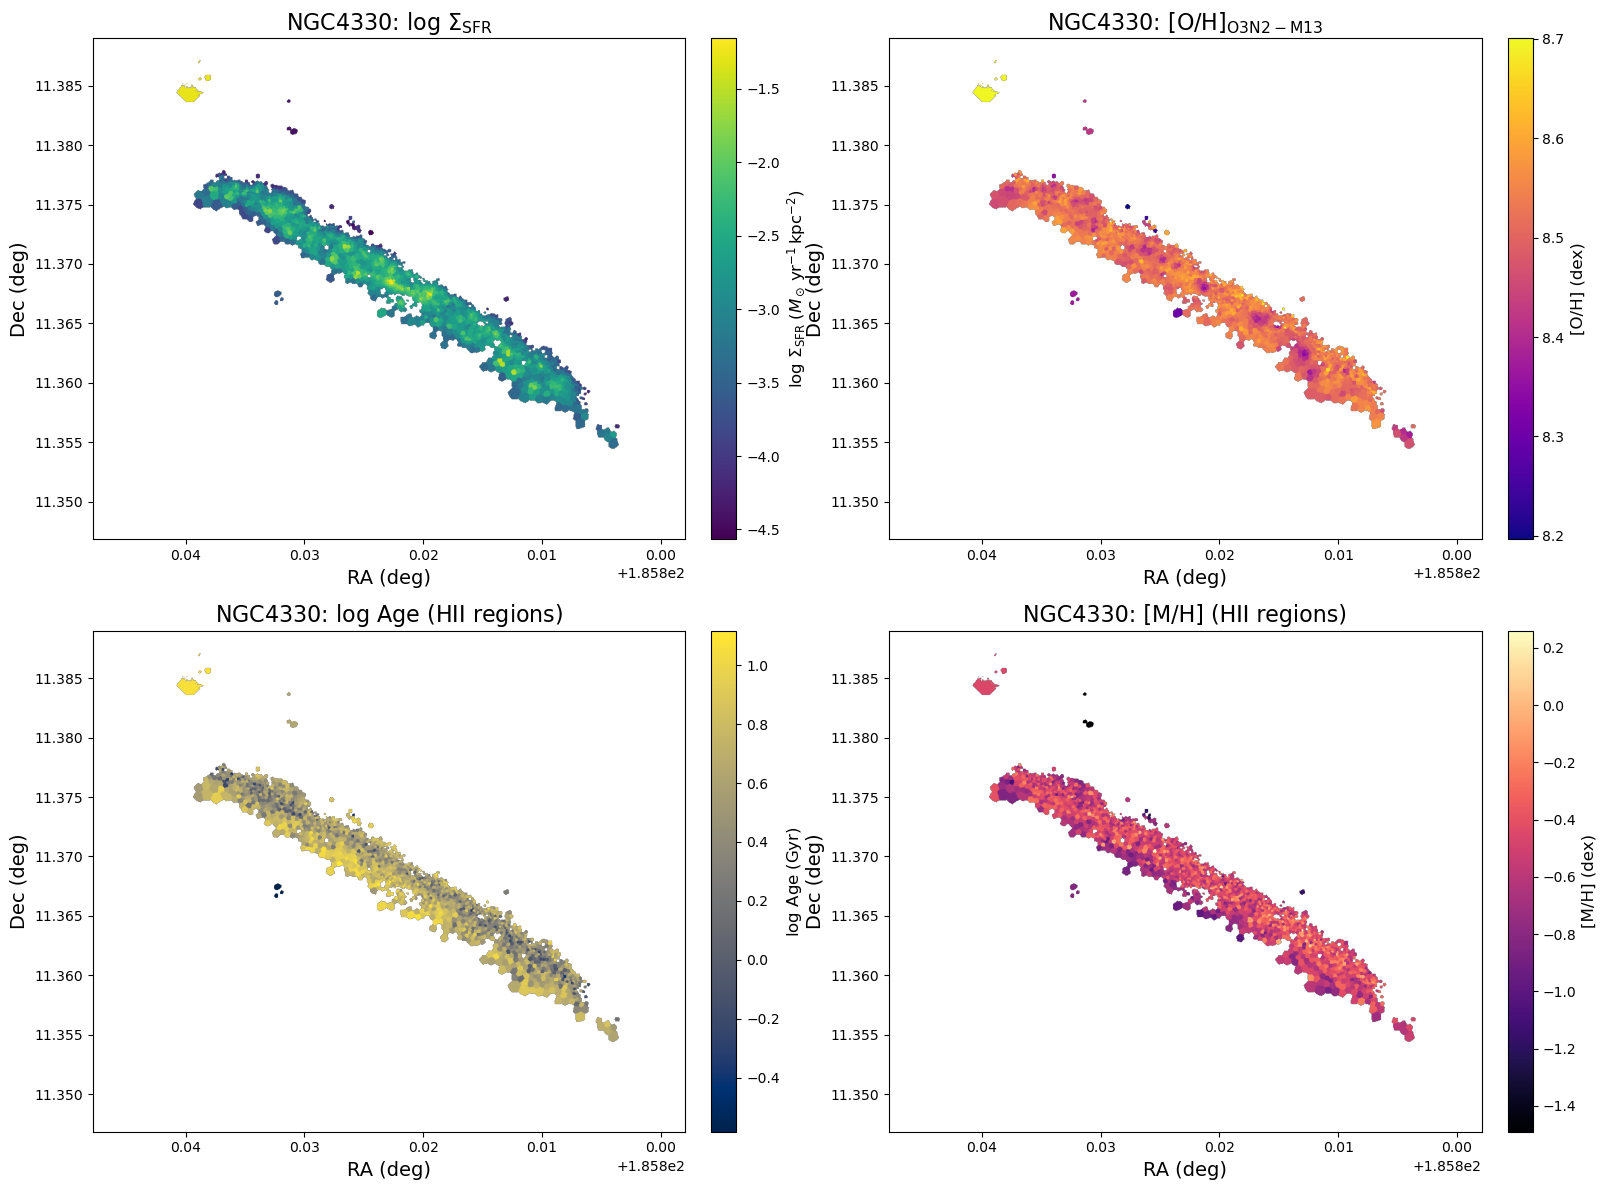

In [4]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise 4 maps: Σ_SFR, [O/H], Age, Stellar Metallicity
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    sfh_path = f'{gal}_SFH_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(sfh_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(sfh_path) as h_sfh:
        age_map = h_sfh['AGE'].data
        metal_map = h_sfh['METAL'].data
    return sigM, sigSFR, oh_map, age_map, metal_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, age_map, metal_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps - based on HII region selection (oh_o3n2_map)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sfr = np.isfinite(sigSFR) & valid_oh
    valid_age = np.isfinite(age_map) & valid_oh
    valid_metal = np.isfinite(metal_map) & valid_oh
    valid_all = valid_sfr & valid_oh & valid_age & valid_metal

    # Apply HII region mask to ensure all maps show the same spaxels
    age_map_masked = np.where(valid_oh, age_map, np.nan)
    metal_map_masked = np.where(valid_oh, metal_map, np.nan)

    # Calculate log age for visualization (after masking)
    log_age_map = np.log10(age_map_masked)

    # ------------------------------------------------------------------
    # 2.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 3.  Create figure: 2x2 layout
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Top-left: Σ_SFR continuous colormap
    im_sfr = axes[0,0].imshow(np.ma.masked_invalid(sigSFR), origin='lower', cmap='viridis',
                            extent=extent)
    axes[0,0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=16)
    axes[0,0].set_xlabel('RA (deg)', fontsize=14)
    axes[0,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0,0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)

    # Top-right: [O/H] continuous colormap
    im_oh = axes[0,1].imshow(np.ma.masked_invalid(oh_o3n2_map), origin='lower', cmap='plasma',
                           extent=extent)
    axes[0,1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=16)
    axes[0,1].set_xlabel('RA (deg)', fontsize=14)
    axes[0,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[0,1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)

    # Bottom-left: Log Age map (HII region masked)
    im_age = axes[1,0].imshow(np.ma.masked_invalid(log_age_map), origin='lower', cmap='cividis',
                            extent=extent)
    axes[1,0].set_title(rf'{gal}: $\log\,\mathrm{{Age}}$ (HII regions)', fontsize=16)
    axes[1,0].set_xlabel('RA (deg)', fontsize=14)
    axes[1,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_age = fig.colorbar(im_age, ax=axes[1,0], fraction=0.046, pad=0.04)
    cbar_age.set_label(r'$\log\,\mathrm{Age} \; (\mathrm{Gyr})$', fontsize=12)

    # Bottom-right: Stellar metallicity map (HII region masked)
    im_metal = axes[1,1].imshow(np.ma.masked_invalid(metal_map_masked), origin='lower', cmap='magma',
                              extent=extent)
    axes[1,1].set_title(rf'{gal}: [M/H] (HII regions)', fontsize=16)
    axes[1,1].set_xlabel('RA (deg)', fontsize=14)
    axes[1,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_metal = fig.colorbar(im_metal, ax=axes[1,1], fraction=0.046, pad=0.04)
    cbar_metal.set_label(r'[M/H] (dex)', fontsize=12)

    # For reporting: basic statistics for all maps (using masked data)
    print(f"\n[{indicator_name}] statistics for {gal} (HII regions only):")
    print(f"  Σ_SFR range: {np.nanmin(sigSFR[valid_sfr]):.3f} to {np.nanmax(sigSFR[valid_sfr]):.3f}")
    print(f"  [O/H] range: {np.nanmin(oh_o3n2_map[valid_oh]):.3f} to {np.nanmax(oh_o3n2_map[valid_oh]):.3f}")
    print(f"  log(Age) range: {np.nanmin(log_age_map[np.isfinite(log_age_map)]):.3f} to {np.nanmax(log_age_map[np.isfinite(log_age_map)]):.3f}")
    print(f"  [M/H] range: {np.nanmin(metal_map_masked[np.isfinite(metal_map_masked)]):.3f} to {np.nanmax(metal_map_masked[np.isfinite(metal_map_masked)]):.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Valid pixels for Age (HII masked): {np.sum(np.isfinite(log_age_map))}")
    print(f"  Valid pixels for [M/H] (HII masked): {np.sum(np.isfinite(metal_map_masked))}")
    print(f"  Common valid pixels (all maps): {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_4panel_maps_HII_masked.png', dpi=600)
    plt.show()


[O3N2-M13] statistics for NGC4330 (HII regions only):
  Σ_SFR range: -4.567 to -1.155
  [O/H] range: 8.197 to 8.700
  Σ_* range: 6.135 to 8.400
  [M/H] range: -1.490 to 0.260
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Valid pixels for Σ_* (HII masked): 42998
  Valid pixels for [M/H] (HII masked): 42998
  Common valid pixels (all maps): 42998


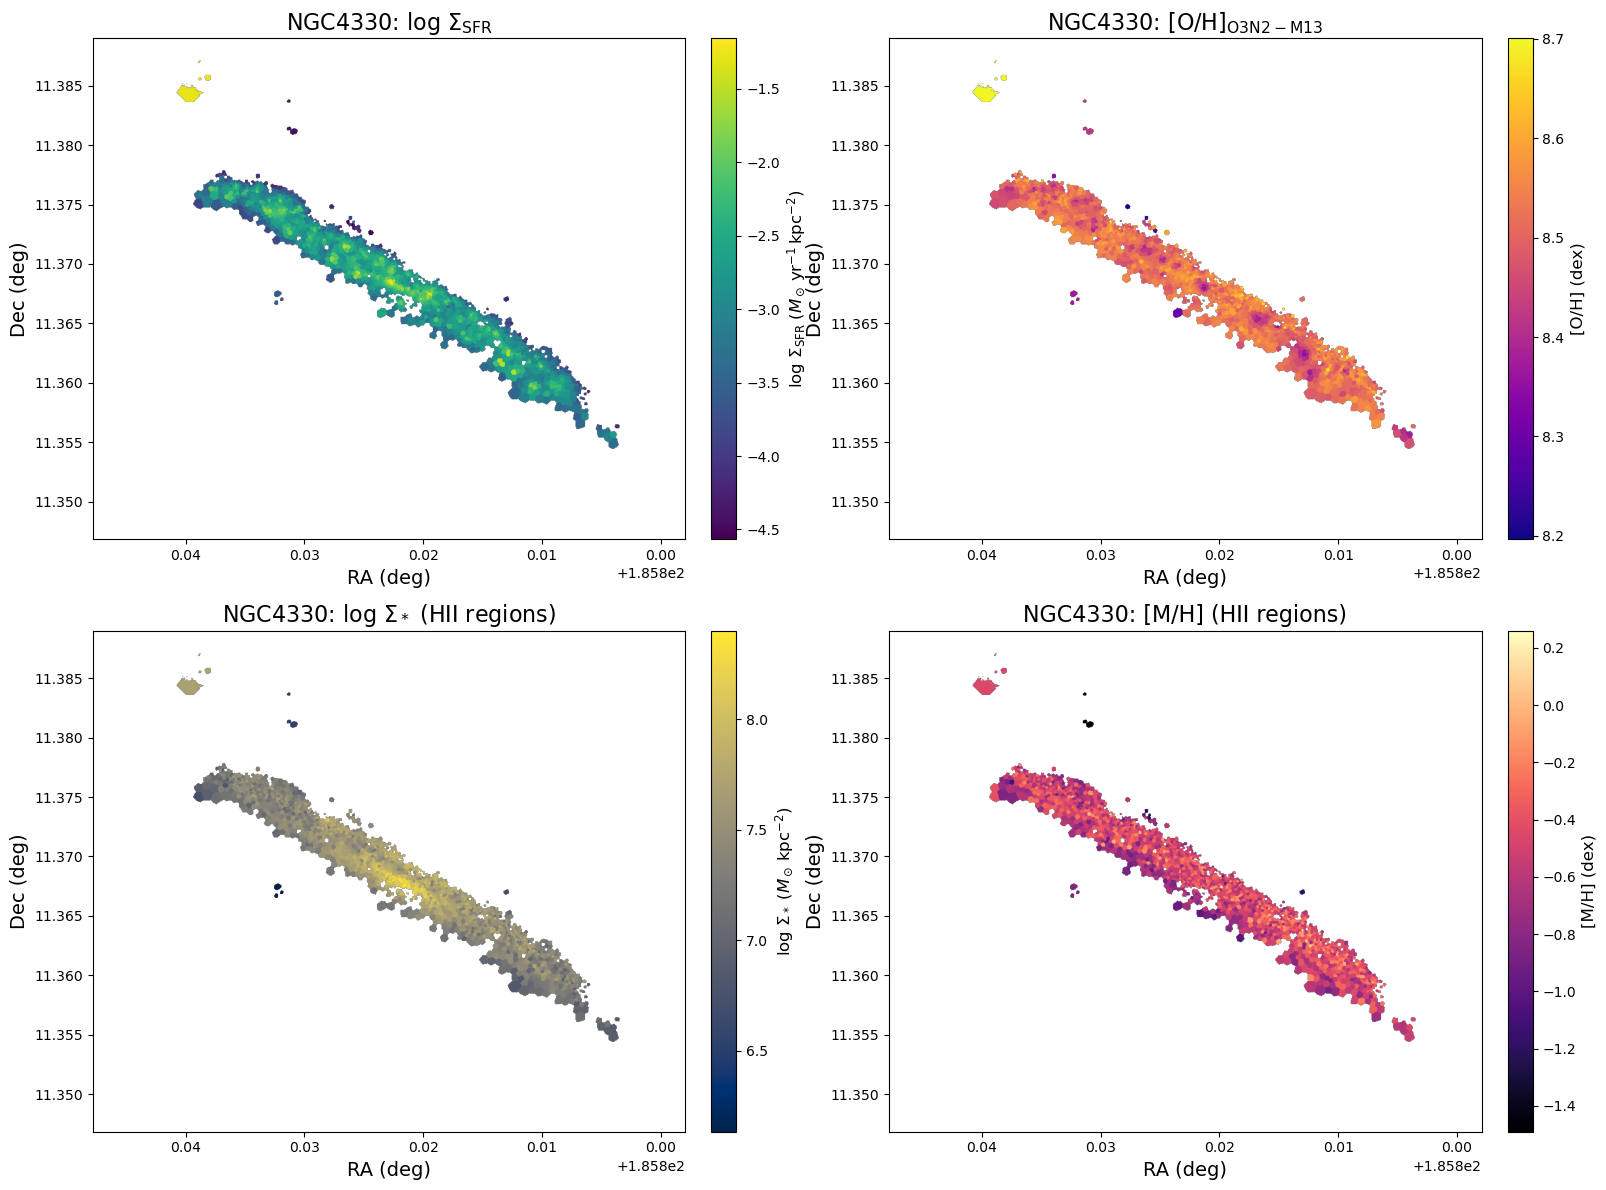

In [5]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise 4 maps: Σ_SFR, [O/H], Σ_*, Stellar Metallicity
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    sfh_path = f'{gal}_SFH_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(sfh_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(sfh_path) as h_sfh:
        age_map = h_sfh['AGE'].data
        metal_map = h_sfh['METAL'].data
    return sigM, sigSFR, oh_map, age_map, metal_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, age_map, metal_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps - based on HII region selection (oh_o3n2_map)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sfr = np.isfinite(sigSFR) & valid_oh
    valid_sigM = np.isfinite(sigM) & valid_oh
    valid_metal = np.isfinite(metal_map) & valid_oh
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_metal

    # Apply HII region mask to ensure all maps show the same spaxels
    sigM_masked = np.where(valid_oh, sigM, np.nan)
    metal_map_masked = np.where(valid_oh, metal_map, np.nan)

    # ------------------------------------------------------------------
    # 2.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 3.  Create figure: 2x2 layout
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Top-left: Σ_SFR continuous colormap
    im_sfr = axes[0,0].imshow(np.ma.masked_invalid(sigSFR), origin='lower', cmap='viridis',
                            extent=extent)
    axes[0,0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=16)
    axes[0,0].set_xlabel('RA (deg)', fontsize=14)
    axes[0,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0,0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)

    # Top-right: [O/H] continuous colormap
    im_oh = axes[0,1].imshow(np.ma.masked_invalid(oh_o3n2_map), origin='lower', cmap='plasma',
                           extent=extent)
    axes[0,1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=16)
    axes[0,1].set_xlabel('RA (deg)', fontsize=14)
    axes[0,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[0,1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)

    # Bottom-left: Stellar mass surface density map (HII region masked)
    im_sigM = axes[1,0].imshow(np.ma.masked_invalid(sigM_masked), origin='lower', cmap='cividis',
                            extent=extent)
    axes[1,0].set_title(rf'{gal}: $\log\,\Sigma_*$ (HII regions)', fontsize=16)
    axes[1,0].set_xlabel('RA (deg)', fontsize=14)
    axes[1,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sigM = fig.colorbar(im_sigM, ax=axes[1,0], fraction=0.046, pad=0.04)
    cbar_sigM.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)

    # Bottom-right: Stellar metallicity map (HII region masked)
    im_metal = axes[1,1].imshow(np.ma.masked_invalid(metal_map_masked), origin='lower', cmap='magma',
                              extent=extent)
    axes[1,1].set_title(rf'{gal}: [M/H] (HII regions)', fontsize=16)
    axes[1,1].set_xlabel('RA (deg)', fontsize=14)
    axes[1,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_metal = fig.colorbar(im_metal, ax=axes[1,1], fraction=0.046, pad=0.04)
    cbar_metal.set_label(r'[M/H] (dex)', fontsize=12)

    # For reporting: basic statistics for all maps (using masked data)
    print(f"\n[{indicator_name}] statistics for {gal} (HII regions only):")
    print(f"  Σ_SFR range: {np.nanmin(sigSFR[valid_sfr]):.3f} to {np.nanmax(sigSFR[valid_sfr]):.3f}")
    print(f"  [O/H] range: {np.nanmin(oh_o3n2_map[valid_oh]):.3f} to {np.nanmax(oh_o3n2_map[valid_oh]):.3f}")
    print(f"  Σ_* range: {np.nanmin(sigM_masked[np.isfinite(sigM_masked)]):.3f} to {np.nanmax(sigM_masked[np.isfinite(sigM_masked)]):.3f}")
    print(f"  [M/H] range: {np.nanmin(metal_map_masked[np.isfinite(metal_map_masked)]):.3f} to {np.nanmax(metal_map_masked[np.isfinite(metal_map_masked)]):.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Valid pixels for Σ_* (HII masked): {np.sum(np.isfinite(sigM_masked))}")
    print(f"  Valid pixels for [M/H] (HII masked): {np.sum(np.isfinite(metal_map_masked))}")
    print(f"  Common valid pixels (all maps): {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_4panel_maps_SigmaM_HII_masked.png', dpi=600)
    plt.show()

## 20251013 Use the offset map to enhance the visualization of the map
Here I can try taking the median value as the standard and then perform the offset map to see how the metallicity varies across the galaxy.   
And similarly for the $\Sigma_\mathrm{SFR}$.


[O3N2-M13] offset statistics for NGC4330:
  Σ_SFR median: -2.799
  Σ_SFR offset range: -1.768 to 1.644
  Σ_SFR offset max absolute: ±1.768
  [O/H] median: 8.520
  [O/H] offset range: -0.323 to 0.181
  [O/H] offset max absolute: ±0.323
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Common valid pixels: 42998


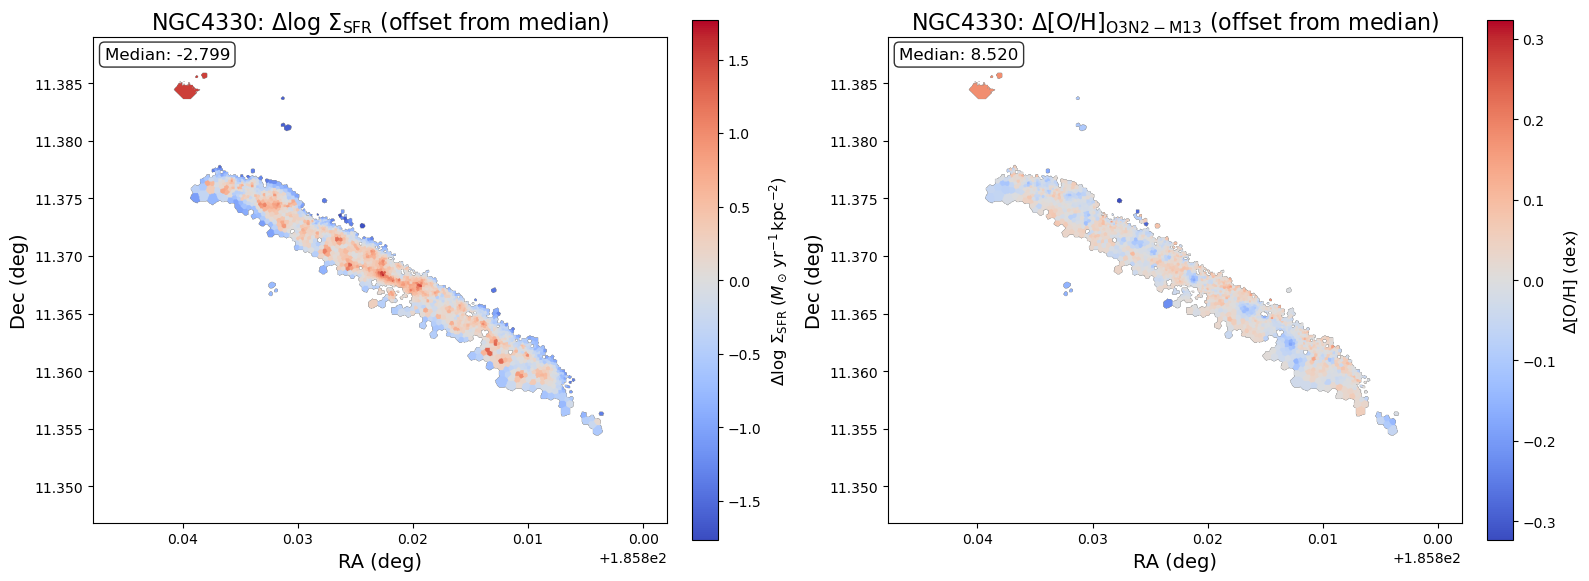

In [6]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate median values and create offset maps
    # ------------------------------------------------------------------
    # Calculate median values for offset calculation
    sfr_median = np.nanmedian(sigSFR[valid_sfr])
    oh_median = np.nanmedian(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from median)
    sfr_offset = sigSFR - sfr_median
    oh_offset = oh_o3n2_map - oh_median
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from median)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add median value annotation on top left
    axes[0].text(0.02, 0.98, f'Median: {sfr_median:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from median)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add median value annotation on top left
    axes[1].text(0.02, 0.98, f'Median: {oh_median:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal}:")
    print(f"  Σ_SFR median: {sfr_median:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] median: {oh_median:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps.png', dpi=600)
    plt.show()


[O3N2-M13] offset statistics for NGC4330 (HII regions only):
  Σ_SFR median: -2.799
  Σ_SFR offset range: -1.768 to 1.644
  Σ_SFR offset max absolute: ±1.768
  [O/H] median: 8.520
  [O/H] offset range: -0.323 to 0.181
  [O/H] offset max absolute: ±0.323
  log(Age) median: 0.651
  log(Age) offset range: -1.235 to 0.466
  log(Age) offset max absolute: ±1.235
  [M/H] median: -0.505
  [M/H] offset range: -0.985 to 0.764
  [M/H] offset max absolute: ±0.985
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Valid pixels for log(Age) (HII masked): 42998
  Valid pixels for [M/H] (HII masked): 42998
  Common valid pixels (all maps): 42998


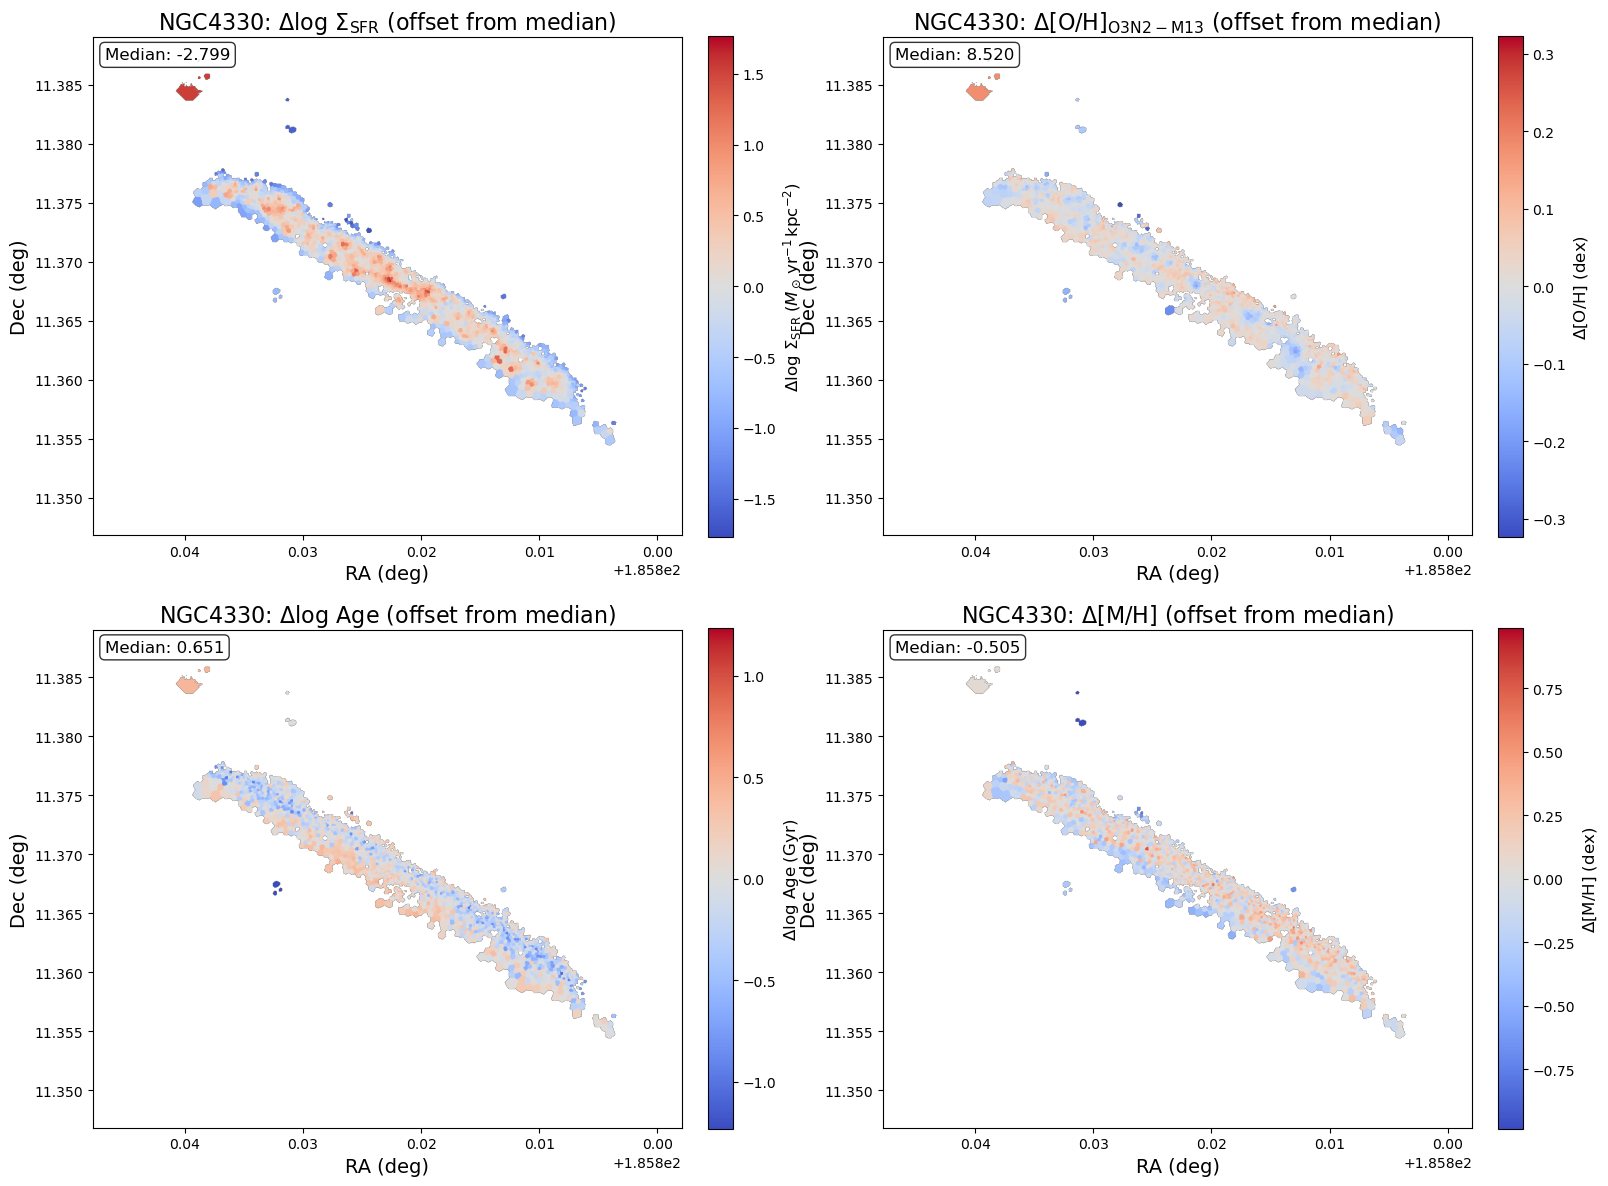

In [7]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise 4 offset maps: Σ_SFR, [O/H], Age, [M/H]
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    sfh_path = f'{gal}_SFH_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(sfh_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(sfh_path) as h_sfh:
        age_map = h_sfh['AGE'].data
        metal_map = h_sfh['METAL'].data
    return sigM, sigSFR, oh_map, age_map, metal_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, age_map, metal_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps - based on HII region selection (oh_o3n2_map)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sfr = np.isfinite(sigSFR) & valid_oh
    valid_age = np.isfinite(age_map) & valid_oh
    valid_metal = np.isfinite(metal_map) & valid_oh
    valid_all = valid_sfr & valid_oh & valid_age & valid_metal

    # Apply HII region mask to ensure all maps show the same spaxels
    age_map_masked = np.where(valid_oh, age_map, np.nan)
    metal_map_masked = np.where(valid_oh, metal_map, np.nan)

    # Calculate log age for visualization (after masking)
    log_age_map = np.log10(age_map_masked)

    # ------------------------------------------------------------------
    # 2.  Calculate median values and create offset maps
    # ------------------------------------------------------------------
    # Calculate median values for offset calculation
    sfr_median = np.nanmedian(sigSFR[valid_sfr])
    oh_median = np.nanmedian(oh_o3n2_map[valid_oh])
    log_age_median = np.nanmedian(log_age_map[np.isfinite(log_age_map)])
    metal_median = np.nanmedian(metal_map_masked[np.isfinite(metal_map_masked)])
    
    # Create offset maps (difference from median)
    sfr_offset = sigSFR - sfr_median
    oh_offset = oh_o3n2_map - oh_median
    log_age_offset = log_age_map - log_age_median
    metal_offset = metal_map_masked - metal_median
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))
    log_age_offset_max = np.nanmax(np.abs(log_age_offset[np.isfinite(log_age_offset)]))
    metal_offset_max = np.nanmax(np.abs(metal_offset[np.isfinite(metal_offset)]))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: 2x2 layout for offset maps
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Top-left: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0,0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0,0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from median)', fontsize=16)
    axes[0,0].set_xlabel('RA (deg)', fontsize=14)
    axes[0,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0,0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add median value annotation on top left
    axes[0,0].text(0.02, 0.98, f'Median: {sfr_median:.3f}', transform=axes[0,0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[0,1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[0,1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from median)', fontsize=16)
    axes[0,1].set_xlabel('RA (deg)', fontsize=14)
    axes[0,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[0,1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add median value annotation on top left
    axes[0,1].text(0.02, 0.98, f'Median: {oh_median:.3f}', transform=axes[0,1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: log(Age) offset map (coolwarm, centered at 0)
    im_age = axes[1,0].imshow(np.ma.masked_invalid(log_age_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-log_age_offset_max, vmax=log_age_offset_max)
    axes[1,0].set_title(rf'{gal}: $\Delta\log\,\mathrm{{Age}}$ (offset from median)', fontsize=16)
    axes[1,0].set_xlabel('RA (deg)', fontsize=14)
    axes[1,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_age = fig.colorbar(im_age, ax=axes[1,0], fraction=0.046, pad=0.04)
    cbar_age.set_label(r'$\Delta\log\,\mathrm{Age} \; (\mathrm{Gyr})$', fontsize=12)
    
    # Add median value annotation on top left
    axes[1,0].text(0.02, 0.98, f'Median: {log_age_median:.3f}', transform=axes[1,0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: [M/H] offset map (coolwarm, centered at 0)
    im_metal = axes[1,1].imshow(np.ma.masked_invalid(metal_offset), origin='lower', cmap='coolwarm',
                              extent=extent, vmin=-metal_offset_max, vmax=metal_offset_max)
    axes[1,1].set_title(rf'{gal}: $\Delta$[M/H] (offset from median)', fontsize=16)
    axes[1,1].set_xlabel('RA (deg)', fontsize=14)
    axes[1,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_metal = fig.colorbar(im_metal, ax=axes[1,1], fraction=0.046, pad=0.04)
    cbar_metal.set_label(r'$\Delta$[M/H] (dex)', fontsize=12)
    
    # Add median value annotation on top left
    axes[1,1].text(0.02, 0.98, f'Median: {metal_median:.3f}', transform=axes[1,1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for all maps
    print(f"\n[{indicator_name}] offset statistics for {gal} (HII regions only):")
    print(f"  Σ_SFR median: {sfr_median:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] median: {oh_median:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  log(Age) median: {log_age_median:.3f}")
    print(f"  log(Age) offset range: {np.nanmin(log_age_offset[np.isfinite(log_age_offset)]):.3f} to {np.nanmax(log_age_offset[np.isfinite(log_age_offset)]):.3f}")
    print(f"  log(Age) offset max absolute: ±{log_age_offset_max:.3f}")
    print(f"  [M/H] median: {metal_median:.3f}")
    print(f"  [M/H] offset range: {np.nanmin(metal_offset[np.isfinite(metal_offset)]):.3f} to {np.nanmax(metal_offset[np.isfinite(metal_offset)]):.3f}")
    print(f"  [M/H] offset max absolute: ±{metal_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Valid pixels for log(Age) (HII masked): {np.sum(np.isfinite(log_age_offset))}")
    print(f"  Valid pixels for [M/H] (HII masked): {np.sum(np.isfinite(metal_offset))}")
    print(f"  Common valid pixels (all maps): {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_4panel_offset_maps_Age_HII_masked.png', dpi=600)
    plt.show()


[O3N2-M13] offset statistics for NGC4330 (HII regions only):
  Σ_SFR median: -2.799
  Σ_SFR offset range: -1.768 to 1.644
  Σ_SFR offset max absolute: ±1.768
  [O/H] median: 8.520
  [O/H] offset range: -0.323 to 0.181
  [O/H] offset max absolute: ±0.323
  Σ_* median: 7.442
  Σ_* offset range: -1.307 to 0.958
  Σ_* offset max absolute: ±1.307
  [M/H] median: -0.505
  [M/H] offset range: -0.985 to 0.764
  [M/H] offset max absolute: ±0.985
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Valid pixels for Σ_* (HII masked): 42998
  Valid pixels for [M/H] (HII masked): 42998
  Common valid pixels (all maps): 42998


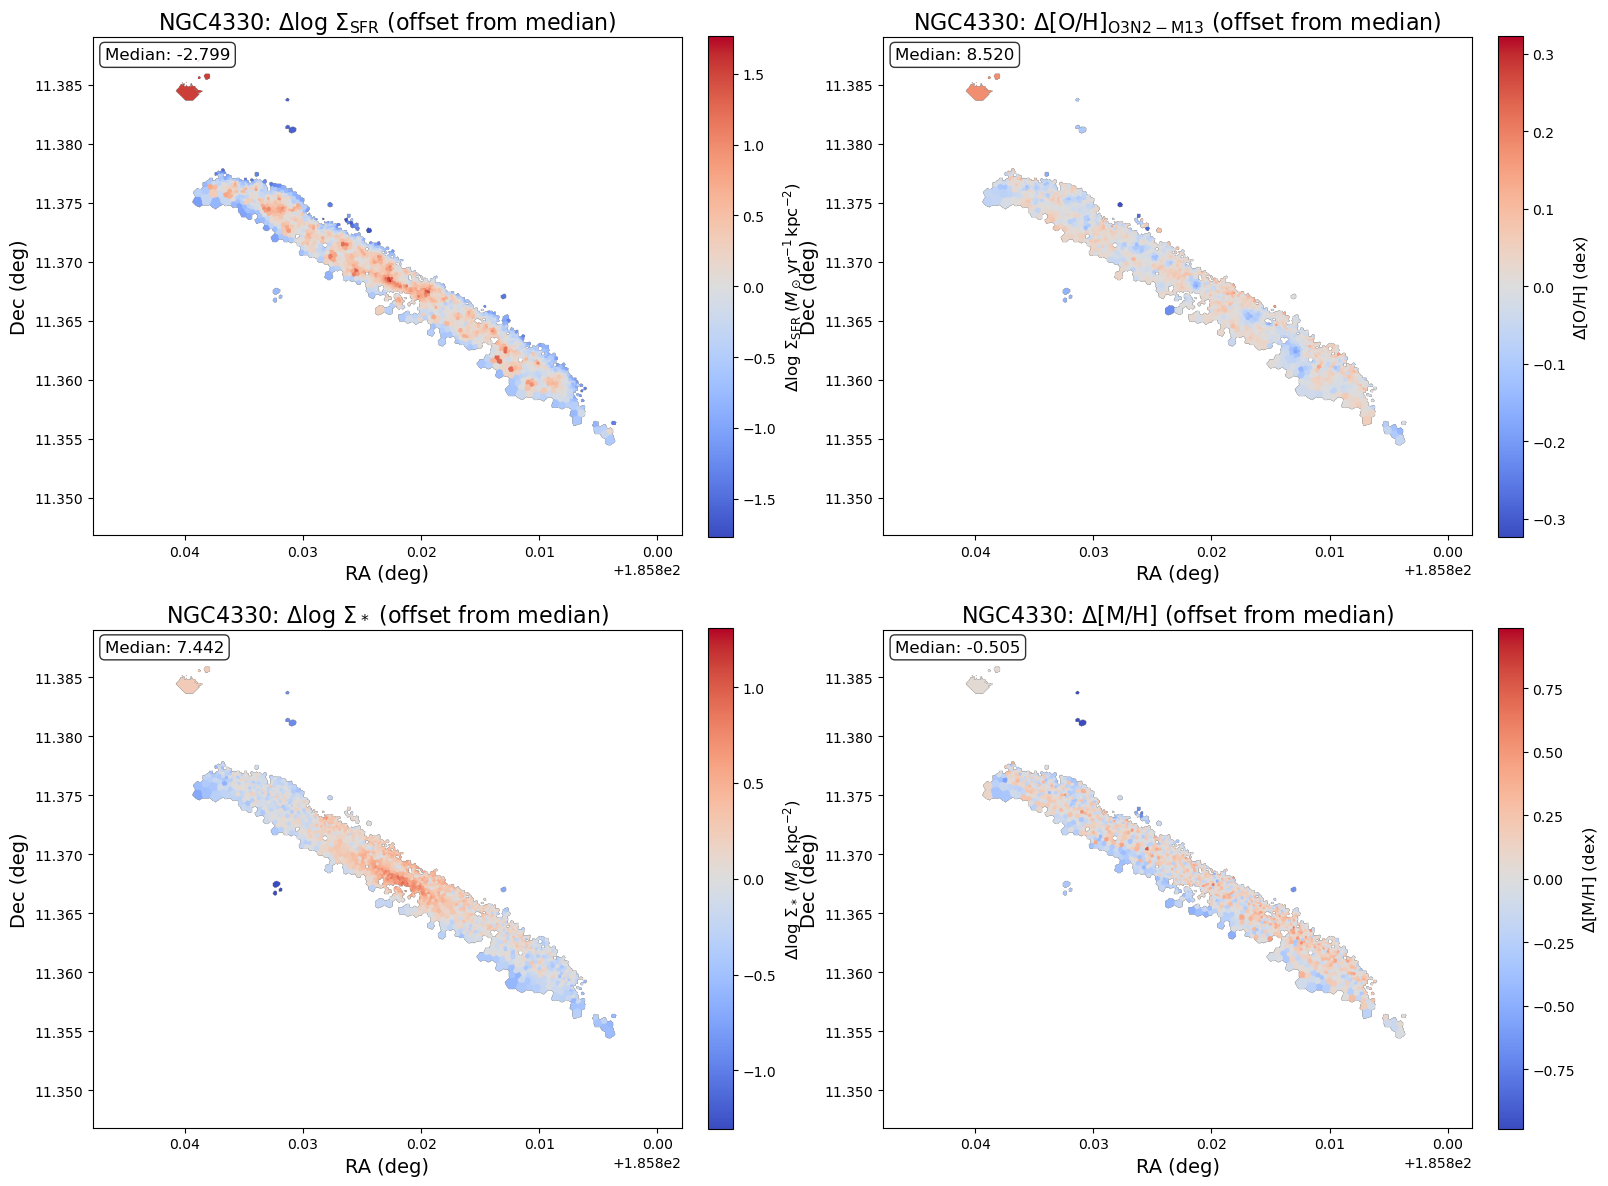

In [8]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise 4 offset maps: Σ_SFR, [O/H], Σ_*, [M/H]
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    sfh_path = f'{gal}_SFH_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(sfh_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(sfh_path) as h_sfh:
        age_map = h_sfh['AGE'].data
        metal_map = h_sfh['METAL'].data
    return sigM, sigSFR, oh_map, age_map, metal_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, age_map, metal_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps - based on HII region selection (oh_o3n2_map)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sfr = np.isfinite(sigSFR) & valid_oh
    valid_sigM = np.isfinite(sigM) & valid_oh
    valid_metal = np.isfinite(metal_map) & valid_oh
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_metal

    # Apply HII region mask to ensure all maps show the same spaxels
    sigM_masked = np.where(valid_oh, sigM, np.nan)
    metal_map_masked = np.where(valid_oh, metal_map, np.nan)

    # ------------------------------------------------------------------
    # 2.  Calculate median values and create offset maps
    # ------------------------------------------------------------------
    # Calculate median values for offset calculation
    sfr_median = np.nanmedian(sigSFR[valid_sfr])
    oh_median = np.nanmedian(oh_o3n2_map[valid_oh])
    sigM_median = np.nanmedian(sigM_masked[np.isfinite(sigM_masked)])
    metal_median = np.nanmedian(metal_map_masked[np.isfinite(metal_map_masked)])
    
    # Create offset maps (difference from median)
    sfr_offset = sigSFR - sfr_median
    oh_offset = oh_o3n2_map - oh_median
    sigM_offset = sigM_masked - sigM_median
    metal_offset = metal_map_masked - metal_median
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))
    sigM_offset_max = np.nanmax(np.abs(sigM_offset[np.isfinite(sigM_offset)]))
    metal_offset_max = np.nanmax(np.abs(metal_offset[np.isfinite(metal_offset)]))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: 2x2 layout for offset maps
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Top-left: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0,0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0,0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from median)', fontsize=16)
    axes[0,0].set_xlabel('RA (deg)', fontsize=14)
    axes[0,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0,0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add median value annotation on top left
    axes[0,0].text(0.02, 0.98, f'Median: {sfr_median:.3f}', transform=axes[0,0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[0,1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[0,1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from median)', fontsize=16)
    axes[0,1].set_xlabel('RA (deg)', fontsize=14)
    axes[0,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[0,1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add median value annotation on top left
    axes[0,1].text(0.02, 0.98, f'Median: {oh_median:.3f}', transform=axes[0,1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Σ_* offset map (coolwarm, centered at 0)
    im_sigM = axes[1,0].imshow(np.ma.masked_invalid(sigM_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sigM_offset_max, vmax=sigM_offset_max)
    axes[1,0].set_title(rf'{gal}: $\Delta\log\,\Sigma_*$ (offset from median)', fontsize=16)
    axes[1,0].set_xlabel('RA (deg)', fontsize=14)
    axes[1,0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sigM = fig.colorbar(im_sigM, ax=axes[1,0], fraction=0.046, pad=0.04)
    cbar_sigM.set_label(r'$\Delta\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add median value annotation on top left
    axes[1,0].text(0.02, 0.98, f'Median: {sigM_median:.3f}', transform=axes[1,0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: [M/H] offset map (coolwarm, centered at 0)
    im_metal = axes[1,1].imshow(np.ma.masked_invalid(metal_offset), origin='lower', cmap='coolwarm',
                              extent=extent, vmin=-metal_offset_max, vmax=metal_offset_max)
    axes[1,1].set_title(rf'{gal}: $\Delta$[M/H] (offset from median)', fontsize=16)
    axes[1,1].set_xlabel('RA (deg)', fontsize=14)
    axes[1,1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_metal = fig.colorbar(im_metal, ax=axes[1,1], fraction=0.046, pad=0.04)
    cbar_metal.set_label(r'$\Delta$[M/H] (dex)', fontsize=12)
    
    # Add median value annotation on top left
    axes[1,1].text(0.02, 0.98, f'Median: {metal_median:.3f}', transform=axes[1,1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for all maps
    print(f"\n[{indicator_name}] offset statistics for {gal} (HII regions only):")
    print(f"  Σ_SFR median: {sfr_median:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] median: {oh_median:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Σ_* median: {sigM_median:.3f}")
    print(f"  Σ_* offset range: {np.nanmin(sigM_offset[np.isfinite(sigM_offset)]):.3f} to {np.nanmax(sigM_offset[np.isfinite(sigM_offset)]):.3f}")
    print(f"  Σ_* offset max absolute: ±{sigM_offset_max:.3f}")
    print(f"  [M/H] median: {metal_median:.3f}")
    print(f"  [M/H] offset range: {np.nanmin(metal_offset[np.isfinite(metal_offset)]):.3f} to {np.nanmax(metal_offset[np.isfinite(metal_offset)]):.3f}")
    print(f"  [M/H] offset max absolute: ±{metal_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Valid pixels for Σ_* (HII masked): {np.sum(np.isfinite(sigM_offset))}")
    print(f"  Valid pixels for [M/H] (HII masked): {np.sum(np.isfinite(metal_offset))}")
    print(f"  Common valid pixels (all maps): {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_4panel_offset_maps_HII_masked.png', dpi=600)
    plt.show()

## 20251014 Plot the offset maps independent on the $\Sigma_*$ map
These are meant to remove the dependence on sigma*. So, the average is not the average across the entire galaxy but the average per bin of stellar mass surface density. In other words, if you create a map of Delta Sigma* this should not show radial trends anymore. Have a careful look at the Wang paper to understand how this was done there. 

Σ* binning summary for NGC4330:
Range: 6.135 to 8.400 log(M☉/kpc²)
Bin width: 0.189 log(M☉/kpc²)
Bin edges: [6.13491118 6.32369465 6.51247812 6.70126159 6.89004506 7.07882853
 7.267612   7.45639547 7.64517894 7.83396241 8.02274588 8.21152935
 8.40031282]
Bin 1 [6.135, 6.324): center=6.229, pixels=140
Bin 2 [6.324, 6.512): center=6.418, pixels=0
Bin 3 [6.512, 6.701): center=6.607, pixels=136
Bin 4 [6.701, 6.890): center=6.796, pixels=808
Bin 5 [6.890, 7.079): center=6.984, pixels=3099
Bin 6 [7.079, 7.268): center=7.173, pixels=7766
Bin 7 [7.268, 7.456): center=7.362, pixels=10108
Bin 8 [7.456, 7.645): center=7.551, pixels=10694
Bin 9 [7.645, 7.834): center=7.740, pixels=6676
Bin 10 [7.834, 8.023): center=7.928, pixels=2509
Bin 11 [8.023, 8.212): center=8.117, pixels=799
Bin 12 [8.212, 8.400): center=8.306, pixels=263


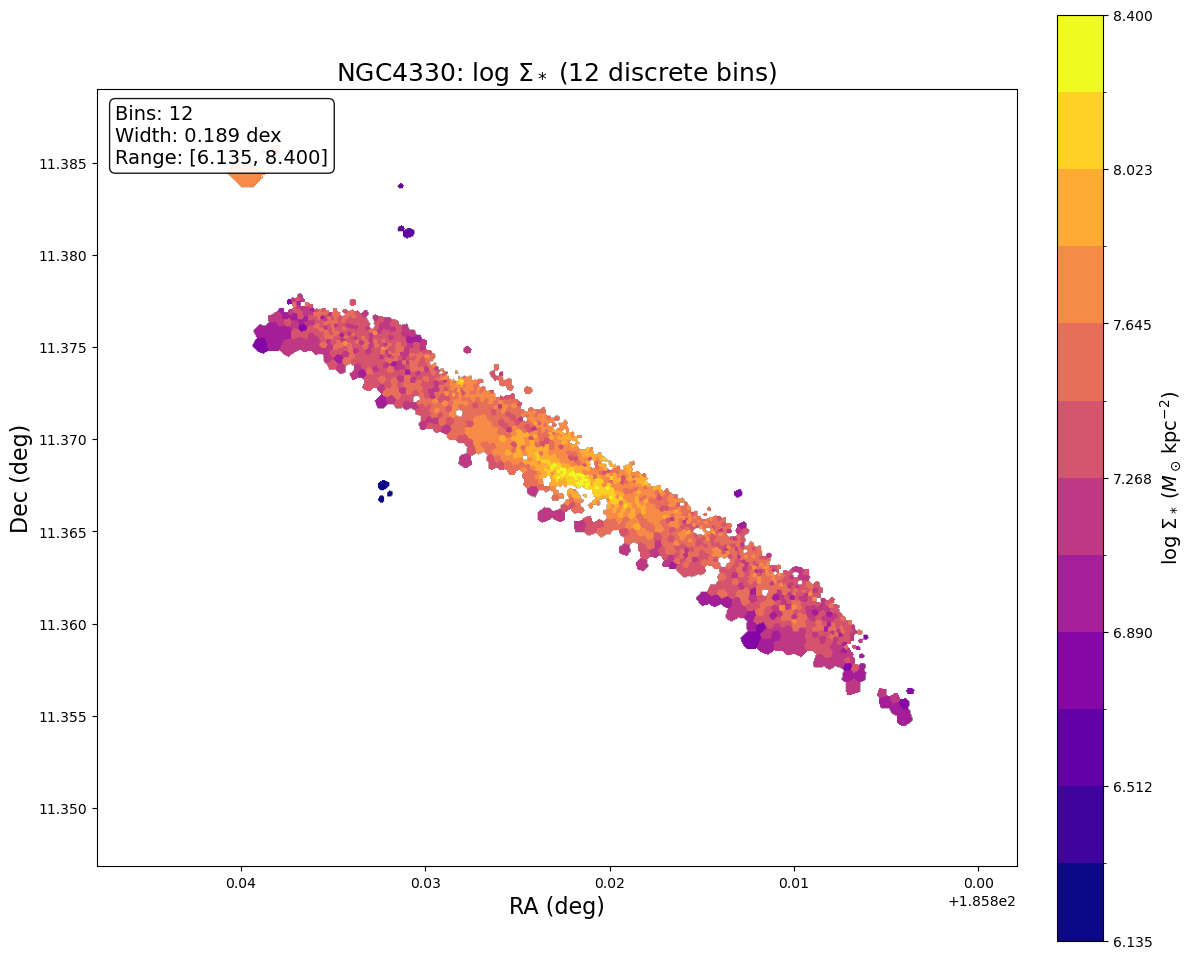

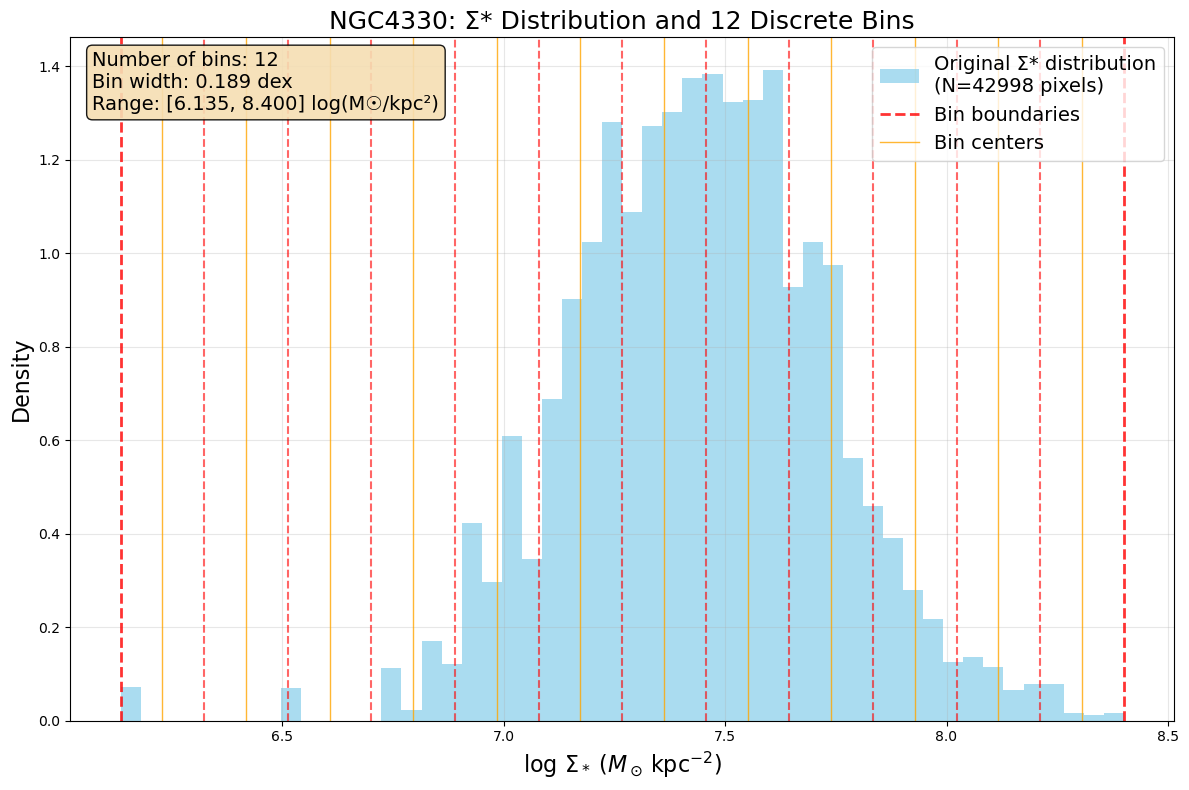

In [9]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and create discrete Σ* binned map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    sfh_path = f'{gal}_SFH_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(sfh_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(sfh_path) as h_sfh:
        age_map = h_sfh['AGE'].data
        metal_map = h_sfh['METAL'].data
    return sigM, sigSFR, oh_map, age_map, metal_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, age_map, metal_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps - based on HII region selection (oh_o3n2_map)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM) & valid_oh

    # Apply HII region mask to ensure all maps show the same spaxels
    sigM_masked = np.where(valid_oh, sigM, np.nan)

    # ------------------------------------------------------------------
    # 2.  Create discrete Σ* binned map (12 equal-width bins)
    # ------------------------------------------------------------------
    # Get valid Σ* pixels for binning
    valid_sigM_pixels = np.isfinite(sigM_masked)
    sigM_valid_data = sigM_masked[valid_sigM_pixels]
    
    # Define 12 equal-width bins across the Σ* range
    n_bins = 12
    sigM_min = np.nanmin(sigM_valid_data)
    sigM_max = np.nanmax(sigM_valid_data)
    bin_edges = np.linspace(sigM_min, sigM_max, n_bins + 1)
    
    # Create binned map
    sigM_binned_map = np.full_like(sigM_masked, np.nan)
    
    for i in range(n_bins):
        if i == n_bins - 1:  # Last bin includes right edge
            mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
        else:
            mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
        
        # Assign bin center value to binned map
        bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
        sigM_binned_map[mask] = bin_center
    
    print(f"Σ* binning summary for {gal}:")
    print(f"Range: {sigM_min:.3f} to {sigM_max:.3f} log(M☉/kpc²)")
    print(f"Bin width: {(sigM_max - sigM_min) / n_bins:.3f} log(M☉/kpc²)")
    print(f"Bin edges: {bin_edges}")
    
    # Count pixels in each bin
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
        else:
            mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
        pixel_count = np.sum(mask)
        bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
        print(f"Bin {i+1} [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): center={bin_center:.3f}, pixels={pixel_count}")

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create discrete Σ* binned map
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Create discrete colormap for the binned map
    bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(n_bins)]
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                              cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax.set_title(rf'{gal}: $\log\,\Sigma_*$ (12 discrete bins)', fontsize=18)
    ax.set_xlabel('RA (deg)', fontsize=16)
    ax.set_ylabel('Dec (deg)', fontsize=16)

    cbar_sigM_binned = fig.colorbar(im_sigM_binned, ax=ax, fraction=0.046, pad=0.04)
    cbar_sigM_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Add bin information annotation
    ax.text(0.02, 0.98, f'Bins: {n_bins}\nWidth: {(sigM_max - sigM_min) / n_bins:.3f} dex\nRange: [{sigM_min:.3f}, {sigM_max:.3f}]', 
            transform=ax.transAxes, fontsize=14, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # 5.  Create histogram of Σ* distribution and bin boundaries
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot histogram of original Σ* values
    ax.hist(sigM_valid_data, bins=50, alpha=0.7, density=True, color='skyblue', 
            label=f'Original Σ* distribution\n(N={len(sigM_valid_data)} pixels)')
    
    # Plot bin boundaries as vertical lines
    for i, edge in enumerate(bin_edges):
        if i == 0 or i == len(bin_edges) - 1:
            ax.axvline(edge, color='red', linestyle='--', alpha=0.8, linewidth=2,
                      label='Bin boundaries' if i == 0 else "")
        else:
            ax.axvline(edge, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # Plot bin centers
    for i, center in enumerate(bin_centers):
        ax.axvline(center, color='orange', linestyle='-', alpha=0.8, linewidth=1,
                  label='Bin centers' if i == 0 else "")
    
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16)
    ax.set_ylabel('Density', fontsize=16)
    ax.set_title(rf'{gal}: Σ* Distribution and 12 Discrete Bins', fontsize=18)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add text box with bin statistics
    textstr = f'Number of bins: {n_bins}\nBin width: {(sigM_max - sigM_min) / n_bins:.3f} dex\nRange: [{sigM_min:.3f}, {sigM_max:.3f}] log(M☉/kpc²)'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()


Average Σ* value per bin for NGC4330:
Bin 1 [6.135, 6.324): average=6.135
Bin 2 [6.324, 6.512): average=nan
Bin 3 [6.512, 6.701): average=6.525
Bin 4 [6.701, 6.890): average=6.821
Bin 5 [6.890, 7.079): average=6.993
Bin 6 [7.079, 7.268): average=7.187
Bin 7 [7.268, 7.456): average=7.364
Bin 8 [7.456, 7.645): average=7.546
Bin 9 [7.645, 7.834): average=7.722
Bin 10 [7.834, 8.023): average=7.905
Bin 11 [8.023, 8.212): average=8.107
Bin 12 [8.212, 8.400): average=8.267

Σ* bin-based offset statistics:
Max absolute offset: 0.133
Mean offset (should be ~0): 0.000000
Std of offset: 0.052


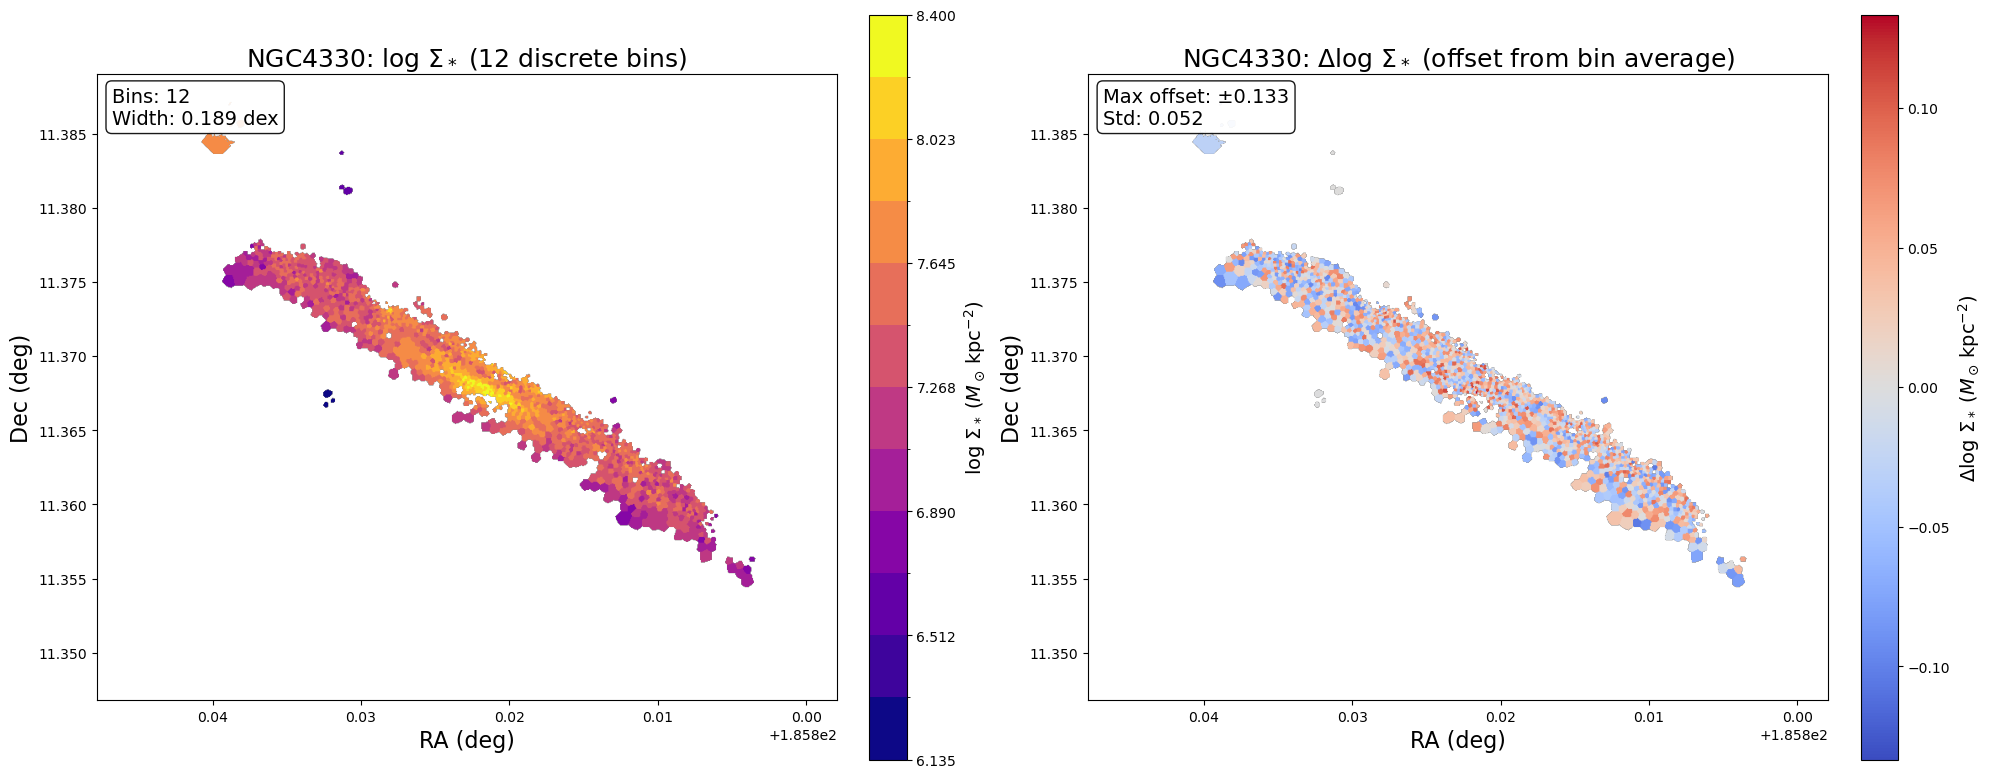

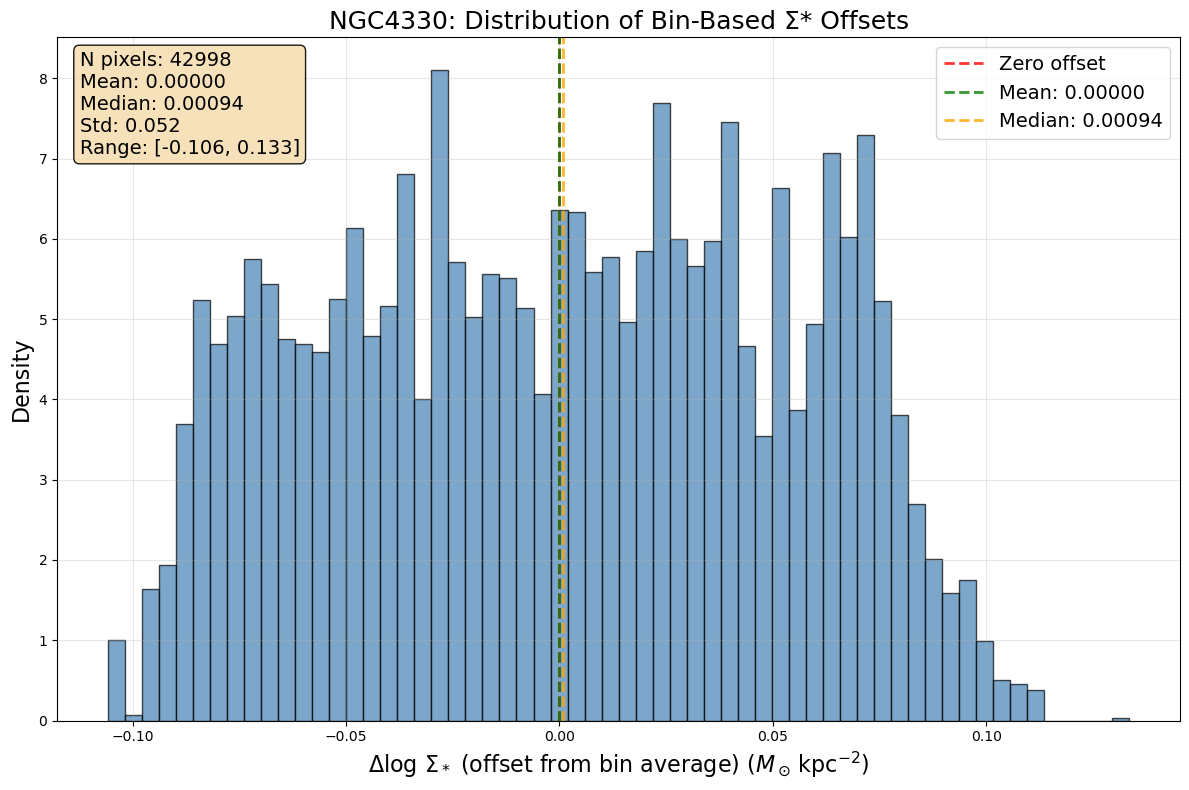

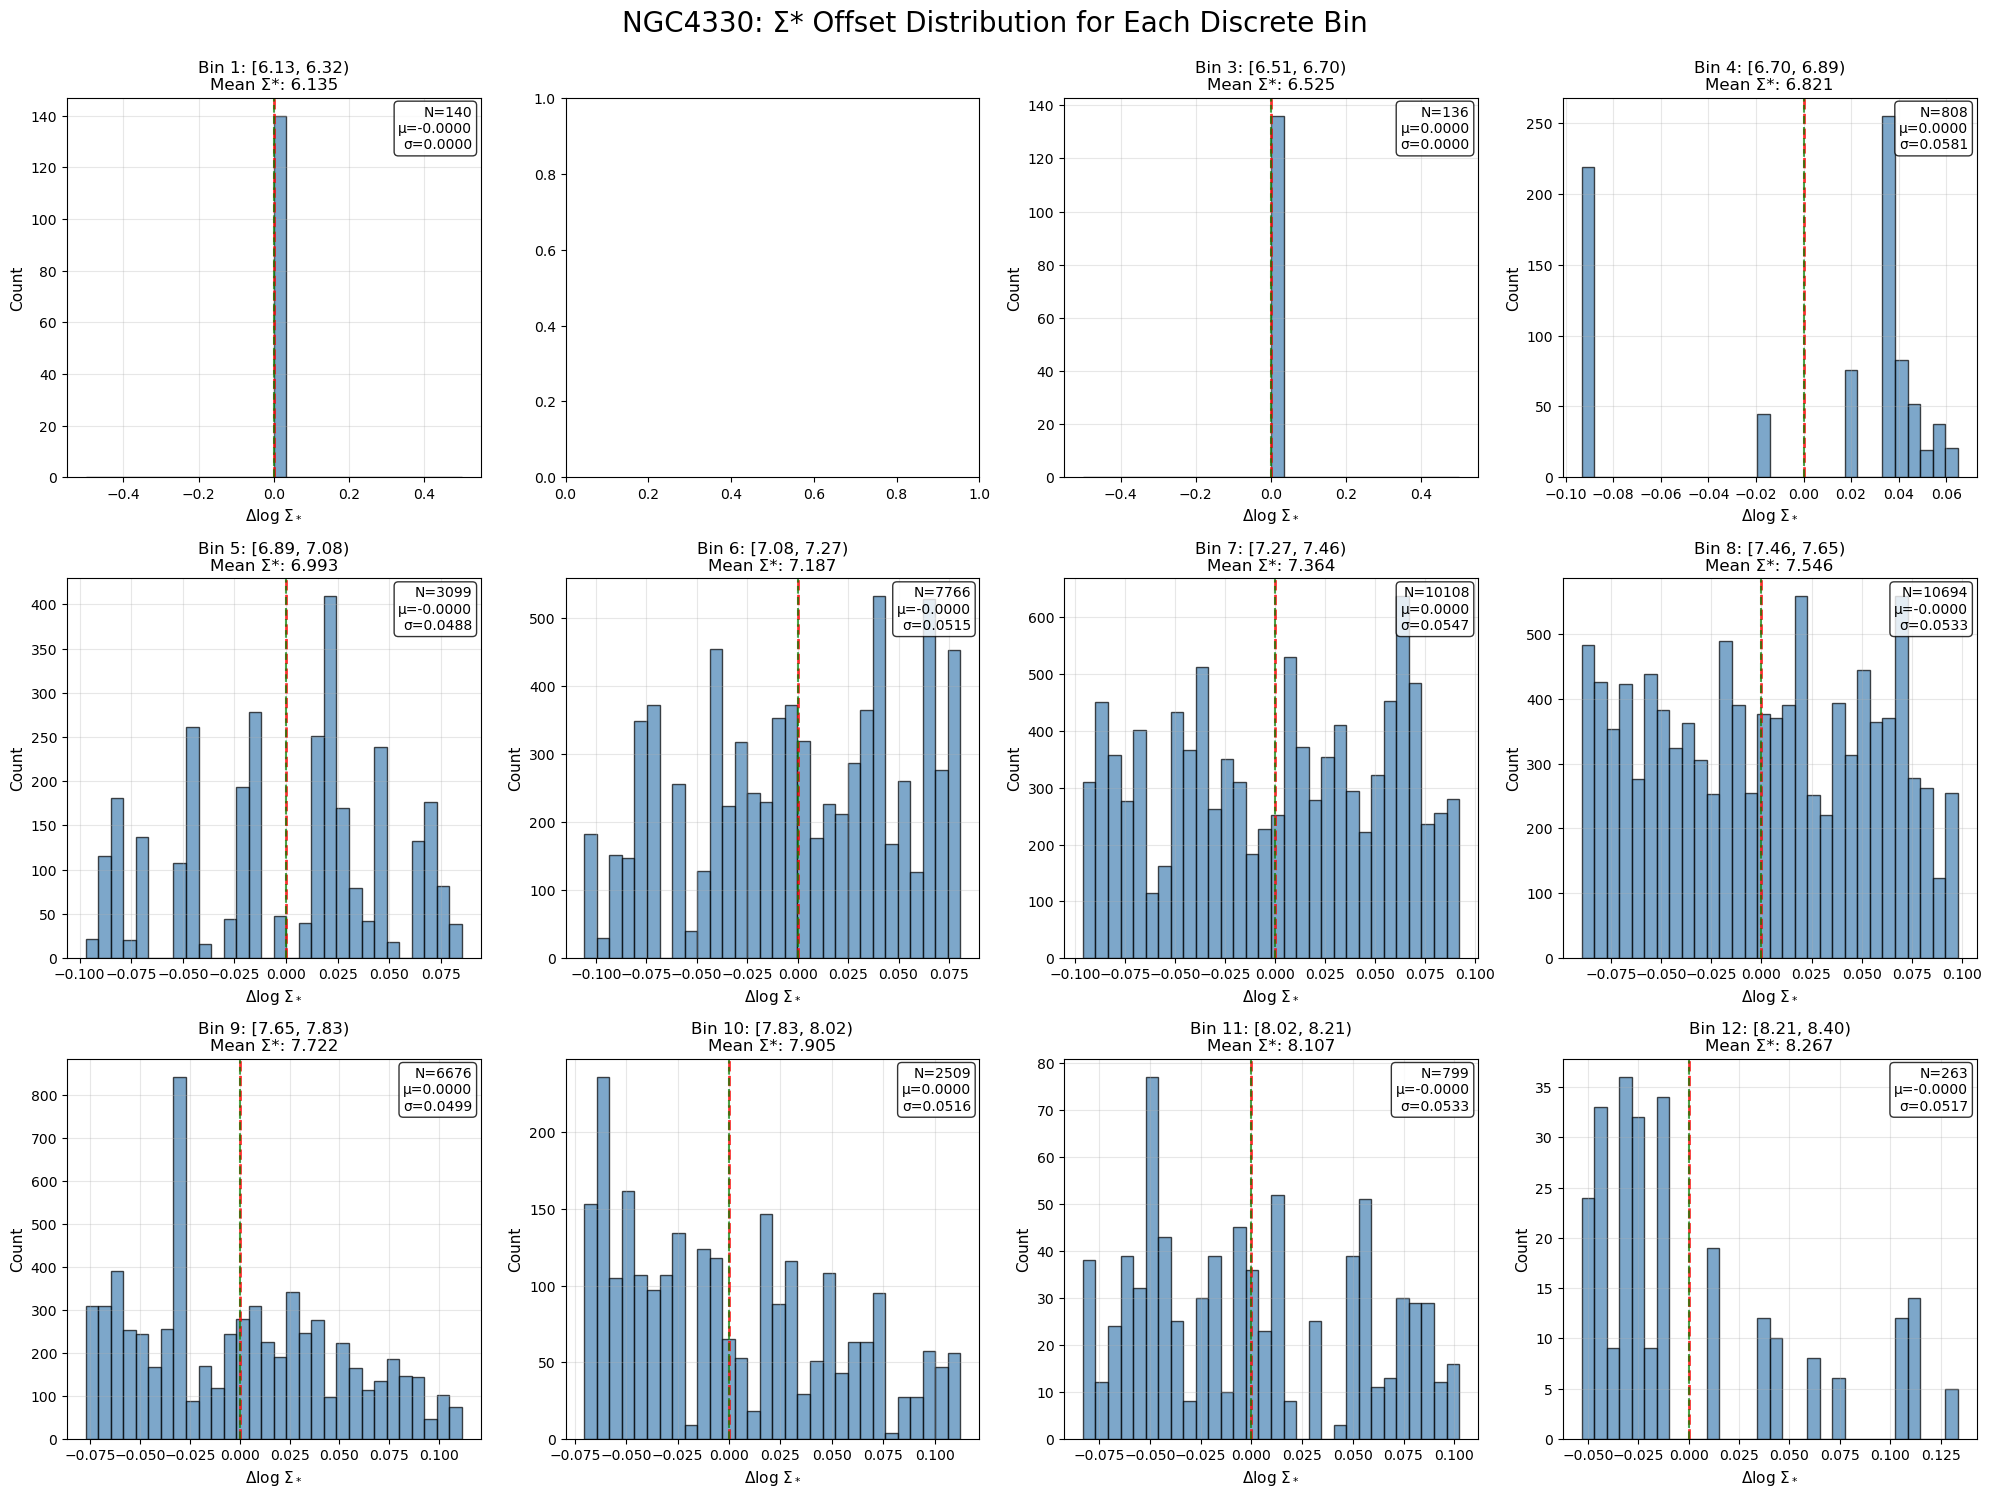

In [10]:
# ------------------------------------------------------------------
# Calculate Σ* offset map based on per-bin averages
# Each spaxel's offset = its Σ* value - average Σ* of its bin
# ------------------------------------------------------------------

# Calculate the average Σ* value for each bin
bin_averages = np.zeros(n_bins)
for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    bin_pixels = sigM_masked[mask]
    if len(bin_pixels) > 0:
        bin_averages[i] = np.nanmean(bin_pixels)
    else:
        bin_averages[i] = np.nan

print(f"\nAverage Σ* value per bin for {gal}:")
for i in range(n_bins):
    print(f"Bin {i+1} [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): average={bin_averages[i]:.3f}")

# Create the offset map: subtract bin average from each spaxel
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # For each spaxel in this bin, calculate offset from bin average
    sigM_bin_offset[mask] = sigM_masked[mask] - bin_averages[i]

# Calculate the maximum absolute offset for symmetric colorbar
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nΣ* bin-based offset statistics:")
print(f"Max absolute offset: {sigM_bin_offset_max:.3f}")
print(f"Mean offset (should be ~0): {np.nanmean(sigM_bin_offset):.6f}")
print(f"Std of offset: {np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# Plot the bin-based Σ* offset map
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left panel: Original discrete Σ* map (for reference)
cmap_discrete = plt.cm.plasma
norm_discrete = BoundaryNorm(bin_edges, cmap_discrete.N)

im_sigM_binned = axes[0].imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
axes[0].set_title(rf'{gal}: $\log\,\Sigma_*$ (12 discrete bins)', fontsize=18)
axes[0].set_xlabel('RA (deg)', fontsize=16)
axes[0].set_ylabel('Dec (deg)', fontsize=16)

cbar_binned = fig.colorbar(im_sigM_binned, ax=axes[0], fraction=0.046, pad=0.04)
cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

axes[0].text(0.02, 0.98, f'Bins: {n_bins}\nWidth: {(sigM_max - sigM_min) / n_bins:.3f} dex', 
            transform=axes[0].transAxes, fontsize=14, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Right panel: Bin-based Σ* offset map
im_offset = axes[1].imshow(np.ma.masked_invalid(sigM_bin_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-sigM_bin_offset_max, vmax=sigM_bin_offset_max)
axes[1].set_title(rf'{gal}: $\Delta\log\,\Sigma_*$ (offset from bin average)', fontsize=18)
axes[1].set_xlabel('RA (deg)', fontsize=16)
axes[1].set_ylabel('Dec (deg)', fontsize=16)

cbar_offset = fig.colorbar(im_offset, ax=axes[1], fraction=0.046, pad=0.04)
cbar_offset.set_label(r'$\Delta\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

axes[1].text(0.02, 0.98, f'Max offset: ±{sigM_bin_offset_max:.3f}\nStd: {np.nanstd(sigM_bin_offset):.3f}', 
            transform=axes[1].transAxes, fontsize=14, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Create histogram of the bin-based offset distribution
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Flatten the offset map and remove NaNs
offset_values = sigM_bin_offset[np.isfinite(sigM_bin_offset)]

# Plot histogram
n_hist, bins_hist, patches = ax.hist(offset_values, bins=60, alpha=0.7, color='steelblue', 
                                      edgecolor='black', density=True)

# Add vertical line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero offset', alpha=0.8)

# Add mean and median lines
offset_mean = np.nanmean(offset_values)
offset_median = np.nanmedian(offset_values)
ax.axvline(offset_mean, color='green', linestyle='--', linewidth=2, 
          label=f'Mean: {offset_mean:.5f}', alpha=0.8)
ax.axvline(offset_median, color='orange', linestyle='--', linewidth=2, 
          label=f'Median: {offset_median:.5f}', alpha=0.8)

ax.set_xlabel(r'$\Delta\log\,\Sigma_*$ (offset from bin average) $(M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
ax.set_title(rf'{gal}: Distribution of Bin-Based Σ* Offsets', fontsize=18)
ax.legend(fontsize=14, loc='upper right')
ax.grid(True, alpha=0.3)

# Add statistics text box
stats_text = f'N pixels: {len(offset_values)}\n'
stats_text += f'Mean: {offset_mean:.5f}\n'
stats_text += f'Median: {offset_median:.5f}\n'
stats_text += f'Std: {np.nanstd(offset_values):.3f}\n'
stats_text += f'Range: [{np.nanmin(offset_values):.3f}, {np.nanmax(offset_values):.3f}]'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Create histogram showing offset distribution per bin
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i in range(n_bins):
    if i == n_bins - 1:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    bin_offset_values = sigM_bin_offset[mask]
    bin_offset_values = bin_offset_values[np.isfinite(bin_offset_values)]
    
    if len(bin_offset_values) > 0:
        axes[i].hist(bin_offset_values, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[i].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)
        axes[i].axvline(np.mean(bin_offset_values), color='green', linestyle='--', 
                       linewidth=1.5, alpha=0.7)
        
        axes[i].set_title(f'Bin {i+1}: [{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})\n'
                         f'Mean Σ*: {bin_averages[i]:.3f}', fontsize=12)
        axes[i].set_xlabel(r'$\Delta\log\,\Sigma_*$', fontsize=11)
        axes[i].set_ylabel('Count', fontsize=11)
        axes[i].grid(True, alpha=0.3)
        
        # Add statistics
        stats = f'N={len(bin_offset_values)}\nμ={np.mean(bin_offset_values):.4f}\nσ={np.std(bin_offset_values):.4f}'
        axes[i].text(0.98, 0.98, stats, transform=axes[i].transAxes, fontsize=10,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle(rf'{gal}: Σ* Offset Distribution for Each Discrete Bin', fontsize=20, y=0.995)
plt.tight_layout()
plt.show()

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1975464213.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


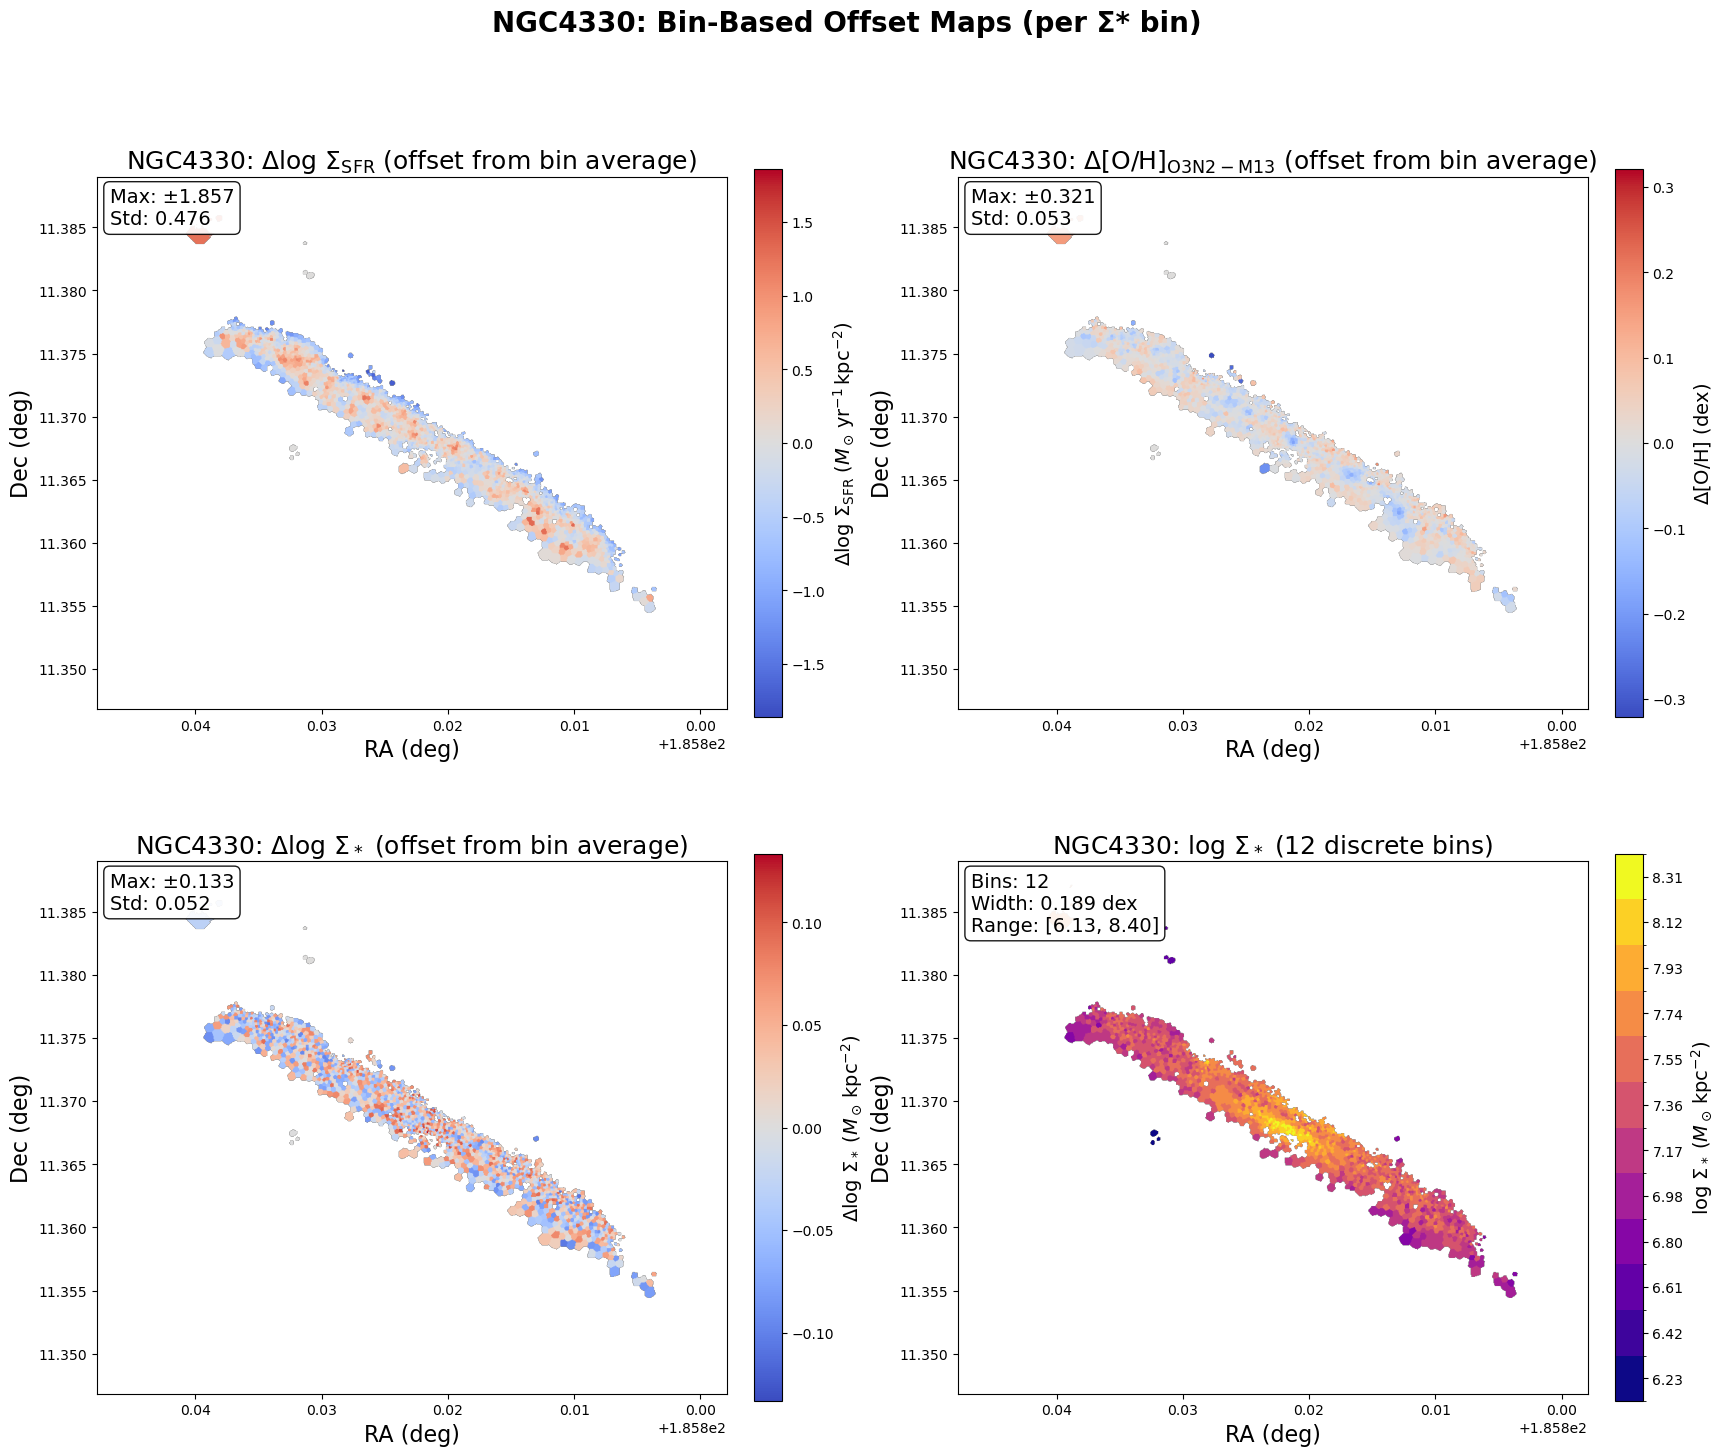


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998


In [11]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + statistics table
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: Σ_SFR bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: [O/H] bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_oh = ax2.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Σ_* bin-based offset map
ax3 = fig.add_subplot(gs[1, 0])
im_sigM = ax3.imshow(np.ma.masked_invalid(sigM_bin_offset), origin='lower', cmap='coolwarm',
                     extent=extent, vmin=-sigM_bin_offset_max, vmax=sigM_bin_offset_max)
ax3.set_title(rf'{gal}: $\Delta\log\,\Sigma_*$ (offset from bin average)', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_sigM = fig.colorbar(im_sigM, ax=ax3, fraction=0.046, pad=0.04)
cbar_sigM.set_label(r'$\Delta\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{sigM_bin_offset_max:.3f}\nStd: {np.nanstd(sigM_bin_offset):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Discrete Σ* binned map
ax4 = fig.add_subplot(gs[1, 1])

# Create discrete colormap for the binned map
cmap_discrete = plt.cm.plasma
norm_discrete = BoundaryNorm(bin_edges, cmap_discrete.N)

im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                            cmap=cmap_discrete, norm=norm_discrete, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each bin
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(n_bins)]
cbar_binned.set_ticks(bin_centers)
cbar_binned.set_ticklabels([f'{center:.2f}' for center in bin_centers])

ax4.text(0.02, 0.98, f'Bins: {n_bins}\nWidth: {(sigM_max - sigM_min) / n_bins:.3f} dex\nRange: [{sigM_min:.2f}, {sigM_max:.2f}]', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps (per Σ* bin)', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")
print(f"{'='*80}")

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/4280390435.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


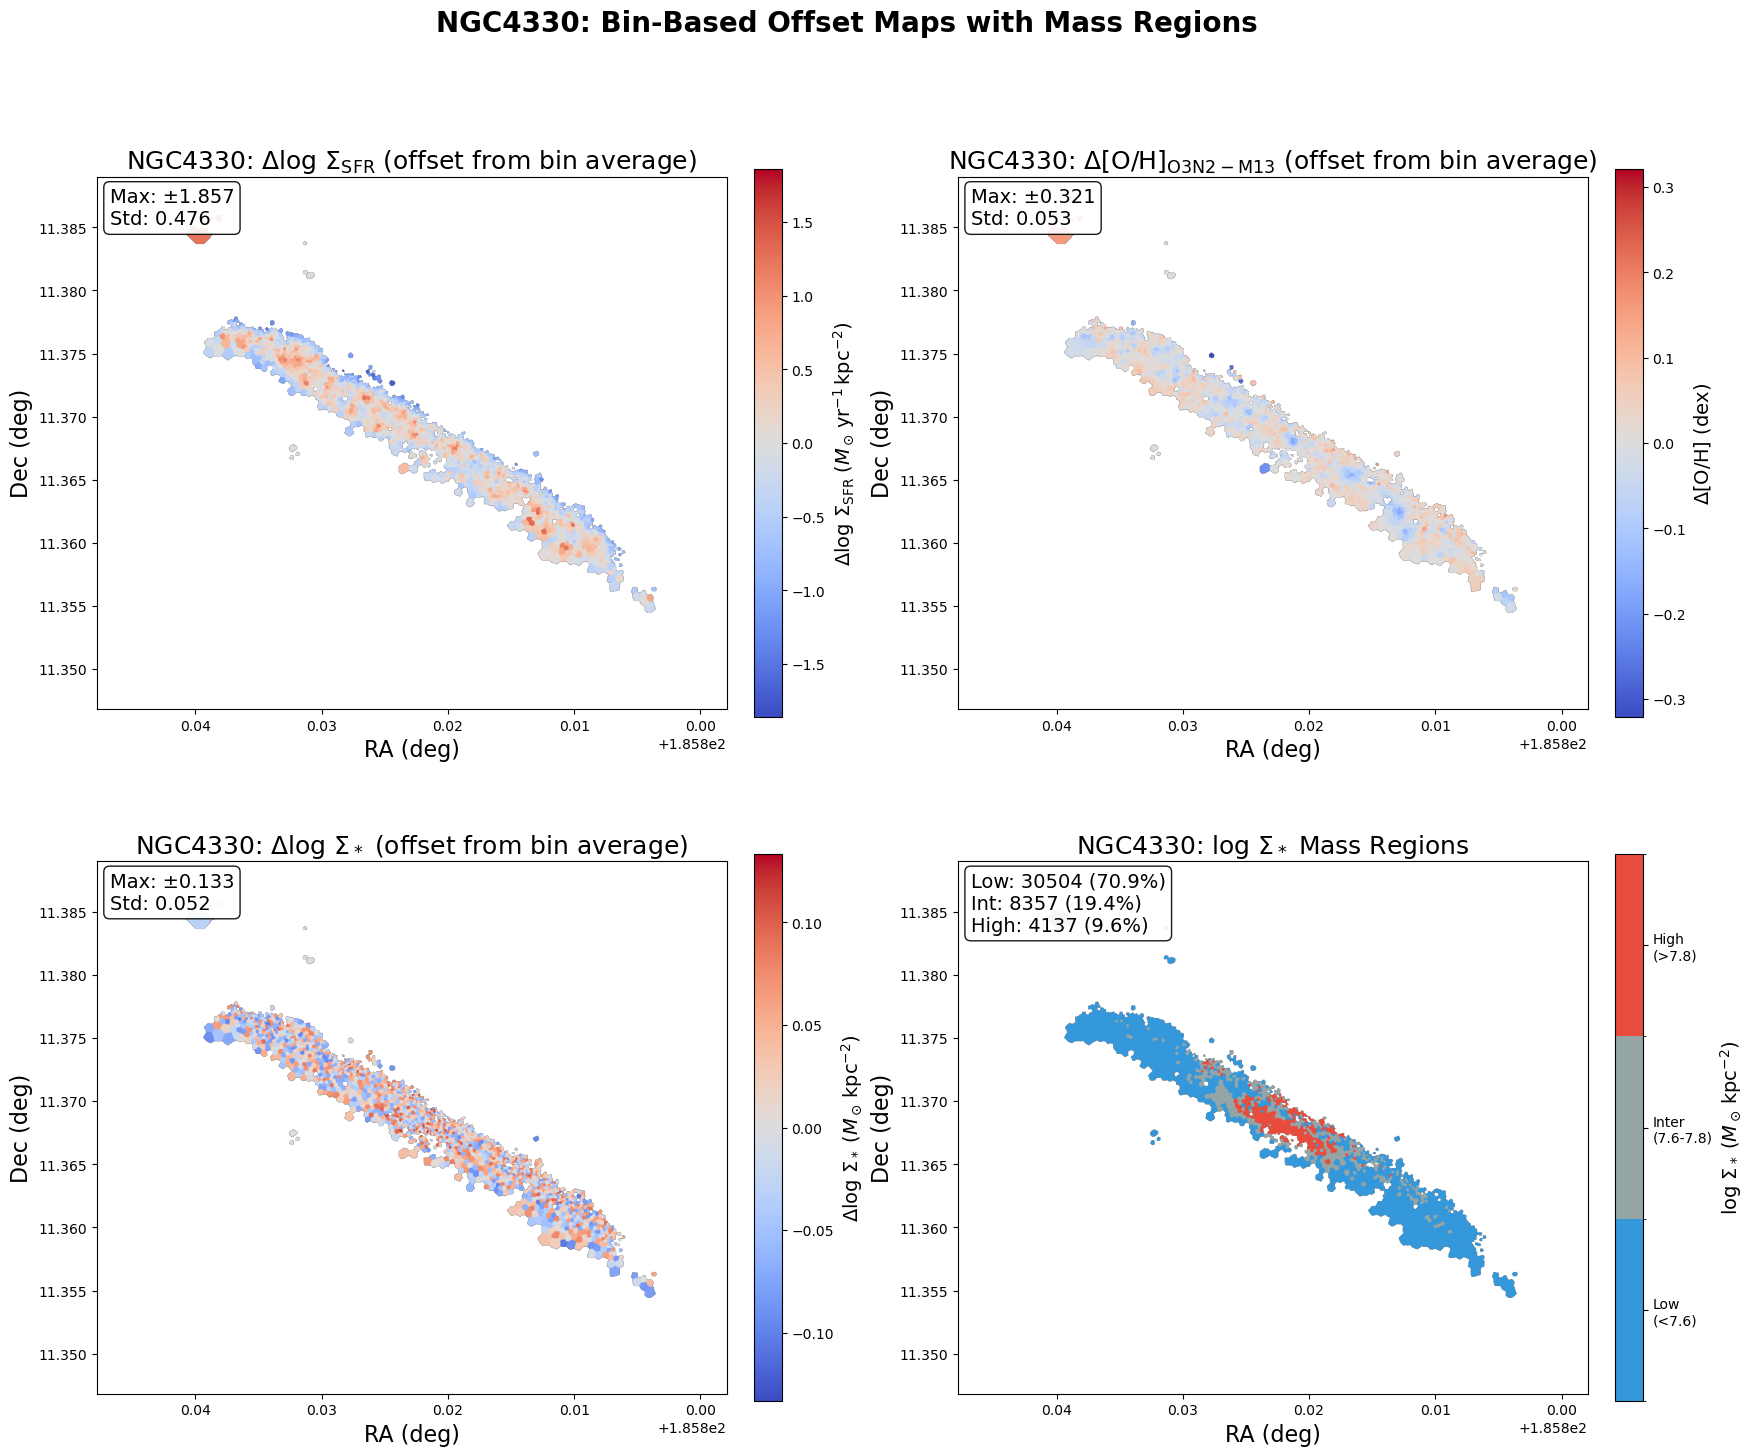


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9.6%)
  Total: 42998 pixels


In [12]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: Σ_SFR bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: [O/H] bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_oh = ax2.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Σ_* bin-based offset map
ax3 = fig.add_subplot(gs[1, 0])
im_sigM = ax3.imshow(np.ma.masked_invalid(sigM_bin_offset), origin='lower', cmap='coolwarm',
                     extent=extent, vmin=-sigM_bin_offset_max, vmax=sigM_bin_offset_max)
ax3.set_title(rf'{gal}: $\Delta\log\,\Sigma_*$ (offset from bin average)', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_sigM = fig.colorbar(im_sigM, ax=ax3, fraction=0.046, pad=0.04)
cbar_sigM.set_label(r'$\Delta\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{sigM_bin_offset_max:.3f}\nStd: {np.nanstd(sigM_bin_offset):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")

## 20251014 How about $\Delta\mathrm{[O/H]}_\mathrm{O3N2-M13}/\Delta\Sigma_\mathrm{SFR}$ map?

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1530389718.py:133: RuntimeWarning: divide by zero encountered in divide
  oh_sfr_ratio = oh_bin_offset / sfr_bin_offset
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1867: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1530389718.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


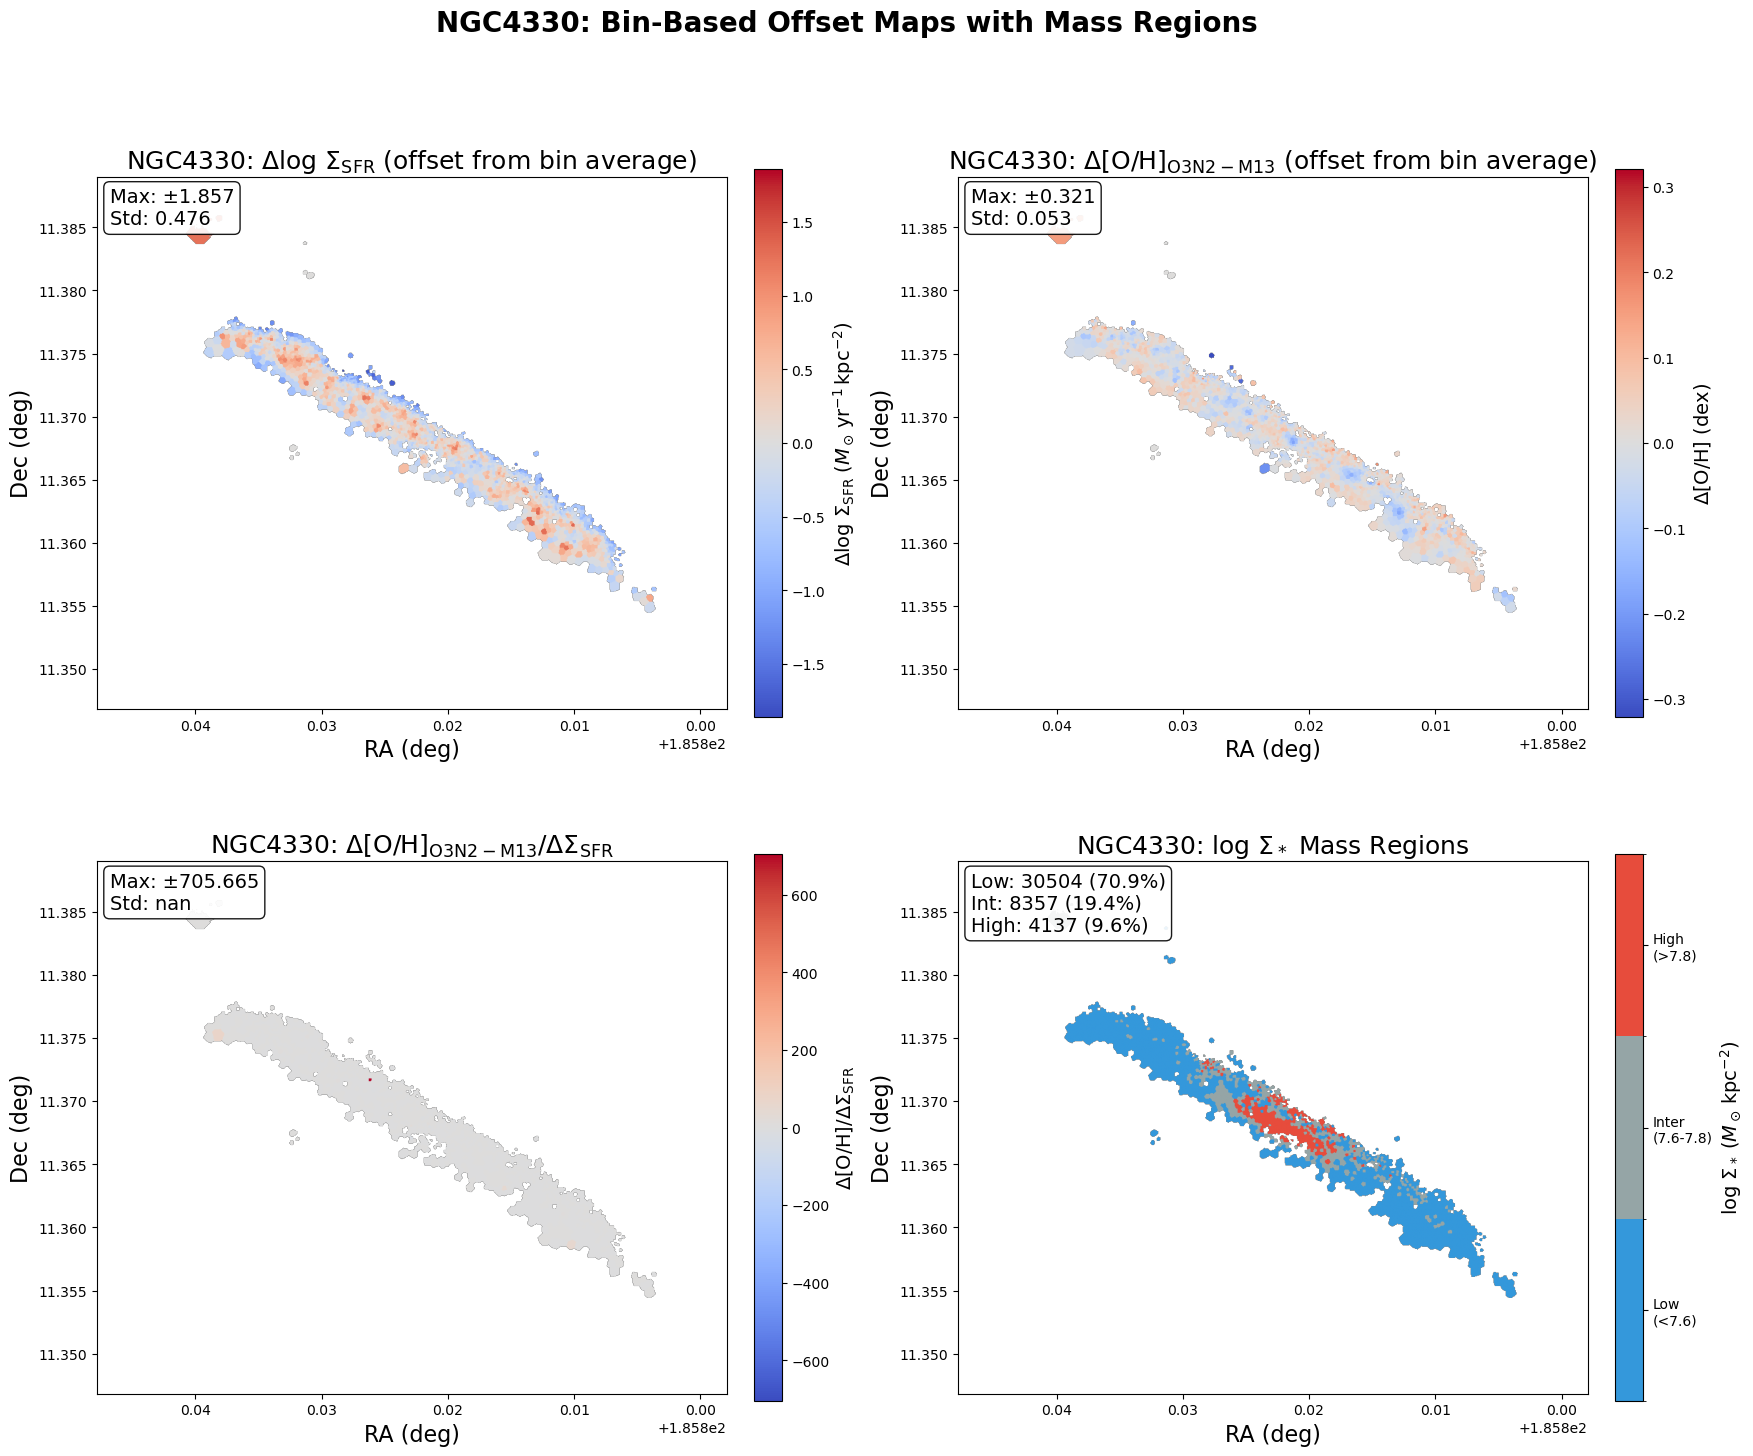


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

Δ[O/H]/ΔΣSFR ratio:
  Mean: inf
  Median: -0.016814
  Std: nan
  Range: [-20.7238, inf]
  Max |ratio|: ±705.6652
  Valid pixels: 42862

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9.6%)
  Total: 42998 pixels


/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1867: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


In [13]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: Σ_SFR bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: [O/H] bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_oh = ax2.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Ratio map (Δ[O/H] / ΔΣSFR)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate ratio: Δ[O/H] / ΔΣSFR
oh_sfr_ratio = oh_bin_offset / sfr_bin_offset

# Calculate symmetric colorbar limits
oh_sfr_ratio_max = np.nanmax(np.abs(oh_sfr_ratio[np.isfinite(oh_sfr_ratio)]))

im_ratio = ax3.imshow(np.ma.masked_invalid(oh_sfr_ratio), origin='lower', cmap='coolwarm',
                     extent=extent, vmin=-oh_sfr_ratio_max, vmax=oh_sfr_ratio_max)
ax3.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}/\Delta\Sigma_{{\mathrm{{SFR}}}}$', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_ratio = fig.colorbar(im_ratio, ax=ax3, fraction=0.046, pad=0.04)
cbar_ratio.set_label(r'$\Delta$[O/H]/$\Delta\Sigma_{\mathrm{SFR}}$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{oh_sfr_ratio_max:.3f}\nStd: {np.nanstd(oh_sfr_ratio):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔ[O/H]/ΔΣSFR ratio:")
print(f"  Mean: {np.nanmean(oh_sfr_ratio):.6f}")
print(f"  Median: {np.nanmedian(oh_sfr_ratio):.6f}")
print(f"  Std: {np.nanstd(oh_sfr_ratio):.4f}")
print(f"  Range: [{np.nanmin(oh_sfr_ratio):.4f}, {np.nanmax(oh_sfr_ratio):.4f}]")
print(f"  Max |ratio|: ±{oh_sfr_ratio_max:.4f}")
print(f"  Valid pixels: {np.sum(np.isfinite(oh_sfr_ratio))}")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1671303602.py:133: RuntimeWarning: divide by zero encountered in divide
  sfr_oh_ratio = sfr_bin_offset / oh_bin_offset
/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1867: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1671303602.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


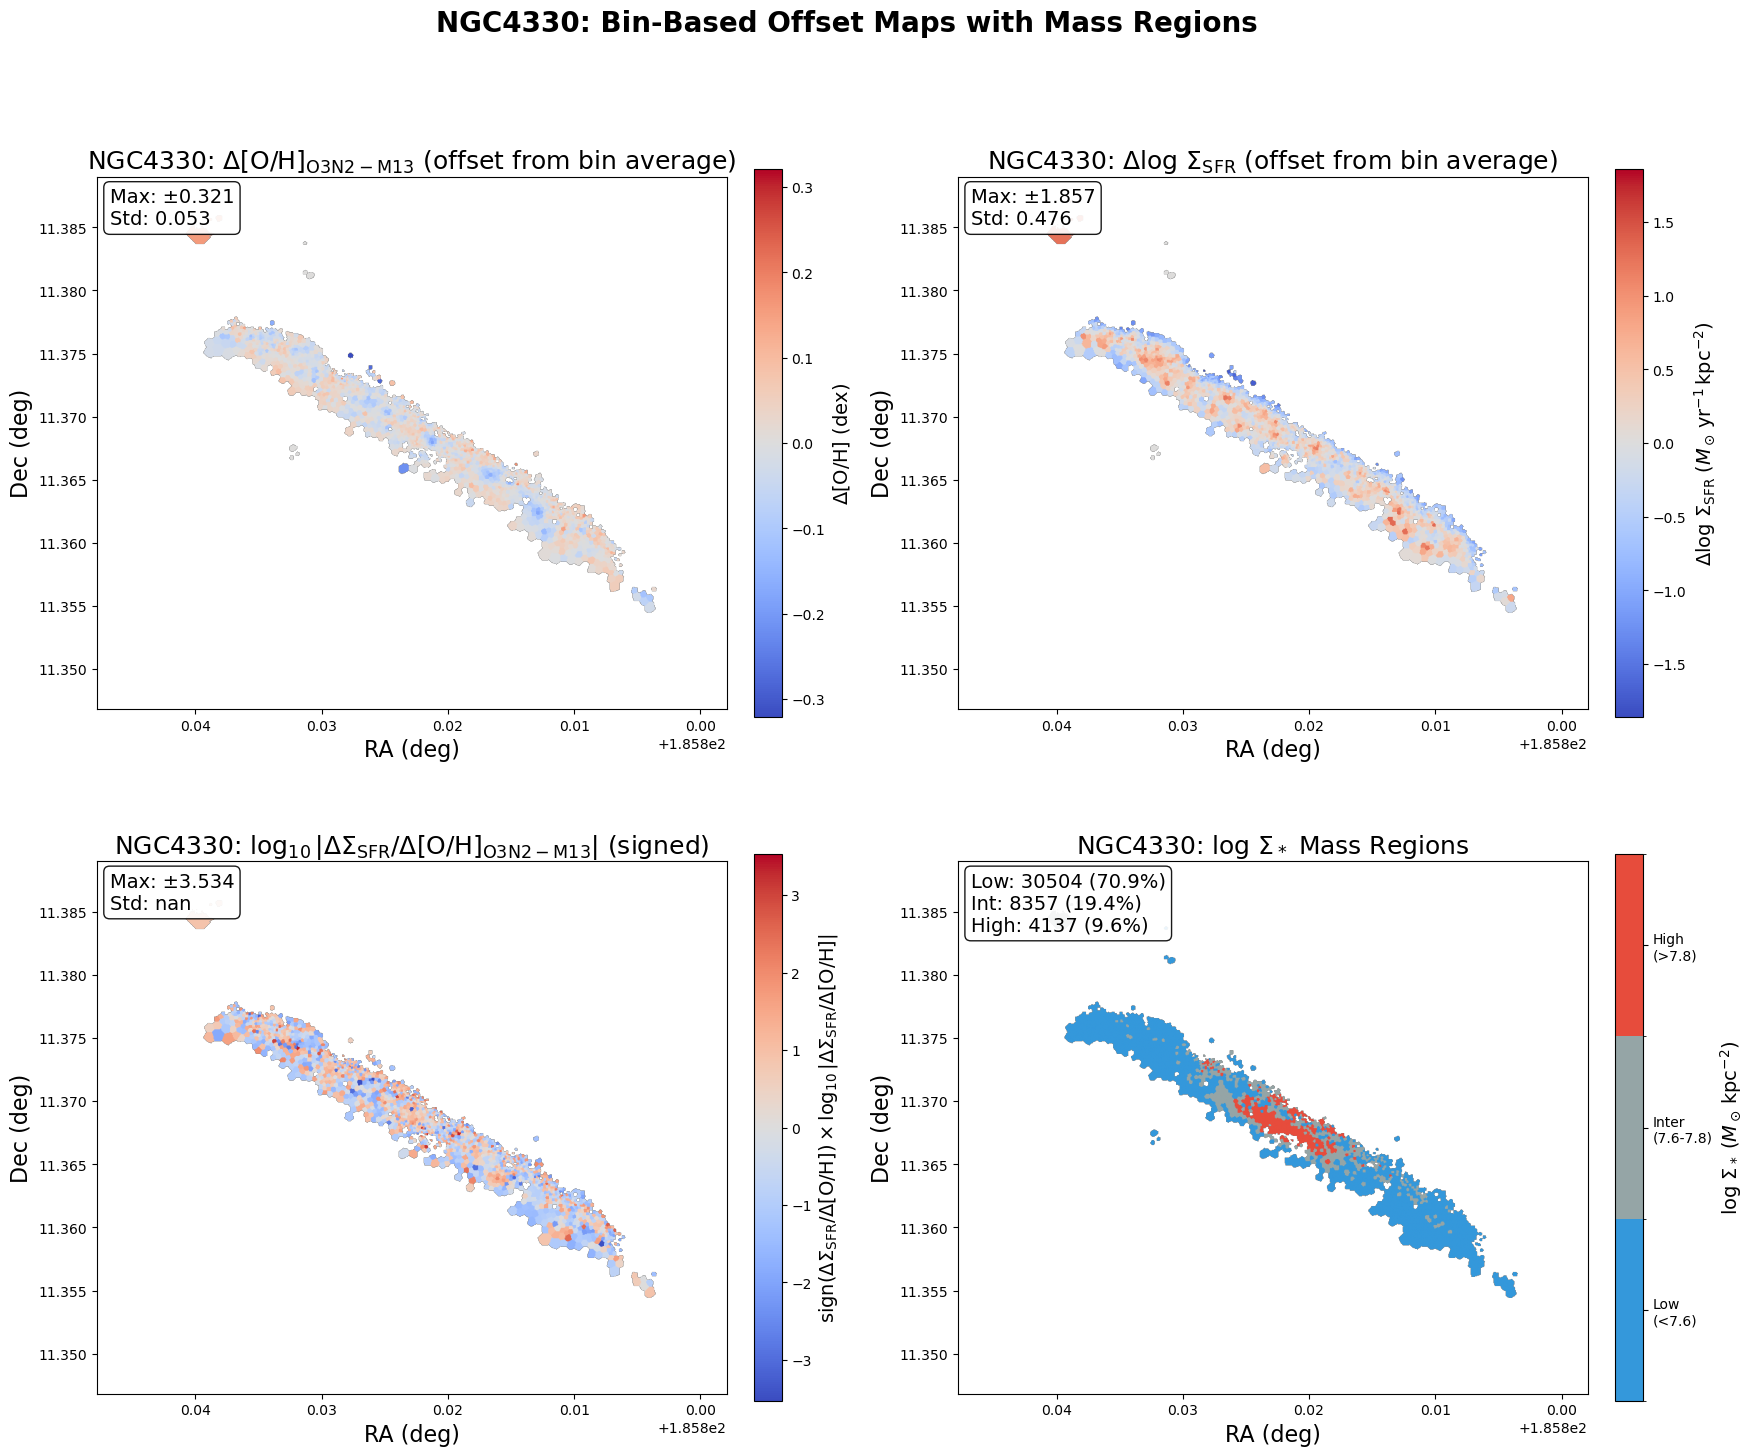


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

ΔΣSFR/Δ[O/H] ratio (linear space):
  Mean: inf
  Median: -1.805893
  Std: nan
  Range: [-3416.7931, inf]
  Valid pixels: 42858

ΔΣSFR/Δ[O/H] ratio (log space, signed):
  Mean: inf
  Median: -0.377029
  Std: nan
  Range: [-3.5336, inf]
  Max |log ratio|: ±3.5336
  Valid pixels: 42722

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1867: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


In [14]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: [O/H] bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_oh = ax1.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax1, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: Σ_SFR bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_sfr = ax2.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax2, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Ratio map in log space (log10(|ΔΣSFR / Δ[O/H]|) with sign preserved)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate ratio: ΔΣSFR / Δ[O/H] in linear space
sfr_oh_ratio = sfr_bin_offset / oh_bin_offset

# Convert to log space while preserving sign:
# If ratio is positive: log10(ratio)
# If ratio is negative: -log10(|ratio|)
sfr_oh_ratio_log = np.full_like(sfr_oh_ratio, np.nan)
positive_mask = sfr_oh_ratio > 0
negative_mask = sfr_oh_ratio < 0

sfr_oh_ratio_log[positive_mask] = np.log10(sfr_oh_ratio[positive_mask])
sfr_oh_ratio_log[negative_mask] = -np.log10(np.abs(sfr_oh_ratio[negative_mask]))

# Calculate symmetric colorbar limits
sfr_oh_ratio_log_max = np.nanmax(np.abs(sfr_oh_ratio_log[np.isfinite(sfr_oh_ratio_log)]))

im_ratio = ax3.imshow(np.ma.masked_invalid(sfr_oh_ratio_log), origin='lower', cmap='coolwarm',
                     extent=extent, vmin=-sfr_oh_ratio_log_max, vmax=sfr_oh_ratio_log_max)
ax3.set_title(rf'{gal}: $\log_{{\mathrm{{10}}}}|\Delta\Sigma_{{\mathrm{{SFR}}}}/\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}|$ (signed)', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_ratio = fig.colorbar(im_ratio, ax=ax3, fraction=0.046, pad=0.04)
cbar_ratio.set_label(r'$\mathrm{sign}(\Delta\Sigma_{\mathrm{SFR}}/\Delta\mathrm{[O/H]}) \times \log_{10}|\Delta\Sigma_{\mathrm{SFR}}/\Delta\mathrm{[O/H]}|$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{sfr_oh_ratio_log_max:.3f}\nStd: {np.nanstd(sfr_oh_ratio_log):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔΣSFR/Δ[O/H] ratio (linear space):")
print(f"  Mean: {np.nanmean(sfr_oh_ratio):.6f}")
print(f"  Median: {np.nanmedian(sfr_oh_ratio):.6f}")
print(f"  Std: {np.nanstd(sfr_oh_ratio):.4f}")
print(f"  Range: [{np.nanmin(sfr_oh_ratio):.4f}, {np.nanmax(sfr_oh_ratio):.4f}]")
print(f"  Valid pixels: {np.sum(np.isfinite(sfr_oh_ratio))}")

print(f"\nΔΣSFR/Δ[O/H] ratio (log space, signed):")
print(f"  Mean: {np.nanmean(sfr_oh_ratio_log):.6f}")
print(f"  Median: {np.nanmedian(sfr_oh_ratio_log):.6f}")
print(f"  Std: {np.nanstd(sfr_oh_ratio_log):.4f}")
print(f"  Range: [{np.nanmin(sfr_oh_ratio_log):.4f}, {np.nanmax(sfr_oh_ratio_log):.4f}]")
print(f"  Max |log ratio|: ±{sfr_oh_ratio_log_max:.4f}")
print(f"  Valid pixels: {np.sum(np.isfinite(sfr_oh_ratio_log))}")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/3780171467.py:133: RuntimeWarning: divide by zero encountered in divide
  sfr_oh_ratio = sfr_bin_offset / oh_bin_offset
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/3780171467.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


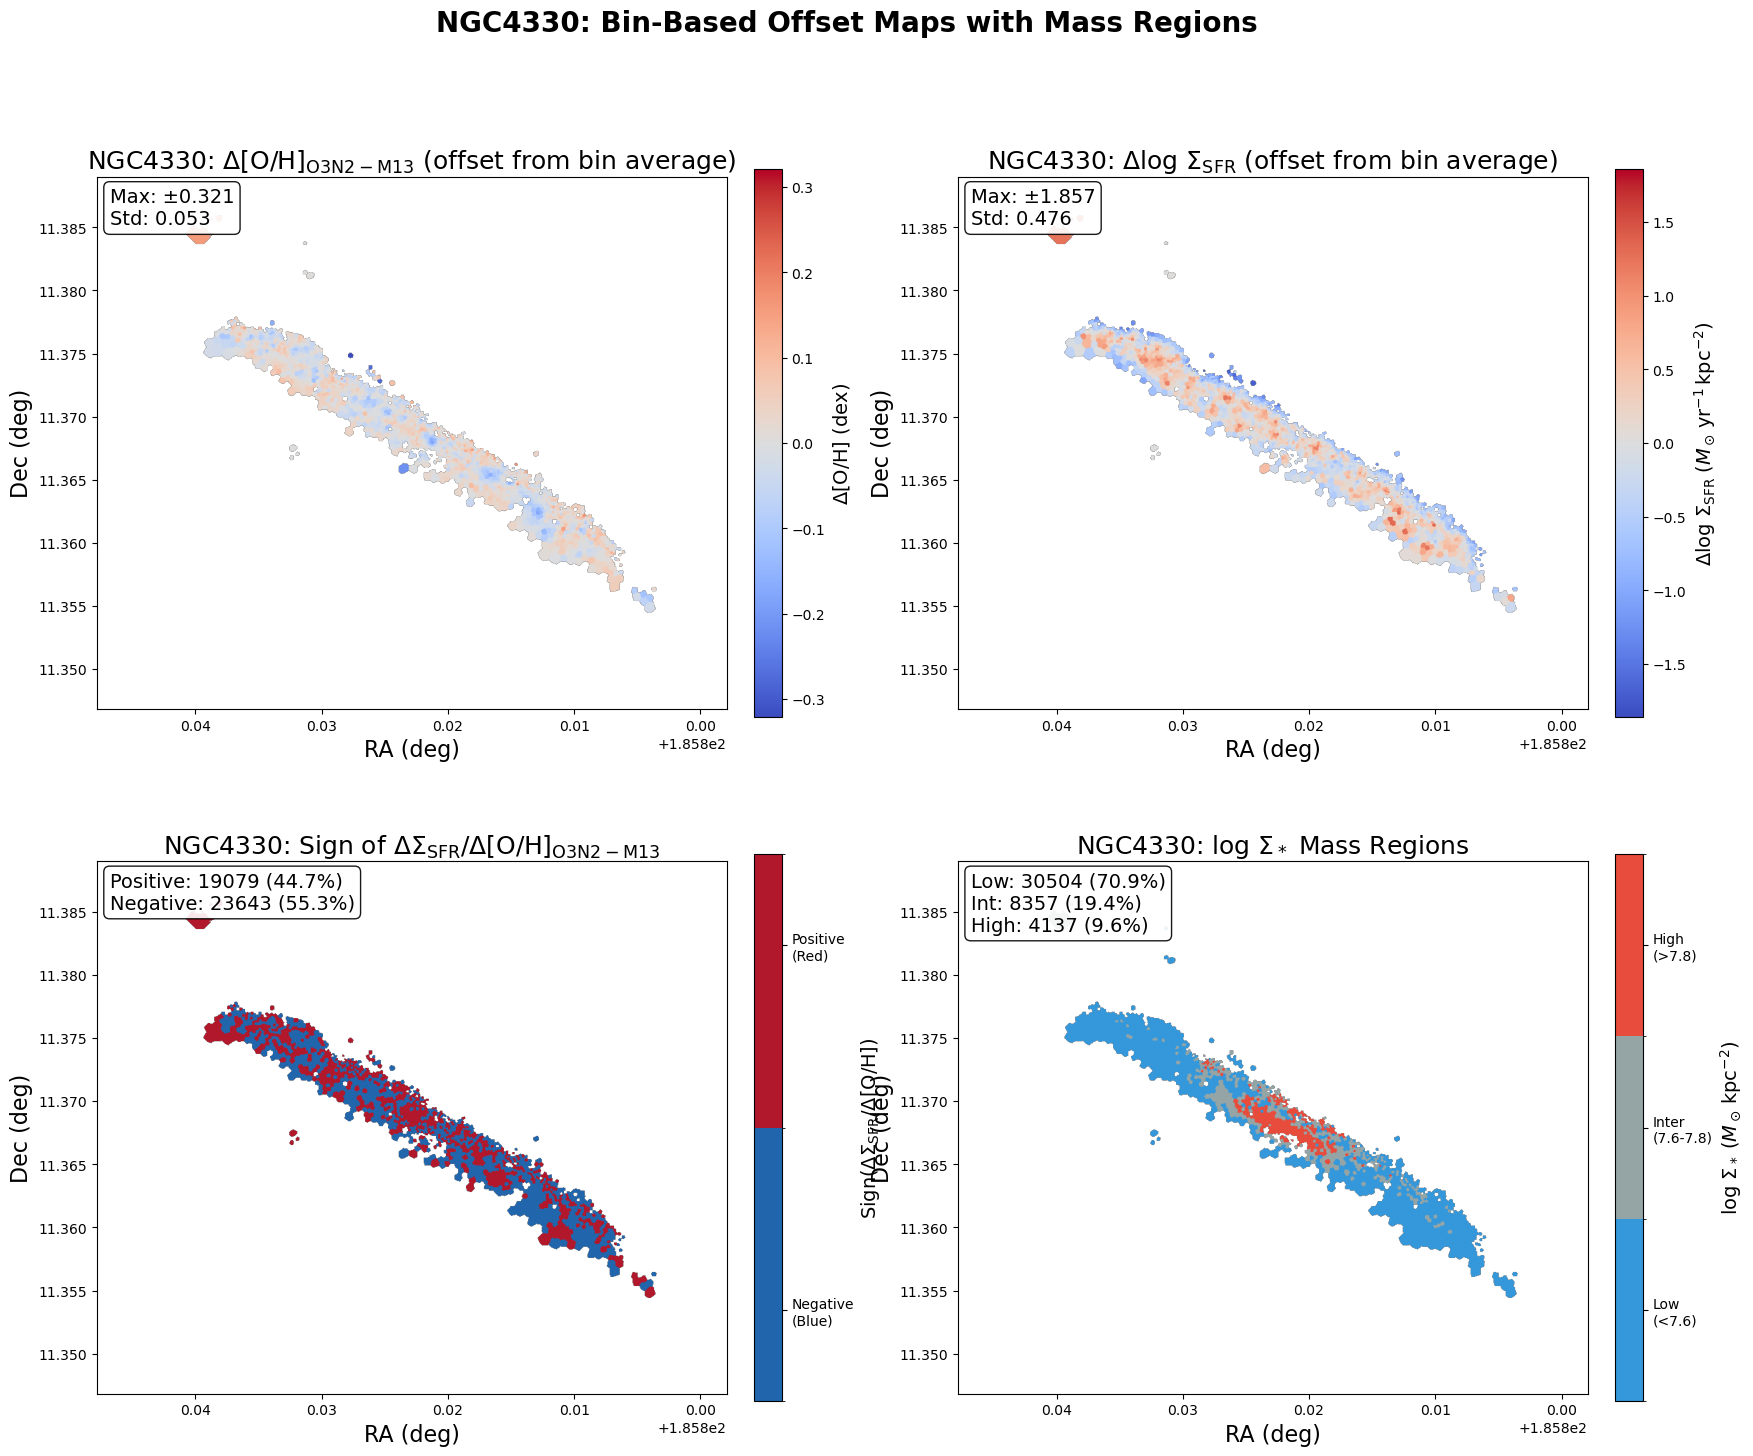


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

ΔΣSFR/Δ[O/H] ratio (linear space):
  Mean: inf
  Median: -1.805893
  Std: nan
  Range: [-3416.7931, inf]
  Valid pixels: 42858

ΔΣSFR/Δ[O/H] sign distribution:
  Positive ratios: 19079 pixels (44.7%)
  Negative ratios: 23643 pixels (55.3%)
  Total: 42722 pixels

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9.6%)
  Total: 42998 pi

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1867: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


In [15]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: [O/H] bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_oh = ax1.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax1, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: Σ_SFR bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_sfr = ax2.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax2, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Binary sign map (positive=red, negative=blue)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate ratio: ΔΣSFR / Δ[O/H] in linear space
sfr_oh_ratio = sfr_bin_offset / oh_bin_offset

# Create binary sign map: positive=1 (red), negative=-1 (blue)
sfr_oh_ratio_sign = np.full_like(sfr_oh_ratio, np.nan)
positive_mask = sfr_oh_ratio > 0
negative_mask = sfr_oh_ratio < 0

sfr_oh_ratio_sign[positive_mask] = 1   # Positive ratios -> red
sfr_oh_ratio_sign[negative_mask] = -1  # Negative ratios -> blue

# Create custom binary colormap: blue for -1, red for +1
from matplotlib.colors import ListedColormap, BoundaryNorm
colors_binary = ['#2166ac', '#b2182b']  # Blue, Red (strong colors)
cmap_binary = ListedColormap(colors_binary)
bounds_binary = [-1.5, 0, 1.5]  # Boundaries for 2 discrete values (-1, 1)
norm_binary = BoundaryNorm(bounds_binary, cmap_binary.N)

im_ratio = ax3.imshow(np.ma.masked_invalid(sfr_oh_ratio_sign), origin='lower', 
                     cmap=cmap_binary, norm=norm_binary, extent=extent)
ax3.set_title(rf'{gal}: Sign of $\Delta\Sigma_{{\mathrm{{SFR}}}}/\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_ratio = fig.colorbar(im_ratio, ax=ax3, fraction=0.046, pad=0.04)
cbar_ratio.set_label(r'Sign($\Delta\Sigma_{\mathrm{SFR}}/\Delta$[O/H])', fontsize=14)
cbar_ratio.set_ticks([-1, 1])
cbar_ratio.set_ticklabels(['Negative\n(Blue)', 'Positive\n(Red)'])

# Count positive and negative pixels
n_positive = np.sum(positive_mask & np.isfinite(sfr_oh_ratio))
n_negative = np.sum(negative_mask & np.isfinite(sfr_oh_ratio))
n_total_ratio = n_positive + n_negative

ax3.text(0.02, 0.98, f'Positive: {n_positive} ({n_positive/n_total_ratio*100:.1f}%)\n'
                     f'Negative: {n_negative} ({n_negative/n_total_ratio*100:.1f}%)', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔΣSFR/Δ[O/H] ratio (linear space):")
print(f"  Mean: {np.nanmean(sfr_oh_ratio):.6f}")
print(f"  Median: {np.nanmedian(sfr_oh_ratio):.6f}")
print(f"  Std: {np.nanstd(sfr_oh_ratio):.4f}")
print(f"  Range: [{np.nanmin(sfr_oh_ratio):.4f}, {np.nanmax(sfr_oh_ratio):.4f}]")
print(f"  Valid pixels: {np.sum(np.isfinite(sfr_oh_ratio))}")

print(f"\nΔΣSFR/Δ[O/H] sign distribution:")
print(f"  Positive ratios: {n_positive} pixels ({n_positive/n_total_ratio*100:.1f}%)")
print(f"  Negative ratios: {n_negative} pixels ({n_negative/n_total_ratio*100:.1f}%)")
print(f"  Total: {n_total_ratio} pixels")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")


[O/H] vs ΣSFR RELATION FOR EACH STELLAR MASS BIN - NGC4330

Bin 1 [6.135, 6.324):
  N points: 140
  N unique: 1
  Σ* avg: 6.135
  [O/H] range: [8.3681, 8.3681]
  ΣSFR range: [-3.5552, -3.5552]
  Fit not performed (need ≥20 unique points)

Bin 2 [6.324, 6.512): No valid data

Bin 3 [6.512, 6.701):
  N points: 136
  N unique: 1
  Σ* avg: 6.525
  [O/H] range: [8.4196, 8.4196]
  ΣSFR range: [-4.3994, -4.3994]
  Fit not performed (need ≥20 unique points)

Bin 4 [6.701, 6.890):
  N points: 808
  N unique: 10
  Σ* avg: 6.821
  [O/H] range: [8.3779, 8.5429]
  ΣSFR range: [-4.2084, -2.6706]
  Fit not performed (need ≥20 unique points)

Bin 5 [6.890, 7.079):
  N points: 3099
  N unique: 48
  Σ* avg: 6.993
  [O/H] range: [8.4127, 8.6344]
  ΣSFR range: [-3.8653, -1.7910]
  Slope: -0.0200, R²: 0.0308, r: -0.1754

Bin 6 [7.079, 7.268):
  N points: 7766
  N unique: 202
  Σ* avg: 7.187
  [O/H] range: [8.1967, 8.6025]
  ΣSFR range: [-4.2867, -1.8319]
  Slope: -0.0226, R²: 0.0373, r: -0.1932

Bin 7 [7.

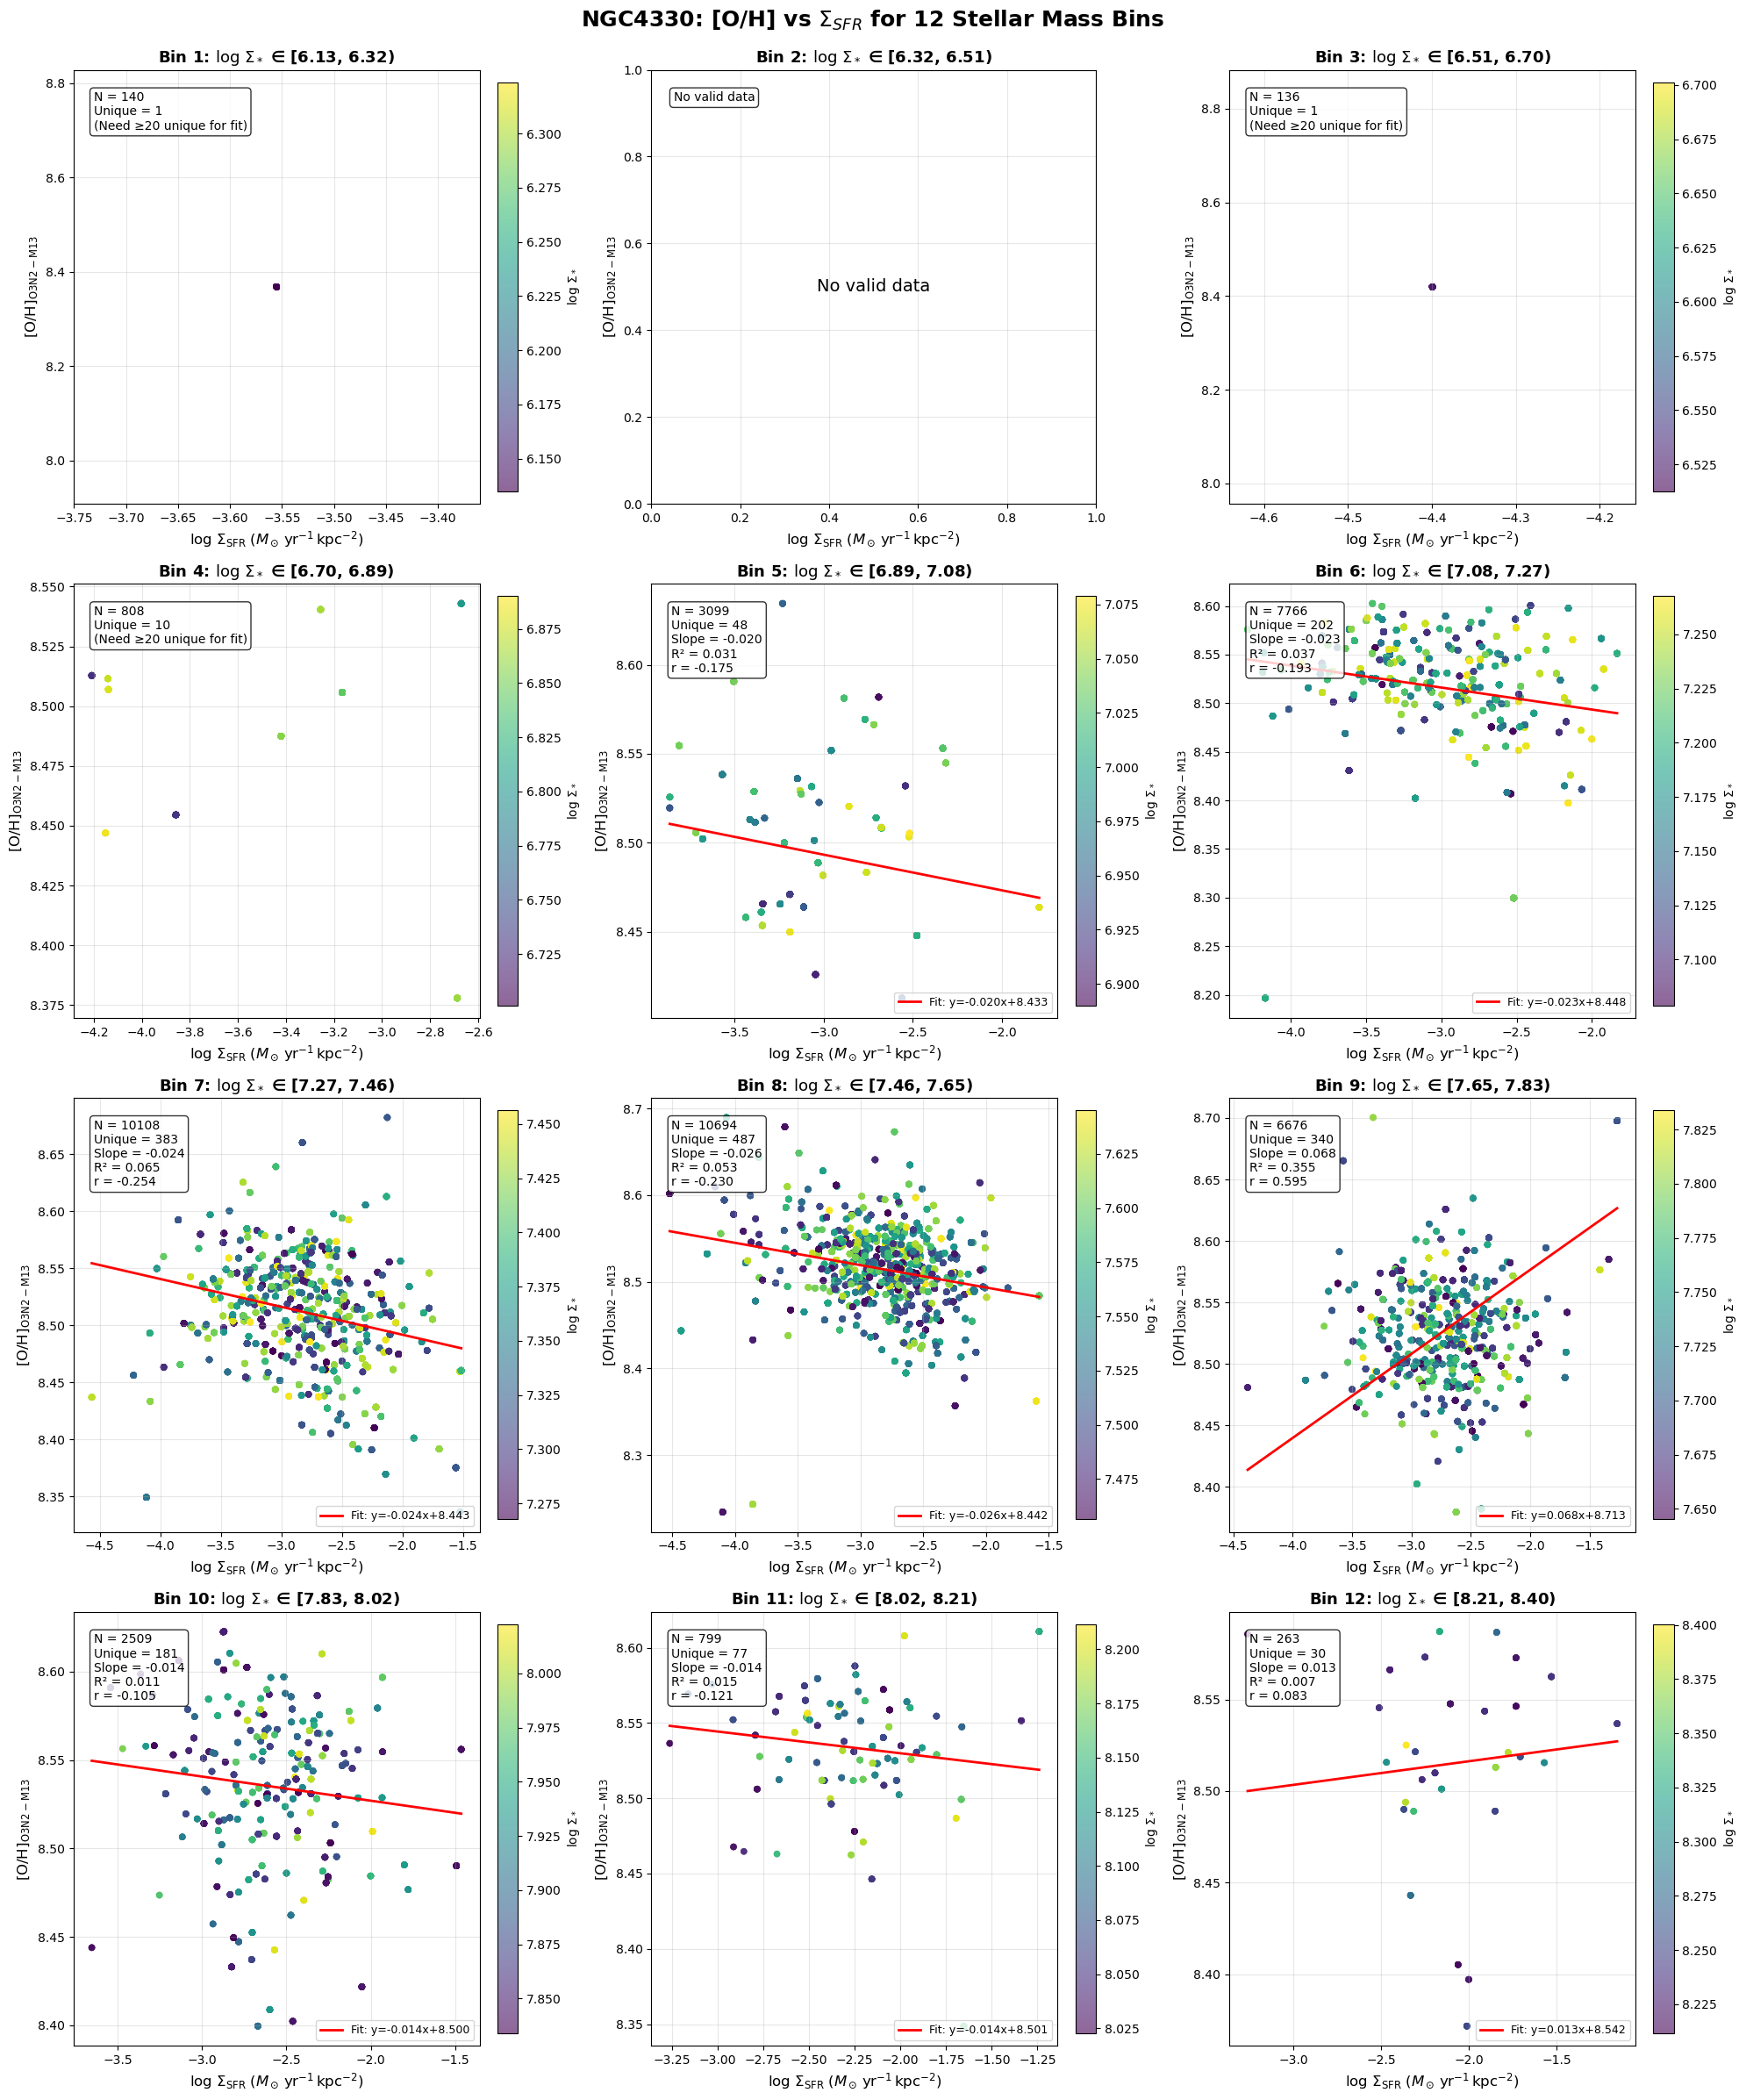

In [16]:
# ------------------------------------------------------------------
# [O/H] vs Σ_SFR scatter plots for each of the 12 stellar mass bins
# Updated: Only fit when there are >= 20 unique datapoints
# ------------------------------------------------------------------

# Create a 4x3 grid to display all 12 bins
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
axes = axes.flatten()

# Color map for points within each bin
cmap = plt.cm.viridis

print(f"\n{'='*80}")
print(f"[O/H] vs ΣSFR RELATION FOR EACH STELLAR MASS BIN - {gal}")
print(f"{'='*80}\n")

for i in range(n_bins):
    ax = axes[i]
    
    # Get mask for this bin
    if i == n_bins - 1:  # Last bin includes right edge
        bin_mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        bin_mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Get data for this bin (only valid points)
    valid_mask = bin_mask & np.isfinite(oh_o3n2_map) & np.isfinite(sigSFR)
    oh_bin_data = oh_o3n2_map[valid_mask]
    sfr_bin_data = sigSFR[valid_mask]
    sigM_bin_data = sigM_masked[valid_mask]
    
    n_points = len(oh_bin_data)
    n_unique = len(np.unique(oh_bin_data))  # Count unique datapoints
    
    if n_points > 0:
        # Create scatter plot
        scatter = ax.scatter(sfr_bin_data, oh_bin_data, c=sigM_bin_data, 
                           cmap=cmap, s=30, alpha=0.6, edgecolors='none',
                           vmin=bin_edges[i], vmax=bin_edges[i+1])
        
        # Calculate and plot linear fit only if >= 20 unique datapoints
        if n_unique >= 20:
            # Perform linear regression
            coeffs = np.polyfit(sfr_bin_data, oh_bin_data, 1)
            poly_fn = np.poly1d(coeffs)
            
            # Generate fit line
            sfr_fit = np.linspace(sfr_bin_data.min(), sfr_bin_data.max(), 100)
            oh_fit = poly_fn(sfr_fit)
            
            # Calculate R² and Pearson correlation
            oh_pred = poly_fn(sfr_bin_data)
            ss_res = np.sum((oh_bin_data - oh_pred)**2)
            ss_tot = np.sum((oh_bin_data - np.mean(oh_bin_data))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            pearson_r = np.corrcoef(sfr_bin_data, oh_bin_data)[0, 1]
            
            # Plot fit line
            ax.plot(sfr_fit, oh_fit, 'r-', linewidth=2, label=f'Fit: y={coeffs[0]:.3f}x+{coeffs[1]:.3f}')
            
            # Statistics text
            stats_text = (f'N = {n_points}\n'
                         f'Unique = {n_unique}\n'
                         f'Slope = {coeffs[0]:.3f}\n'
                         f'R² = {r_squared:.3f}\n'
                         f'r = {pearson_r:.3f}')
        else:
            stats_text = f'N = {n_points}\nUnique = {n_unique}\n(Need ≥20 unique for fit)'
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(r'$\log\,\Sigma_*$', fontsize=10)
        
        # Print statistics
        print(f"Bin {i+1} [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}):")
        print(f"  N points: {n_points}")
        print(f"  N unique: {n_unique}")
        print(f"  Σ* avg: {sigM_bin_averages[i]:.3f}")
        print(f"  [O/H] range: [{oh_bin_data.min():.4f}, {oh_bin_data.max():.4f}]")
        print(f"  ΣSFR range: [{sfr_bin_data.min():.4f}, {sfr_bin_data.max():.4f}]")
        if n_unique >= 20:
            print(f"  Slope: {coeffs[0]:.4f}, R²: {r_squared:.4f}, r: {pearson_r:.4f}")
        else:
            print(f"  Fit not performed (need ≥20 unique points)")
        print()
        
    else:
        stats_text = 'No valid data'
        ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14)
        print(f"Bin {i+1} [{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f}): No valid data\n")
    
    # Add statistics box
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Labels and title
    ax.set_xlabel(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'[O/H]$_{\mathrm{' + indicator_name + '}}$', fontsize=12)
    ax.set_title(f'Bin {i+1}: $\\log\\,\\Sigma_*$ ∈ [{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})', 
                fontsize=13, fontweight='bold')
    
    # Add legend if fit exists
    if n_points > 0 and n_unique >= 20:
        ax.legend(loc='lower right', fontsize=9)
    
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{gal}: [O/H] vs $\\Sigma_{{SFR}}$ for 12 Stellar Mass Bins', 
            fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"{'='*80}")

## 20251015 Try multiplication instead of ratio

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/3142045842.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


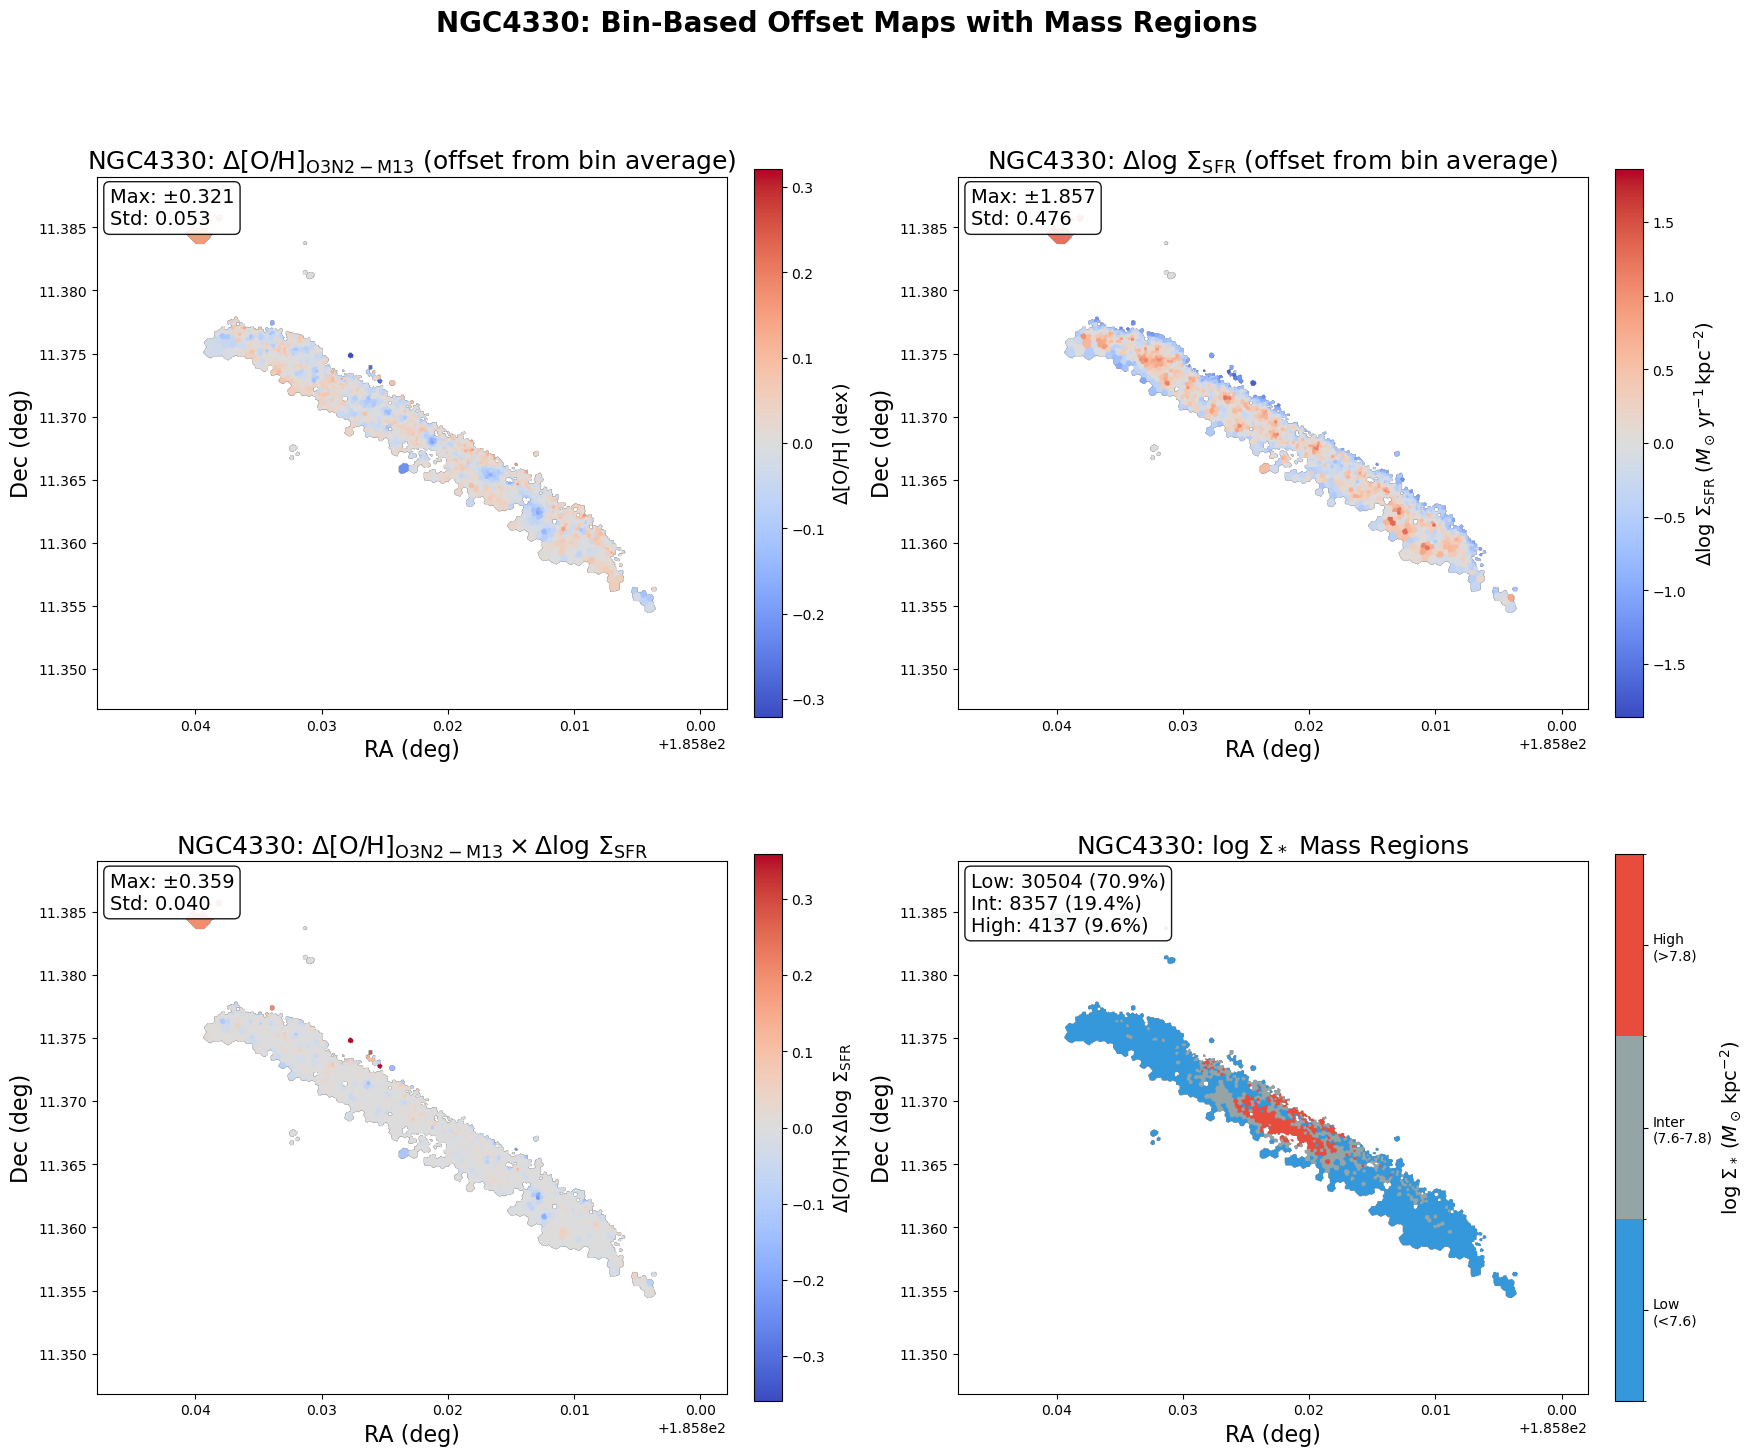


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

Δ[O/H] × ΔΣ_SFR product:
  Mean: -0.000547
  Median: -0.000594
  Std: 0.0399
  Range: [-0.2321, 0.3594]
  Max |product|: ±0.3594
  Valid pixels: 42998

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9.6%)
  Total: 42998 pixels


In [17]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# Bottom-left now shows PRODUCT instead of ratio
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: [O/H] bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_oh = ax1.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax1, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: Σ_SFR bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_sfr = ax2.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax2, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Product map (Δ[O/H] × ΔΣSFR)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate product: Δ[O/H] × ΔΣSFR
oh_sfr_product = oh_bin_offset * sfr_bin_offset

# Calculate symmetric colorbar limits
oh_sfr_product_max = np.nanmax(np.abs(oh_sfr_product[np.isfinite(oh_sfr_product)]))

im_product = ax3.imshow(np.ma.masked_invalid(oh_sfr_product), origin='lower', cmap='coolwarm',
                     extent=extent, vmin=-oh_sfr_product_max, vmax=oh_sfr_product_max)
ax3.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}\times\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_product = fig.colorbar(im_product, ax=ax3, fraction=0.046, pad=0.04)
cbar_product.set_label(r'$\Delta$[O/H]$\times\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{oh_sfr_product_max:.3f}\nStd: {np.nanstd(oh_sfr_product):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔ[O/H] × ΔΣ_SFR product:")
print(f"  Mean: {np.nanmean(oh_sfr_product):.6f}")
print(f"  Median: {np.nanmedian(oh_sfr_product):.6f}")
print(f"  Std: {np.nanstd(oh_sfr_product):.4f}")
print(f"  Range: [{np.nanmin(oh_sfr_product):.4f}, {np.nanmax(oh_sfr_product):.4f}]")
print(f"  Max |product|: ±{oh_sfr_product_max:.4f}")
print(f"  Valid pixels: {np.sum(np.isfinite(oh_sfr_product))}")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/1458397299.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


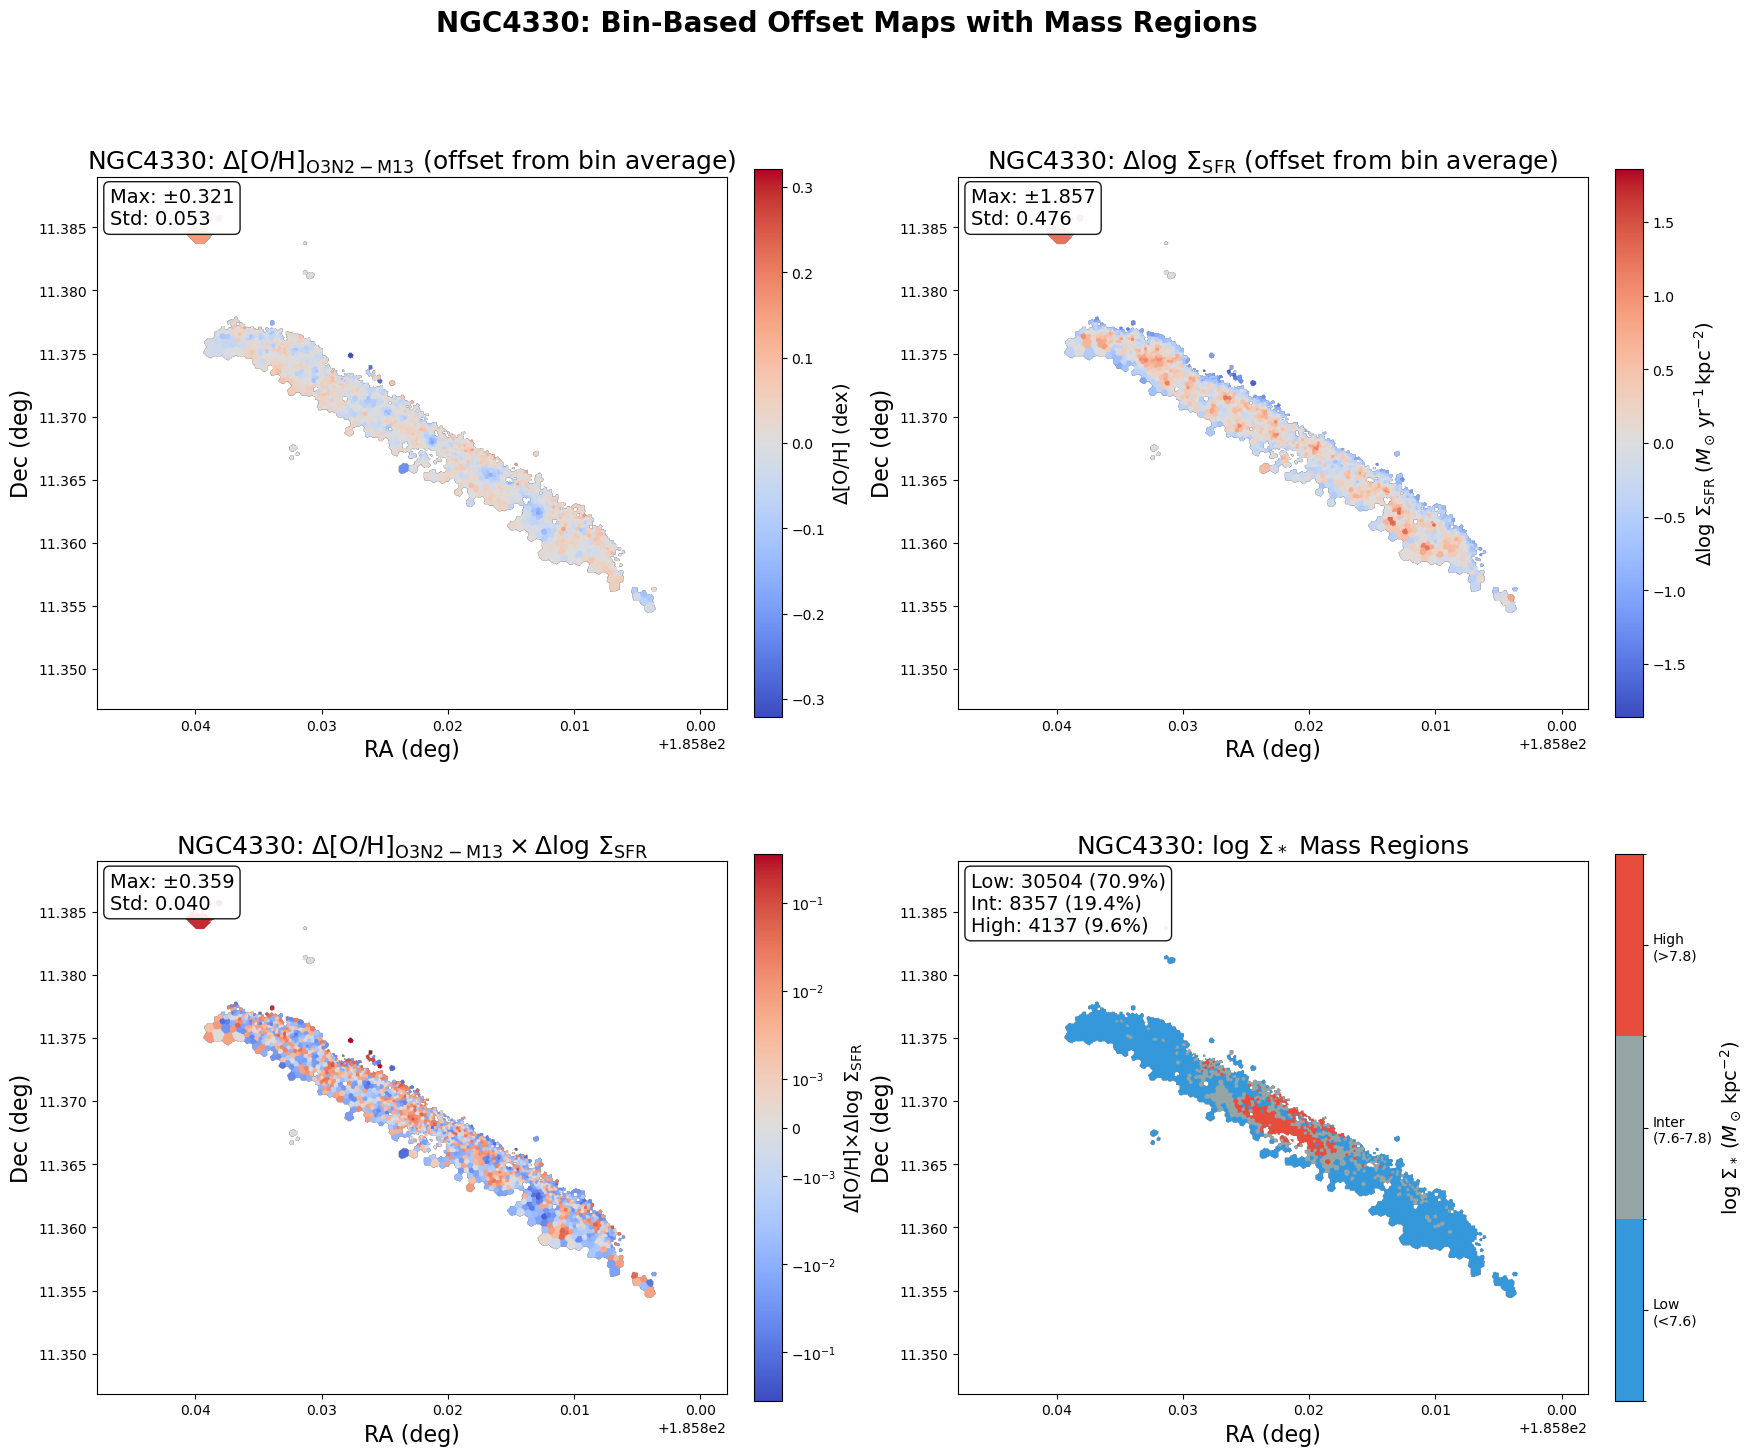


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

Δ[O/H] × ΔΣ_SFR product:
  Mean: -0.000547
  Median: -0.000594
  Std: 0.0399
  Range: [-0.2321, 0.3594]
  Max |product|: ±0.3594
  Valid pixels: 42998

Mass Region Distribution:
  Low-mass (<7.6): 30504 pixels (70.9%)
  Intermediate (7.6-7.8): 8357 pixels (19.4%)
  High-mass (>7.8): 4137 pixels (9.6%)
  Total: 42998 pixels


In [18]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH THREE-COLOR MASS REGION MAP (BLUE/GRAY/RED)
# Bottom-left now shows PRODUCT with LOGARITHMIC COLORBAR STRETCH
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + THREE-COLOR MASS MAP
# ------------------------------------------------------------------
from matplotlib.colors import SymLogNorm

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: [O/H] bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_oh = ax1.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax1, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: Σ_SFR bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_sfr = ax2.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax2, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Product map with LOGARITHMIC COLORBAR (Δ[O/H] × ΔΣSFR)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate product: Δ[O/H] × ΔΣSFR
oh_sfr_product = oh_bin_offset * sfr_bin_offset

# Calculate symmetric limits for product
oh_sfr_product_max = np.nanmax(np.abs(oh_sfr_product[np.isfinite(oh_sfr_product)]))

# Use SymLogNorm for logarithmic colorbar with symmetric handling of negative values
# linthresh: values between -linthresh and +linthresh are treated linearly
# linscale: controls the steepness of the linear region
linthresh = 0.001  # Adjust based on your data range
linscale = 0.5

norm_product = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                          vmin=-oh_sfr_product_max, vmax=oh_sfr_product_max)

im_product = ax3.imshow(np.ma.masked_invalid(oh_sfr_product), origin='lower', cmap='coolwarm',
                       extent=extent, norm=norm_product)
ax3.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}\times\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_product = fig.colorbar(im_product, ax=ax3, fraction=0.046, pad=0.04)
cbar_product.set_label(r'$\Delta$[O/H]$\times\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{oh_sfr_product_max:.3f}\nStd: {np.nanstd(oh_sfr_product):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Three-region Σ* mass map (Low/Intermediate/High)
ax4 = fig.add_subplot(gs[1, 1])

# Create three-region mass classification map
# Low: Σ* < 7.6 (blue), Intermediate: 7.6 <= Σ* <= 7.8 (gray), High: Σ* > 7.8 (red)
mass_region_map = np.full_like(sigM_masked, np.nan)
mass_region_map[sigM_masked < 7.6] = 0  # Low-mass
mass_region_map[(sigM_masked >= 7.6) & (sigM_masked <= 7.8)] = 1  # Intermediate-mass
mass_region_map[sigM_masked > 7.8] = 2  # High-mass

# Create custom discrete colormap: blue, gray, red
from matplotlib.colors import ListedColormap
colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red
cmap_mass_regions = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]  # Boundaries for 3 discrete values (0, 1, 2)
norm_mass_regions = BoundaryNorm(bounds, cmap_mass_regions.N)

im_mass_regions = ax4.imshow(np.ma.masked_invalid(mass_region_map), origin='lower', 
                             cmap=cmap_mass_regions, norm=norm_mass_regions, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ Mass Regions', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_mass = fig.colorbar(im_mass_regions, ax=ax4, fraction=0.046, pad=0.04)
cbar_mass.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each region
cbar_mass.set_ticks([0, 1, 2])
cbar_mass.set_ticklabels(['Low\n(<7.6)', 'Inter\n(7.6-7.8)', 'High\n(>7.8)'])

# Count pixels in each region
n_low = np.sum(mass_region_map == 0)
n_int = np.sum(mass_region_map == 1)
n_high = np.sum(mass_region_map == 2)
total_valid = n_low + n_int + n_high

ax4.text(0.02, 0.98, f'Low: {n_low} ({n_low/total_valid*100:.1f}%)\n'
                     f'Int: {n_int} ({n_int/total_valid*100:.1f}%)\n'
                     f'High: {n_high} ({n_high/total_valid*100:.1f}%)', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Mass Regions', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔ[O/H] × ΔΣ_SFR product:")
print(f"  Mean: {np.nanmean(oh_sfr_product):.6f}")
print(f"  Median: {np.nanmedian(oh_sfr_product):.6f}")
print(f"  Std: {np.nanstd(oh_sfr_product):.4f}")
print(f"  Range: [{np.nanmin(oh_sfr_product):.4f}, {np.nanmax(oh_sfr_product):.4f}]")
print(f"  Max |product|: ±{oh_sfr_product_max:.4f}")
print(f"  Valid pixels: {np.sum(np.isfinite(oh_sfr_product))}")

print(f"\nMass Region Distribution:")
print(f"  Low-mass (<7.6): {n_low} pixels ({n_low/total_valid*100:.1f}%)")
print(f"  Intermediate (7.6-7.8): {n_int} pixels ({n_int/total_valid*100:.1f}%)")
print(f"  High-mass (>7.8): {n_high} pixels ({n_high/total_valid*100:.1f}%)")
print(f"  Total: {total_valid} pixels")
print(f"{'='*80}")

Per-bin averages for NGC4330:
 Bin             Σ* Range     Σ* Avg   ΣSFR Avg  [O/H] Avg   N pixels
--------------------------------------------------------------------------------
   1 [ 6.135,  6.324)      6.135     -3.555      8.368        140
   2 [ 6.324,  6.512)        nan        nan        nan          0
   3 [ 6.512,  6.701)      6.525     -4.399      8.420        136
   4 [ 6.701,  6.890)      6.821     -3.478      8.479        808
   5 [ 6.890,  7.079)      6.993     -3.113      8.496       3099
   6 [ 7.079,  7.268)      7.187     -3.066      8.518       7766
   7 [ 7.268,  7.456)      7.364     -2.843      8.512      10108
   8 [ 7.456,  7.645)      7.546     -2.816      8.514      10694
   9 [ 7.645,  7.834)      7.722     -2.522      8.541       6676
  10 [ 7.834,  8.023)      7.905     -2.563      8.535       2509
  11 [ 8.023,  8.212)      8.107     -2.233      8.533        799
  12 [ 8.212,  8.400)      8.267     -2.022      8.516        263

Bin-based offset statistic

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_1432/4001698769.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


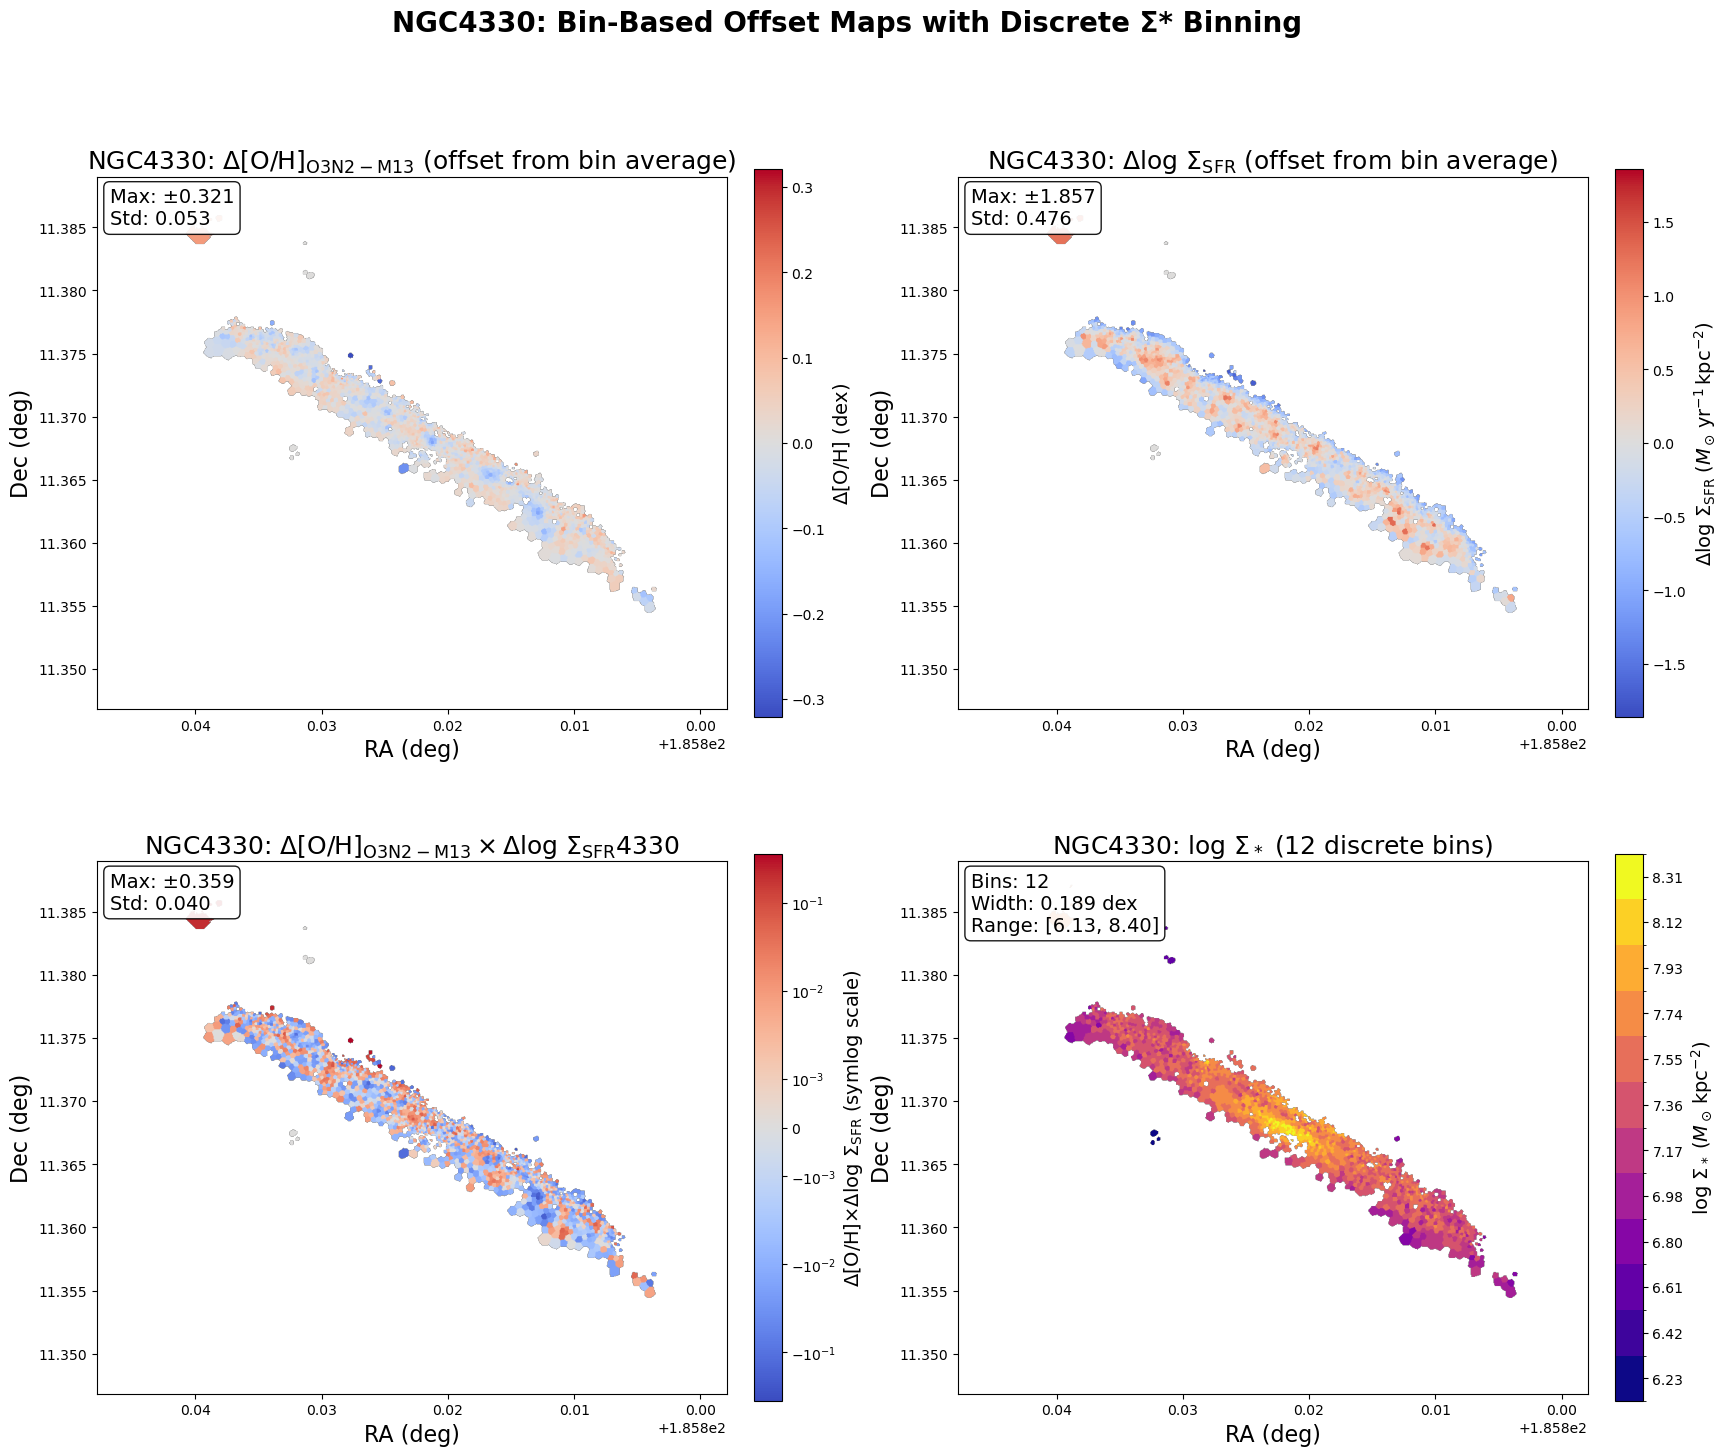


DETAILED BIN-BASED OFFSET STATISTICS FOR NGC4330

ΣSFR offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: -0.000103
  Std: 0.4756
  Range: [-1.8575, 1.3285]
  Max |offset|: ±1.8575
  Valid pixels: 42998

[O/H] offset (from bin averages):
  Mean: -0.000000 (should be ~0)
  Median: 0.001228
  Std: 0.0525
  Range: [-0.3209, 0.1751]
  Max |offset|: ±0.3209
  Valid pixels: 42998

Σ* offset (from bin averages):
  Mean: 0.000000 (should be ~0)
  Median: 0.000942
  Std: 0.0523
  Range: [-0.1057, 0.1335]
  Max |offset|: ±0.1335
  Valid pixels: 42998

Δ[O/H] × ΔΣ_SFR product:
  Mean: -0.000547
  Median: -0.000594
  Std: 0.0399
  Range: [-0.2321, 0.3594]
  Max |product|: ±0.3594
  Valid pixels: 42998

Discrete Σ* Binning:
  Number of bins: 12
  Bin width: 0.189 dex
  Range: [6.135, 8.400] log(M☉/kpc²)


In [19]:
# ------------------------------------------------------------------
# Bin-based offset maps for Σ_SFR, [O/H], and Σ_*
# Offsets calculated relative to per-bin averages (not global median)
# WITH DISCRETE Σ* BINNED MAP (replacing three-color mass region map)
# Bottom-left now shows PRODUCT with LOGARITHMIC COLORBAR STRETCH
# ------------------------------------------------------------------

# We already have sigM_binned_map, bin_edges, and n_bins from previous cell

# ------------------------------------------------------------------
# 1. Calculate per-bin averages for Σ_SFR, [O/H], and Σ_*
# ------------------------------------------------------------------

# Initialize arrays for per-bin averages
sfr_bin_averages = np.zeros(n_bins)
oh_bin_averages = np.zeros(n_bins)
sigM_bin_averages = np.zeros(n_bins)

print(f"Per-bin averages for {gal}:")
print(f"{'Bin':>4} {'Σ* Range':>20} {'Σ* Avg':>10} {'ΣSFR Avg':>10} {'[O/H] Avg':>10} {'N pixels':>10}")
print("-" * 80)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate averages for each property within this Σ* bin
    # Only use spaxels that are valid for each property
    sigM_bin_pixels = sigM_masked[mask & np.isfinite(sigM_masked)]
    sfr_bin_pixels = sigSFR[mask & np.isfinite(sigSFR)]
    oh_bin_pixels = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)]
    
    if len(sigM_bin_pixels) > 0:
        sigM_bin_averages[i] = np.nanmean(sigM_bin_pixels)
    else:
        sigM_bin_averages[i] = np.nan
    
    if len(sfr_bin_pixels) > 0:
        sfr_bin_averages[i] = np.nanmean(sfr_bin_pixels)
    else:
        sfr_bin_averages[i] = np.nan
    
    if len(oh_bin_pixels) > 0:
        oh_bin_averages[i] = np.nanmean(oh_bin_pixels)
    else:
        oh_bin_averages[i] = np.nan
    
    print(f"{i+1:4d} [{bin_edges[i]:6.3f}, {bin_edges[i+1]:6.3f}) {sigM_bin_averages[i]:10.3f} "
          f"{sfr_bin_averages[i]:10.3f} {oh_bin_averages[i]:10.3f} {np.sum(mask):10d}")

# ------------------------------------------------------------------
# 2. Create bin-based offset maps
# ------------------------------------------------------------------

# Initialize offset maps
sfr_bin_offset = np.full_like(sigSFR, np.nan)
oh_bin_offset = np.full_like(oh_o3n2_map, np.nan)
sigM_bin_offset = np.full_like(sigM_masked, np.nan)

for i in range(n_bins):
    if i == n_bins - 1:  # Last bin includes right edge
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked <= bin_edges[i+1])
    else:
        mask = (sigM_masked >= bin_edges[i]) & (sigM_masked < bin_edges[i+1])
    
    # Calculate offsets from bin average for each property
    sfr_bin_offset[mask & np.isfinite(sigSFR)] = sigSFR[mask & np.isfinite(sigSFR)] - sfr_bin_averages[i]
    oh_bin_offset[mask & np.isfinite(oh_o3n2_map)] = oh_o3n2_map[mask & np.isfinite(oh_o3n2_map)] - oh_bin_averages[i]
    sigM_bin_offset[mask] = sigM_masked[mask] - sigM_bin_averages[i]

# Calculate symmetric colorbar limits
sfr_bin_offset_max = np.nanmax(np.abs(sfr_bin_offset[np.isfinite(sfr_bin_offset)]))
oh_bin_offset_max = np.nanmax(np.abs(oh_bin_offset[np.isfinite(oh_bin_offset)]))
sigM_bin_offset_max = np.nanmax(np.abs(sigM_bin_offset[np.isfinite(sigM_bin_offset)]))

print(f"\nBin-based offset statistics:")
print(f"  ΣSFR: max=±{sfr_bin_offset_max:.3f}, mean={np.nanmean(sfr_bin_offset):.6f}, std={np.nanstd(sfr_bin_offset):.3f}")
print(f"  [O/H]: max=±{oh_bin_offset_max:.3f}, mean={np.nanmean(oh_bin_offset):.6f}, std={np.nanstd(oh_bin_offset):.3f}")
print(f"  Σ*: max=±{sigM_bin_offset_max:.3f}, mean={np.nanmean(sigM_bin_offset):.6f}, std={np.nanstd(sigM_bin_offset):.3f}")

# ------------------------------------------------------------------
# 3. Prepare coordinate extent for plotting (RA/Dec degrees)
# ------------------------------------------------------------------
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sigSFR.shape
x_coords = np.arange(x_size)
y_coords = np.arange(y_size)
xx, yy = np.meshgrid(x_coords, y_coords)
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# ------------------------------------------------------------------
# 4. Create figure: 2x2 layout with 3 offset maps + DISCRETE Σ* MAP
# ------------------------------------------------------------------
from matplotlib.colors import SymLogNorm

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

# Top-left: [O/H] bin-based offset map
ax1 = fig.add_subplot(gs[0, 0])
im_oh = ax1.imshow(np.ma.masked_invalid(oh_bin_offset), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=-oh_bin_offset_max, vmax=oh_bin_offset_max)
ax1.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin average)', fontsize=18)
ax1.set_xlabel('RA (deg)', fontsize=16)
ax1.set_ylabel('Dec (deg)', fontsize=16)

cbar_oh = fig.colorbar(im_oh, ax=ax1, fraction=0.046, pad=0.04)
cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

ax1.text(0.02, 0.98, f'Max: ±{oh_bin_offset_max:.3f}\nStd: {np.nanstd(oh_bin_offset):.3f}', 
         transform=ax1.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Top-right: Σ_SFR bin-based offset map
ax2 = fig.add_subplot(gs[0, 1])
im_sfr = ax2.imshow(np.ma.masked_invalid(sfr_bin_offset), origin='lower', cmap='coolwarm',
                    extent=extent, vmin=-sfr_bin_offset_max, vmax=sfr_bin_offset_max)
ax2.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin average)', fontsize=18)
ax2.set_xlabel('RA (deg)', fontsize=16)
ax2.set_ylabel('Dec (deg)', fontsize=16)

cbar_sfr = fig.colorbar(im_sfr, ax=ax2, fraction=0.046, pad=0.04)
cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

ax2.text(0.02, 0.98, f'Max: ±{sfr_bin_offset_max:.3f}\nStd: {np.nanstd(sfr_bin_offset):.3f}', 
         transform=ax2.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-left: Product map with LOGARITHMIC COLORBAR (Δ[O/H] × ΔΣSFR)
ax3 = fig.add_subplot(gs[1, 0])

# Calculate product: Δ[O/H] × ΔΣSFR
oh_sfr_product = oh_bin_offset * sfr_bin_offset

# Calculate symmetric limits for product
oh_sfr_product_max = np.nanmax(np.abs(oh_sfr_product[np.isfinite(oh_sfr_product)]))

# Use SymLogNorm for logarithmic colorbar with symmetric handling of negative values
# linthresh: values between -linthresh and +linthresh are treated linearly
# linscale: controls the steepness of the linear region
linthresh = 0.001  # Adjust based on your data range
linscale = 0.5

norm_product = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                          vmin=-oh_sfr_product_max, vmax=oh_sfr_product_max)

im_product = ax3.imshow(np.ma.masked_invalid(oh_sfr_product), origin='lower', cmap='coolwarm',
                       extent=extent, norm=norm_product)
ax3.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}\times\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$4330', fontsize=18)
ax3.set_xlabel('RA (deg)', fontsize=16)
ax3.set_ylabel('Dec (deg)', fontsize=16)

cbar_product = fig.colorbar(im_product, ax=ax3, fraction=0.046, pad=0.04)
cbar_product.set_label(r'$\Delta$[O/H]$\times\Delta\log\,\Sigma_{\mathrm{SFR}}$ (symlog scale)', fontsize=14)

ax3.text(0.02, 0.98, f'Max: ±{oh_sfr_product_max:.3f}\nStd: {np.nanstd(oh_sfr_product):.3f}', 
         transform=ax3.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Bottom-right: Discrete Σ* binned map
ax4 = fig.add_subplot(gs[1, 1])

# Create discrete colormap for the binned map
cmap_discrete = plt.cm.plasma
norm_discrete = BoundaryNorm(bin_edges, cmap_discrete.N)

im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                            cmap=cmap_discrete, norm=norm_discrete, extent=extent)
ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
ax4.set_xlabel('RA (deg)', fontsize=16)
ax4.set_ylabel('Dec (deg)', fontsize=16)

cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)

# Set colorbar ticks at the center of each bin
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(n_bins)]
cbar_binned.set_ticks(bin_centers)
cbar_binned.set_ticklabels([f'{center:.2f}' for center in bin_centers])

ax4.text(0.02, 0.98, f'Bins: {n_bins}\nWidth: {(sigM_max - sigM_min) / n_bins:.3f} dex\nRange: [{sigM_min:.2f}, {sigM_max:.2f}]', 
         transform=ax4.transAxes, fontsize=14, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.suptitle(f'{gal}: Bin-Based Offset Maps with Discrete Σ* Binning', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print detailed statistics
# ------------------------------------------------------------------
# Calculate statistics for printing
sfr_valid = np.isfinite(sfr_bin_offset)
oh_valid = np.isfinite(oh_bin_offset)
sigM_valid = np.isfinite(sigM_bin_offset)

print(f"\n{'='*80}")
print(f"DETAILED BIN-BASED OFFSET STATISTICS FOR {gal}")
print(f"{'='*80}")
print(f"\nΣSFR offset (from bin averages):")
print(f"  Mean: {np.nanmean(sfr_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sfr_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sfr_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sfr_bin_offset):.4f}, {np.nanmax(sfr_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sfr_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sfr_valid)}")

print(f"\n[O/H] offset (from bin averages):")
print(f"  Mean: {np.nanmean(oh_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(oh_bin_offset):.6f}")
print(f"  Std: {np.nanstd(oh_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(oh_bin_offset):.4f}, {np.nanmax(oh_bin_offset):.4f}]")
print(f"  Max |offset|: ±{oh_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(oh_valid)}")

print(f"\nΣ* offset (from bin averages):")
print(f"  Mean: {np.nanmean(sigM_bin_offset):.6f} (should be ~0)")
print(f"  Median: {np.nanmedian(sigM_bin_offset):.6f}")
print(f"  Std: {np.nanstd(sigM_bin_offset):.4f}")
print(f"  Range: [{np.nanmin(sigM_bin_offset):.4f}, {np.nanmax(sigM_bin_offset):.4f}]")
print(f"  Max |offset|: ±{sigM_bin_offset_max:.4f}")
print(f"  Valid pixels: {np.sum(sigM_valid)}")

print(f"\nΔ[O/H] × ΔΣ_SFR product:")
print(f"  Mean: {np.nanmean(oh_sfr_product):.6f}")
print(f"  Median: {np.nanmedian(oh_sfr_product):.6f}")
print(f"  Std: {np.nanstd(oh_sfr_product):.4f}")
print(f"  Range: [{np.nanmin(oh_sfr_product):.4f}, {np.nanmax(oh_sfr_product):.4f}]")
print(f"  Max |product|: ±{oh_sfr_product_max:.4f}")
print(f"  Valid pixels: {np.sum(np.isfinite(oh_sfr_product))}")

print(f"\nDiscrete Σ* Binning:")
print(f"  Number of bins: {n_bins}")
print(f"  Bin width: {(sigM_max - sigM_min) / n_bins:.3f} dex")
print(f"  Range: [{sigM_min:.3f}, {sigM_max:.3f}] log(M☉/kpc²)")
print(f"{'='*80}")